# Story Clustering — POC Notebook

Implements the algorithm-validation POC defined in `docs/story-clustering-poc-spec.md`.

- **Dataset:** local `bloomberg_reuters` parquet files (Bloomberg full articles + Reuters titles, 2006–2013).
- **Target:** ~10,000 canonical items after dedup.
- **Structure:** 17 sections, each ending in a verification checkpoint.

We pause for user verification at the end of every section before moving on.

## Section 1 — Setup & configuration

**Purpose.** Pin versions, load API keys, and set every threshold and model ID in one `CONFIG` dict so the whole notebook re-runs deterministically.

**Outputs.** A printed `CONFIG` summary and an optional-dep version check. No charts in this section.

**Reading order.** This section has five sub-steps (1.1 → 1.5). Each is a small markdown explainer followed by one code cell. Run them top to bottom.

### 1.1 Install dependencies (first run only)

The notebook depends on a fairly large stack: numerical (`numpy`, `pandas`, `pyarrow`), ML (`scikit-learn`, `hdbscan`, `umap-learn`), visualization (`matplotlib`, `seaborn`, `plotly`), NLP utilities (`datasketch`, `tiktoken`, `trafilatura`), and LLM SDKs (`openai`, `anthropic`, `google-generativeai`).

The cell below is a one-shot installer — leave it commented out on subsequent runs to avoid re-resolving the dependency graph every time. If a later cell complains a package is missing, uncomment the `%pip install` line, run it, then re-comment.

In [ ]:
# One-shot install. Uncomment the `%pip install` line below the FIRST time you run this notebook,
# then re-comment it so subsequent runs don't re-resolve packages every time the kernel restarts.
#
# `%pip` is the Jupyter magic that installs into the *currently-running* kernel's environment,
# which avoids the classic 'pip installed it but the notebook still says ImportError' trap.

# %pip install -q pandas numpy pyarrow scikit-learn hdbscan umap-learn matplotlib seaborn plotly \
#                datasketch tiktoken openai anthropic google-generativeai \
#                trafilatura tqdm python-dotenv

### 1.2 Import core libraries & verify optional dependencies

We import the small handful of stdlib + numerical libs that *every* downstream cell needs. Then we probe a list of heavier optional libraries one at a time — if any are missing, we print a clear warning rather than crashing, so the rest of the notebook can still be inspected even before all packages are installed.

This is also the place where the kernel's Python and NumPy versions are recorded for the run.

In [ ]:
# Standard-library imports used throughout the notebook.
# Keeping them in one cell means a single import error fails fast at the top.
import sys      # for sys.version (kernel reporting)
import os       # for environment-variable access (API keys)
import json     # extra_fields in the parquet are JSON-encoded strings
import hashlib  # used for url_hash and prompt-cache keys later
import random   # seeded for deterministic sampling
from pathlib import Path                       # all paths use pathlib for clarity
from datetime import datetime, timedelta, timezone  # 72h active-window arithmetic

# Numerical stack — heaviest deps loaded at the top so a missing install fails loudly.
import numpy as np
import pandas as pd

# Sanity print: confirm which kernel/interpreter is running and what versions are pinned.
print(f"Python:  {sys.version.split()[0]}")
print(f"NumPy:   {np.__version__}")
print(f"Pandas:  {pd.__version__}")

# Optional / heavier deps. We *probe* them rather than `import` at the top so that a missing
# library doesn't break Section 1 — the user can still see CONFIG and decide what to install.
# Each name is what `__import__` expects; for example, `sklearn` (not `scikit-learn`) and
# `dotenv` (not `python-dotenv`).
OPTIONAL_DEPS = [
    "pyarrow",              # parquet reader for the dataset files
    "sklearn",              # nearest-neighbors for §11 candidate retrieval
    "hdbscan",              # residual clustering in §12
    "umap",                 # 3D projection for the stakeholder demo charts (§7, §11, §12)
    "matplotlib",           # static 2D plots
    "seaborn",              # nicer histograms / KDEs for §9
    "plotly",                # interactive 3D scatter charts
    "datasketch",           # MinHash + LSH for near-dup detection (§5)
    "tiktoken",             # token counts for cost accounting (§16)
    "openai",               # embeddings (§7) + ensemble labeler (§8)
    "anthropic",            # Haiku judge + Sonnet metadata (§6, §8, §11, §13, §14)
    "google.generativeai", # Gemini ensemble labeler (§8) — deprecated; we may swap to google.genai
    "trafilatura",          # HTML→clean-text (unused for parquet ingest, kept for future sources)
    "tqdm",                 # progress bars for long loops
    "dotenv",               # load API keys from a .env file (the package is python-dotenv)
]

print("\nOptional deps:")
for name in OPTIONAL_DEPS:
    # `__import__` lets us dynamically import by string. We catch ImportError separately so we
    # know exactly which one is missing — `import a, b, c` would only tell us the first failure.
    try:
        mod = __import__(name)
        # Some packages don't expose __version__ (e.g. hdbscan exposes it on a submodule).
        ver = getattr(mod, "__version__", "?")
        print(f"  {name:<24} {ver}")
    except ImportError:
        print(f"  {name:<24} MISSING — install via the pip cell above")

### 1.3 Load API keys

Three providers participate in this POC:

- **OpenAI** (`OPENAI_API_KEY`) — embeddings in §7, ensemble labeling in §8.
- **Anthropic** (`ANTHROPIC_API_KEY`) — Haiku entity extraction and gray-zone judge (§6, §11), Sonnet story metadata (§13), ensemble labeling (§8).
- **Google** (`GOOGLE_API_KEY`) — Gemini ensemble labeler (§8).

Keys can live in a `.env` file at the project root (loaded automatically below if `python-dotenv` is installed) or be exported into your shell. Missing keys do **not** raise here — we want Section 1 to succeed even before keys are set, so the rest of the notebook is still browsable. The warning surfaces the missing keys so you know to set them before §6.

In [ ]:
# Try to load a project-local .env file (e.g. /Users/alex/Projcts/news-clustering/.env).
# If python-dotenv isn't installed yet we silently skip — the shell env is checked anyway.
try:
    from dotenv import load_dotenv
    load_dotenv(Path.cwd() / ".env")  # no-op if .env doesn't exist
except ImportError:
    pass

# The three provider keys we'll need. We don't fail here — Section 1 should always succeed.
REQUIRED_KEYS = ["OPENAI_API_KEY", "ANTHROPIC_API_KEY", "GOOGLE_API_KEY"]

# os.environ.get returns None / empty string for missing keys, both of which we treat as 'missing'.
missing = [k for k in REQUIRED_KEYS if not os.environ.get(k)]

if missing:
    print(f"⚠️  Missing API keys: {missing}")
    print("   Required for §6 (entity extraction), §7 (embeddings),")
    print("   §8 (LLM-ensemble labeling), and onward.")
    print("   Set them in a .env file at project root or in your shell, then re-run this cell.")
else:
    print("✓ All required API keys present.")

### 1.4 Define the `CONFIG` dict

Every tunable parameter the algorithm uses lives in this dict. Putting them in one place means:

- A reader can audit the whole experiment by reading 30 lines.
- Re-runs are reproducible — change a value here, re-run from the top, get a new result.
- §9 (threshold calibration) can write back its calibrated values to a JSON next to this dict for production handoff.

Categories (mirrors the comment-blocks in the cell): **Paths**, **Sample size**, **Thresholds**, **HDBSCAN**, **Embedding**, **LLM models**, **Client universe**, **Eval set**, **Determinism**.

Threshold values (`tau_high=0.75`, `tau_low=0.55`, etc.) are *priors from the literature*. §9 will re-calibrate them against the labeled eval set produced in §8 — the values shipped to AWS are the §9 outputs, not these priors.

In [ ]:
# Single source of truth for every tunable parameter used downstream.
# Re-run this cell after editing any value to propagate the change to the rest of the notebook.
CONFIG = {
    # --- Paths ----------------------------------------------------------------
    # Where the parquet shards live, which dataset to ingest, where to write outputs.
    "data_dir":         Path.cwd() / "dataset" / "financial-news-multisource" / "data",
    "primary_source":   "bloomberg_reuters",  # only source for the POC; §2 surfaces the Bloomberg/Reuters mix
    "artifacts_dir":    Path.cwd() / "artifacts",  # labeled_eval_set.csv, pos_calibration.json land here
    "cache_dir":        Path.cwd() / ".cache",     # LLM/embedding responses cached by input hash (deterministic re-runs)

    # --- Sample size ----------------------------------------------------------
    # Number of canonical (post-dedup) items the POC will process end-to-end.
    # Spec default is ~5k; we go to 10k for tighter calibration CIs (~$140 in API spend).
    "target_canonical_items": 10_000,

    # --- Thresholds (priors; re-calibrated in §9) -----------------------------
    "tau_high":              0.75,  # cosine ≥ tau_high → auto-assign to nearest story
    "tau_low":               0.55,  # cosine < tau_low → residual (skip LLM judge entirely)
    "minhash_threshold":     0.85,  # MinHash Jaccard ≥ this → wire-syndication duplicate (§5)
    "minhash_num_perm":      128,   # 128 permutations is a standard speed/accuracy trade for LSH
    "active_window_hours":   72,    # only stories whose newest item is < 72h old are merge candidates
    "centroid_merge_sim":    0.85,  # §14: merge two stories if their centroids are this close

    # --- HDBSCAN (§12 residual clustering) ------------------------------------
    # We deliberately keep min_cluster_size=2 so even pairs can spawn a new story.
    "hdbscan_min_cluster_size":         2,
    "hdbscan_min_samples":              2,
    "hdbscan_metric":                   "cosine",
    "hdbscan_cluster_selection_method": "eom",  # excess-of-mass — robust against single-density-level clusters

    # --- Embedding (§7) -------------------------------------------------------
    # text-embedding-3-large supports Matryoshka truncation, so we ask for 1024 dims
    # instead of the default 3072 (~3× memory, ~3× cost, marginal quality gain).
    "embed_model":      "text-embedding-3-large",
    "embed_dims":       1024,
    "lede_chars":       600,   # title + first 600 chars of body is what we embed

    # --- LLM models -----------------------------------------------------------
    # Pin exact model IDs so labels and calibration are tied to a specific release.
    "haiku_model":        "claude-haiku-4-5-20251001",  # gray-zone judge (§11), entity extraction (§6), doc-context (§10)
    "sonnet_model":       "claude-sonnet-4-6",          # story metadata (§13) + ensemble labeler #1 (§8)
    "openai_judge_model": "gpt-5.2",                    # ensemble labeler #2 (§8)
    "gemini_judge_model": "gemini-3.5-flash",           # ensemble labeler #3 (§8). 3 different vendors so no single blind spot dominates.

    # --- Rate limits (per-vendor; client-side sliding window) -----------------
    # Each vendor's labeler in §7.3 reads its own limit. Anthropic tier-1 caps Sonnet
    # at 30k input tokens/min ≈ 25 req/min at our ~1k tokens/call — hence the lower
    # default for sonnet. Bump these only after confirming your account tier allows it.
    "vendor_rate_limits_rpm": {
        "sonnet": 25,   # Anthropic tier-1: 30k TPM ÷ ~1k tokens/call ≈ 25 RPM safe
        "haiku":  40,   # Anthropic tier-1: 50 RPM strict — leave 20% margin for clock skew
        "openai": 50,
        "gemini": 50,
    },

    # --- Client universe (§3) -------------------------------------------------
    # Top-N most-mentioned tickers/companies in the dataset stand in for 'banker clients'.
    "client_universe_size": 20,

    # --- Eval set (§8) --------------------------------------------------------
    # Stratified pair sampling: equal counts per cosine bin so the threshold zone
    # is well-represented (uniform random would oversample the low-cosine tail).
    "eval_pairs_per_bin":   60,
    "eval_cosine_bins": [
        (0.20, 0.40), (0.40, 0.50), (0.50, 0.55), (0.55, 0.60),
        (0.60, 0.65), (0.65, 0.70), (0.70, 0.75), (0.75, 0.80),
        (0.80, 0.85), (0.85, 1.00),
    ],
    "human_spotcheck_band": (0.55, 0.75),  # cosine range that gets human review (the threshold-critical zone)

    # --- Determinism ----------------------------------------------------------
    # Re-running the notebook from the top should produce identical results modulo
    # LLM nondeterminism (which we mitigate by caching responses to disk by input hash).
    "random_seed": 42,
}

# Make sure the output directories exist *before* any later cell tries to write to them.
CONFIG["artifacts_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["cache_dir"].mkdir(parents=True, exist_ok=True)

# Seed Python and NumPy RNGs so any sampling is reproducible across runs.
random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

print(f"CONFIG defined: {len(CONFIG)} keys")

### 1.5 Pretty-print the `CONFIG` summary

We print `CONFIG` grouped by category so you can eyeball it before continuing. This is the value of the *defaults* — §9 will overwrite the threshold values with calibrated ones, and the printed table will reflect those new values when re-run.

In [ ]:
# Group keys by category for readability. The grouping is purely for display — `CONFIG`
# itself is a flat dict, so downstream code uses CONFIG['tau_high'] etc. directly.
_GROUPS = {
    "Paths":       ["data_dir", "primary_source", "artifacts_dir", "cache_dir"],
    "Scale":       ["target_canonical_items"],
    "Thresholds":  ["tau_high", "tau_low", "minhash_threshold",
                    "minhash_num_perm", "active_window_hours", "centroid_merge_sim"],
    "HDBSCAN":     ["hdbscan_min_cluster_size", "hdbscan_min_samples",
                    "hdbscan_metric", "hdbscan_cluster_selection_method"],
    "Embedding":   ["embed_model", "embed_dims", "lede_chars"],
    "LLM models":  ["haiku_model", "sonnet_model",
                    "openai_judge_model", "gemini_judge_model"],
    "Eval set":    ["client_universe_size", "eval_pairs_per_bin",
                    "human_spotcheck_band"],
    "Determinism": ["random_seed"],
}

# Iterate groups → keys → values, truncating long path strings so the table stays readable.
for group, keys in _GROUPS.items():
    print(f"\n[{group}]")
    for k in keys:
        v = CONFIG.get(k)
        s = str(v)
        # Long paths get truncated; everything else fits in ~90 chars.
        if len(s) > 90:
            s = s[:87] + "..."
        print(f"  {k:<34} {s}")

---

### Section 1 verification checkpoint

Before continuing to Section 2, confirm:

- [ ] All required API keys printed `present` (or you're OK deferring §6+ until they are set).
- [ ] Any optional dep marked `MISSING` is installed via the `%pip install` cell above, then this section re-run.
- [ ] `CONFIG` values look right — especially `tau_high`, `tau_low`, model IDs, and `target_canonical_items`.

**Dataset finding (from preliminary inspection).** `bloomberg_reuters` is a mix of two underlying sub-datasets:

- `bloomberg_2006_2013` — full articles, minute-precision timestamps (~9% of rows in the first file).
- `reuters_titles_2007_2013` — **titles only**, day-precision timestamps (~91% of rows).

We will surface this in §2 and decide between (a) keep only full-article items, (b) keep both and accept short embed inputs for Reuters titles, or (c) augment with another source. **TBD with user in §2.**

> **STOP — verify with user before continuing to Section 2.**

## Section 2 — Dataset loading & exploration

**Purpose.** Understand the shape of `bloomberg_reuters` before deciding what to do with it. The spec asks us to map raw columns to a canonical schema (`item_id`, `title`, `body`, `source`, `published_at`, `url`) and to produce tables/charts that surface scale, source mix, time coverage, and length distributions.

**Sub-steps.**

1. **2.1** Load all `.parquet` shards into one DataFrame.
2. **2.2** Parse the nested `extra_fields` JSON column into flat columns.
3. **2.3** Build the canonical schema (split `text` into title + body, parse dates) and cache it to disk for fast re-runs.
4. **2.4** Column inventory: dtype, null %, example value per canonical column.
5. **2.5** Source breakdown table: counts, date range, has-body %.
6. **2.6** Title length distribution (characters).
7. **2.7** Body length distribution (tokens, via `tiktoken` on a sample).
8. **2.8** Items per day, stacked by source.

**Decision this section enables.** What to do about the Bloomberg/Reuters mix flagged in §1 — keep only full-article items, keep both, or further restrict. Also: which date slice to use, because the dataset spans 2006–2013 and the 72-hour active-window logic needs density.

### 2.1 Locate and load all parquet shards

We use `pyarrow.dataset` rather than reading files one at a time with `pd.read_parquet` because:

- It reads shards **in parallel** (much faster than a serial Python loop for 17 files).
- It exposes the *combined* row count without materialising rows, which is useful for sanity-checking before pulling the whole thing into memory.

After this cell we have `raw_df`: one row per article, three columns (`date`, `text`, `extra_fields`) — exactly the schema we saw when inspecting a single file.

In [ ]:
import pyarrow.dataset as pa_ds

# 2.1 — Locate the parquet shards.
# CONFIG['primary_source'] is 'bloomberg_reuters'; the data lives in CONFIG['data_dir']/<source>/.
source_dir = CONFIG["data_dir"] / CONFIG["primary_source"]
parquet_files = sorted(source_dir.glob("*.parquet"))
print(f"Found {len(parquet_files)} parquet shards in {source_dir}")

# 2.1 — Build a pyarrow Dataset (lazy view over all shards) and inspect its metadata.
# `to_table()` actually loads everything; we hold off and report the schema first.
dataset = pa_ds.dataset(parquet_files, format="parquet")
print(f"Schema:\n{dataset.schema}")

# 2.1 — Pull total row count *without* loading bodies.
# count_rows() reads only the footer metadata of each shard — instant.
total_rows = dataset.count_rows()
print(f"\nTotal rows across all shards: {total_rows:,}")

# 2.1 — Materialise into a pandas DataFrame.
# This is the slow step (~30–60 s for ~8 M rows on a laptop).
# Output dtype for string columns will be object/str — that's fine for now.
print("\nLoading into pandas (this can take ~1 minute)...")
raw_df = dataset.to_table().to_pandas()
print(f"Loaded raw_df: {len(raw_df):,} rows × {len(raw_df.columns)} columns")
print(f"Memory footprint: {raw_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

### 2.2 Parse the nested `extra_fields` JSON column

Each row's `extra_fields` is a JSON string with these keys (observed in §1 inspection):

- `url`, `author`, `source` *("Bloomberg" / "Reuters")*
- `dataset` — the **sub-dataset**: `bloomberg_2006_2013` vs `reuters_titles_2007_2013`
- `text_type` *("full_article" / "title")*
- `time_precision` *("minute" / "day")*
- a few audit fields (`raw_type`, `tz_hint`, `dataset_source`, `anchor_policy`, `date_raw`, `date_trading`)

We `json.loads` each row and use `pd.json_normalize` to flatten the result into columns. This is faster and cleaner than `.apply(json.loads).apply(pd.Series)`.

In [ ]:
# 2.2 — Parse extra_fields once, then flatten into columns of raw_df.
#
# json.loads on every row is a Python-level loop, so 8 M rows takes ~30–60 s.
# We use a list comprehension (faster than .apply when the function is pure Python).
print("Parsing extra_fields JSON ...")
parsed_records = [json.loads(s) for s in raw_df["extra_fields"]]

# pd.json_normalize converts a list-of-dicts into a flat DataFrame.
# All rows have the same keys (verified in §1), so columns are well-defined.
extra_df = pd.json_normalize(parsed_records)
print(f"extra_df columns: {list(extra_df.columns)}")

# 2.2 — Merge the flattened columns back onto raw_df, dropping the original JSON blob.
# Resetting index is defensive — both should be 0..N-1 already.
raw_df = raw_df.reset_index(drop=True).join(extra_df.reset_index(drop=True))
raw_df = raw_df.drop(columns=["extra_fields"])
print(f"\nraw_df now has {len(raw_df.columns)} columns: {list(raw_df.columns)}")

### 2.3 Build the canonical schema (and cache the result)

The production system uses `(item_id, title, body, source, published_at, url)`. Our raw data has:

- `date` → `published_at` (ISO 8601 strings — pandas parses cleanly).
- `text` → needs splitting into `title` and `body`. Bloomberg articles start with `-- TITLE\n\nBODY`; Reuters items are usually title-only with no `\n\n` separator.
- `source`, `url` → already flat from §2.2.
- `item_id` — deferred to §3 (UUID5 from URL once we know how to canonicalize).

Because building this DataFrame is expensive (~2 min on 8 M rows), we **cache the result** to `CONFIG['cache_dir']/canonical.parquet`. On re-run, the cache short-circuits the parsing.

In [ ]:
import re

# 2.3 — Helper: split a 'text' field into (title, body).
#
# Format observed in the dataset:
#   Bloomberg full articles:  '-- TITLE\n\nBODY'
#   Reuters titles-only:      'TITLE'   (no separator, no body)
# Some entries also have leading whitespace or the '-- ' prefix without a body.
TITLE_PREFIX_RE = re.compile(r"^--\s+")

def split_title_body(text: str) -> tuple[str, str]:
    """Return (title, body). body is empty string if no \\n\\n separator exists."""
    if not isinstance(text, str):
        return "", ""
    text = text.strip()
    text = TITLE_PREFIX_RE.sub("", text)  # strip leading "-- " if present
    if "\n\n" in text:
        title, body = text.split("\n\n", 1)
        return title.strip(), body.strip()
    return text, ""  # title-only (Reuters case)

# 2.3 — Cache path. If it exists, load and skip the heavy work entirely.
cache_path = CONFIG["cache_dir"] / "canonical.parquet"

if cache_path.exists():
    canonical_df = pd.read_parquet(cache_path)
    print(f"Loaded canonical_df from cache: {len(canonical_df):,} rows")
else:
    print("Building canonical_df (this can take ~2 minutes) ...")
    # Split titles and bodies in one vectorised-ish pass (list of tuples → two columns).
    pairs = [split_title_body(t) for t in raw_df["text"]]
    titles = [p[0] for p in pairs]
    bodies = [p[1] for p in pairs]

    canonical_df = pd.DataFrame({
        # item_id is assigned in §3 (UUID5 from canonicalised URL); placeholder for now.
        "item_id":      pd.NA,
        "title":        titles,
        "body":         bodies,
        "source":       raw_df["source"],            # "Bloomberg" or "Reuters"
        "dataset":      raw_df["dataset"],           # sub-dataset name (Bloomberg_2006_2013, reuters_titles_2007_2013)
        "text_type":    raw_df["text_type"],         # "full_article" or "title"
        "time_precision": raw_df["time_precision"], # "minute" or "day"
        # pd.to_datetime parses ISO 8601 with the trailing Z (UTC). utc=True normalises tz-aware.
        "published_at": pd.to_datetime(raw_df["date"], utc=True, errors="coerce"),
        "url":          raw_df["url"],
        "author":       raw_df.get("author"),       # not used downstream but kept for audit
    })

    # Persist to disk for fast re-runs.
    canonical_df.to_parquet(cache_path, index=False)
    print(f"Wrote cache: {cache_path}")

print(f"canonical_df: {len(canonical_df):,} rows × {len(canonical_df.columns)} columns")

### 2.4 Column inventory

For each canonical column we report: dtype, % null, and a sample value. This is the single quickest way to spot a parsing problem (e.g. a column that's all-null because of a typo in the source key).

In [ ]:
# 2.4 — Per-column inventory.
#
# We build a small DataFrame summarising each column rather than printing line-by-line.
# `iloc[0]` gives a deterministic example even when the column has nulls in early rows.
rows = []
for col in canonical_df.columns:
    series = canonical_df[col]
    # First non-null example for legibility.
    non_null = series.dropna()
    example = non_null.iloc[0] if len(non_null) else "(all null)"
    # Truncate long string examples so the table stays readable.
    if isinstance(example, str) and len(example) > 80:
        example = example[:77] + "..."
    rows.append({
        "column":   col,
        "dtype":    str(series.dtype),
        "null_%":   round(series.isna().mean() * 100, 2),
        "example":  example,
    })

inventory = pd.DataFrame(rows)
inventory  # last expression in a cell is auto-displayed by Jupyter

### 2.5 Source / sub-dataset breakdown

The single most important table in this section. It tells us:

- How many items each `source` (Bloomberg / Reuters) contributes.
- Within the Reuters slice, how many are titles-only vs full articles (via the `text_type` column).
- The **date range** per source — the Bloomberg slice runs 2006–2013, the Reuters slice 2007–2013.
- The fraction of items with non-empty bodies (the candidates for embedding).

In [ ]:
# 2.5 — Group by (source, dataset, text_type) and summarise.
#
# We add a `has_body` boolean so we can compute the fraction of items with a non-empty body.
canonical_df["has_body"] = canonical_df["body"].str.len().fillna(0) > 0

grouped = canonical_df.groupby(
    ["source", "dataset", "text_type"], dropna=False
).agg(
    n_items=("title", "size"),
    pct_with_body=("has_body", "mean"),
    earliest=("published_at", "min"),
    latest=("published_at", "max"),
).reset_index()

# Re-express pct_with_body as a percentage with one decimal, for readability.
grouped["pct_with_body"] = (grouped["pct_with_body"] * 100).round(1)

# Add a % of total column so the mix is obvious at a glance.
grouped["pct_of_total"] = (grouped["n_items"] / grouped["n_items"].sum() * 100).round(2)

# Order columns for readability and sort largest-first.
grouped = grouped[[
    "source", "dataset", "text_type",
    "n_items", "pct_of_total", "pct_with_body",
    "earliest", "latest",
]]
grouped = grouped.sort_values("n_items", ascending=False).reset_index(drop=True)
grouped

### 2.6 Title length distribution (characters)

A simple histogram of `len(title)`. Two things to watch for:

- **Very short titles** (< 10 chars) — likely garbage or stub items; we may filter them out in §3.
- **Very long titles** (> 200 chars) — possibly leading body text bled into the title; worth spot-checking but not necessarily a blocker.

In [ ]:
import matplotlib.pyplot as plt

# 2.6 — Compute title lengths in characters.
# str.len() handles NaN as NaN; we drop those before plotting.
title_lens = canonical_df["title"].str.len().dropna()

# 2.6 — Plot. 50 bins is enough resolution to see the bulk of the distribution.
# We split by source so the Bloomberg vs Reuters shapes are immediately comparable.
fig, ax = plt.subplots(figsize=(9, 4))
for source, sub in canonical_df.groupby("source"):
    lens = sub["title"].str.len().dropna()
    ax.hist(
        lens,
        bins=range(0, 250, 5),
        alpha=0.5,
        label=f"{source} (n={len(lens):,}, median={int(lens.median())})",
    )
ax.set_xlabel("Title length (chars)")
ax.set_ylabel("# items")
ax.set_title("Title length distribution by source")
ax.legend()
plt.tight_layout()
plt.show()

### 2.7 Body length distribution (tokens)

We use `tiktoken` with the `text-embedding-3-large` tokenizer (a.k.a. `cl100k_base`). Tokenising 8 M bodies would take ~10 minutes, so we **sample 50,000 items with non-empty bodies** for the histogram — the distribution shape is preserved.

Vertical reference lines mark the embedding-model context boundaries used by the spec: **512 tokens** (the typical sentence-transformer cap, useful as a sanity floor), **2000 tokens** (where contextual chunking starts to matter — §10), and **8000 tokens** (`text-embedding-3-large`'s hard input limit at 8192).

In [ ]:
import tiktoken

# 2.7 — Get the tokenizer used by text-embedding-3-large. cl100k_base is shared
# with GPT-4, so this is the standard OpenAI BPE.
enc = tiktoken.encoding_for_model(CONFIG["embed_model"])

# 2.7 — Sample to keep this cell snappy.
# Filter to rows with non-empty bodies first; titles-only items would all contribute 0.
with_body = canonical_df[canonical_df["has_body"]]
sample_n = min(50_000, len(with_body))
body_sample = with_body["body"].sample(n=sample_n, random_state=CONFIG["random_seed"])
print(f"Tokenising {sample_n:,} sampled bodies ...")

# 2.7 — Token counts.
# Looping is fine; the bottleneck is the tokeniser itself, not Python.
token_counts = np.array([len(enc.encode(b)) for b in body_sample])
print(f"Median: {int(np.median(token_counts))} tokens  | mean: {int(np.mean(token_counts))}  | p99: {int(np.quantile(token_counts, 0.99))}")

# 2.7 — Plot. log-y because the long tail is the interesting part.
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(token_counts, bins=80, color="steelblue", alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("Body length (tokens)")
ax.set_ylabel("# items (log)")
ax.set_title(f"Body token-length distribution (sample of {sample_n:,})")
for boundary, label in [(512, "512"), (2000, "§10 chunking"), (8000, "embed cap")]:
    ax.axvline(boundary, color="red", linestyle="--", alpha=0.7)
    ax.text(boundary, ax.get_ylim()[1] * 0.5, f" {label}", color="red")
plt.tight_layout()
plt.show()

### 2.8 Items per day, stacked by source

The 72-hour active-window logic only works if the dataset has **enough items per day** that real news clusters actually form. This time-series chart tells us:

- Whether item density is uniform across years or concentrated in a few periods.
- Which date range is the best candidate slice for the 10k-item POC sample.
- Whether either source has long gaps that would mess with 72-hour cluster behaviour.

In [ ]:
# 2.8 — Resample to daily counts per source.
#
# `.dt.floor('D')` snaps each timestamp down to midnight UTC.
# Then groupby(source, day) and unstack so each source is its own column.
daily = (
    canonical_df.assign(day=canonical_df["published_at"].dt.floor("D"))
              .groupby(["day", "source"]).size()
              .unstack(fill_value=0)
)
print(f"Daily series: {len(daily)} days, {daily.shape[1]} sources")

# 2.8 — Plot. Stacked area makes it easy to see total volume + per-source share.
fig, ax = plt.subplots(figsize=(11, 4))
ax.stackplot(
    daily.index,
    daily.T.values,
    labels=daily.columns,
    alpha=0.7,
)
ax.set_xlabel("Date")
ax.set_ylabel("Items per day")
ax.set_title("Items per day, stacked by source")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

---

### Section 2 verification checkpoint

Before continuing to Section 3, confirm:

- [ ] Total row count and source mix from §2.5 look reasonable.
- [ ] `has_body %` clearly distinguishes Bloomberg (full articles, ≈100% with body) from Reuters titles-only (≈0% with body).
- [ ] The daily time series in §2.8 shows enough density in *some* contiguous window to fit our 10k-item target.

**Decisions to make now:**

1. **Bloomberg-only vs Bloomberg + Reuters?** The Reuters titles-only items lack bodies, which means the §7 embeddings will be computed from `title + lede[:600]` with an empty lede — much weaker signal than a Bloomberg full article. Three options:
   - **(a)** Drop Reuters titles entirely. Reduces dataset to ~9% of total (~750k rows from the original 8M, still way more than 10k).
   - **(b)** Keep both. Reuters titles will likely cluster less reliably; the POC's calibration will reflect that.
   - **(c)** Keep both, but tag Reuters items as a 'low-signal' bucket and report metrics per bucket in §15.

2. **Date slice.** The dataset spans 2006–2013. We probably want a single contiguous window where item density supports 72-hour clustering. Options:
   - The densest 90-day window (mechanically chosen from §2.8 daily counts).
   - A specific year/quarter you want to focus on (e.g. earnings season 2012-Q4).
   - Random sample across all of 2006–2013 (less realistic but maximises diversity).

> **STOP — verify with user and decide on (1) and (2) before continuing to Section 3.**

## Section 3 — Adapt the dataset to the production schema

**Purpose.** Make the POC data look enough like production data that the algorithm code from §11 onward is identical.

**User decisions locked in §2:**

- Keep both Bloomberg full articles AND Reuters titles-only items.
- Restrict to the 2012-01-01 → 2013-12-31 slice (~2 years, even distribution).
- Random sample within that window to hit the 10k-item target.

**Sub-steps.**

1. **3.1** Apply the date filter to `canonical_df`.
2. **3.2** Define a curated candidate list of S&P-500-era megacaps with hand-coded aliases.
3. **3.3** Build a single combined regex matcher (one compiled pattern, fast over 1M+ rows).
4. **3.4** Apply the matcher to the date slice, count mentions per candidate, pick the top 20 = **client universe**.
5. **3.5** Filter to items mentioning at least one universe client (the working pool).
6. **3.6** Random-sample down to `CONFIG['target_canonical_items']` (10k) and assign deterministic UUID5 `item_id`s from each URL.
7. **3.7** Display the final client universe table.
8. **3.8** Charts: top-20 bar, multi-client histogram, client × day heatmap.

**Decision this section enables.** Verifies the global-stories design empirically: if a meaningful fraction of items mention ≥2 clients, scoping stories per-client would have duplicated those items across pools.

### 3.1 Apply the 2012–2013 date filter

We slice `canonical_df` to the locked-in window. Two side-checks:

- Row count after filter — we want ≥ tens of thousands so the client-mention filter and random sample still leave us with 10k items.
- A daily count summary so we can confirm density is roughly even across the slice.

In [ ]:
# 3.1 — Date slice locked in §2: 2012-01-01 → 2013-12-31 (inclusive of both endpoints).
#
# We compare against tz-aware Timestamps because canonical_df['published_at'] is UTC-aware.
SLICE_START = pd.Timestamp("2012-01-01", tz="UTC")
SLICE_END   = pd.Timestamp("2014-01-01", tz="UTC")  # exclusive upper bound

# Boolean mask. `between(start, end, inclusive='left')` keeps start <= ts < end.
slice_mask = canonical_df["published_at"].between(SLICE_START, SLICE_END, inclusive="left")
slice_df = canonical_df.loc[slice_mask].reset_index(drop=True)

print(f"After date filter: {len(slice_df):,} rows ({slice_mask.mean()*100:.1f}% of canonical_df)")
print(f"Date span: {slice_df["published_at"].min()} → {slice_df["published_at"].max()}")

# 3.1 — Quick density sanity check: items per month, both sources combined.
monthly = (
    slice_df.assign(month=slice_df["published_at"].dt.to_period("M"))
            .groupby("month").size()
)
print(f"\nMonthly item counts (min/median/max): {monthly.min():,} / {int(monthly.median()):,} / {monthly.max():,}")

### 3.2 Curated candidate list of S&P-era megacaps

The spec says: *"If the dataset has explicit ticker columns, use them. Otherwise, run a single Claude Haiku pass over titles + first 200 chars of bodies to extract ticker/org entities, then take the top N."* This dataset has **no ticker column**.

Rather than spend Haiku tokens to discover well-known names, we hand-curate a candidate list of ~35 high-mentioned-volume companies that were prominent in 2012–2013 financial news, then let the matcher tell us which of those actually appear most often. This is faster and free.

**Alias rules:** Each entry has a canonical name plus a list of alias strings the matcher looks for. We drop aliases ≤ 2 characters (single-letter tickers like `F`, `T`, `C`, `BP` would produce massive false positives) and rely on the company name for those entries.

Once we see the mention counts in §3.4 we can revise this list — adding missing megacaps or pruning rare ones — and re-run.

In [ ]:
# 3.2 — Hand-curated candidates focused on the 2012-2013 financial-news era.
#
# Each entry: canonical name, ticker, list of aliases (the actual strings we match).
# Aliases must be ≥3 chars (we filter shorter ones in §3.3 to avoid noise).
# Sorted alphabetically for readability — final ordering is determined by mention count in §3.4.
CANDIDATES = [
    {"name": "Amazon",            "ticker": "AMZN",  "aliases": ["Amazon", "AMZN", "Amazon.com"]},
    {"name": "Apple",             "ticker": "AAPL",  "aliases": ["Apple", "AAPL", "Apple Inc"]},
    {"name": "AT&T",              "ticker": "T",     "aliases": ["AT&T"]},
    {"name": "Bank of America",   "ticker": "BAC",   "aliases": ["Bank of America", "BAC", "BofA"]},
    {"name": "Berkshire Hathaway","ticker": "BRK.A", "aliases": ["Berkshire Hathaway", "Berkshire"]},
    {"name": "Boeing",            "ticker": "BA",    "aliases": ["Boeing"]},
    {"name": "BP",                "ticker": "BP",    "aliases": ["BP plc", "British Petroleum"]},
    {"name": "Chevron",           "ticker": "CVX",   "aliases": ["Chevron", "CVX"]},
    {"name": "Cisco",             "ticker": "CSCO",  "aliases": ["Cisco", "CSCO"]},
    {"name": "Citigroup",         "ticker": "C",     "aliases": ["Citigroup", "Citibank"]},
    {"name": "Coca-Cola",         "ticker": "KO",    "aliases": ["Coca-Cola", "Coca Cola"]},
    {"name": "Disney",            "ticker": "DIS",   "aliases": ["Walt Disney", "Disney"]},
    {"name": "ExxonMobil",        "ticker": "XOM",   "aliases": ["Exxon", "ExxonMobil", "Exxon Mobil", "XOM"]},
    {"name": "Facebook",          "ticker": "FB",    "aliases": ["Facebook"]},
    {"name": "Ford",              "ticker": "F",     "aliases": ["Ford Motor", "Ford"]},
    {"name": "General Electric",  "ticker": "GE",    "aliases": ["General Electric"]},
    {"name": "General Motors",    "ticker": "GM",    "aliases": ["General Motors"]},
    {"name": "Goldman Sachs",     "ticker": "GS",    "aliases": ["Goldman Sachs", "Goldman"]},
    {"name": "Google",            "ticker": "GOOG",  "aliases": ["Google", "GOOG", "Alphabet", "GOOGL"]},
    {"name": "Hewlett-Packard",   "ticker": "HPQ",   "aliases": ["Hewlett-Packard", "HPQ", "Hewlett Packard"]},
    {"name": "IBM",               "ticker": "IBM",   "aliases": ["IBM", "International Business Machines"]},
    {"name": "Intel",             "ticker": "INTC",  "aliases": ["Intel", "INTC"]},
    {"name": "Johnson & Johnson", "ticker": "JNJ",   "aliases": ["Johnson & Johnson", "JNJ"]},
    {"name": "JPMorgan",          "ticker": "JPM",   "aliases": ["JPMorgan", "JPM", "JPMorgan Chase", "J.P. Morgan"]},
    {"name": "Microsoft",         "ticker": "MSFT",  "aliases": ["Microsoft", "MSFT"]},
    {"name": "Morgan Stanley",    "ticker": "MS",    "aliases": ["Morgan Stanley"]},
    {"name": "Netflix",           "ticker": "NFLX",  "aliases": ["Netflix", "NFLX"]},
    {"name": "Oracle",            "ticker": "ORCL",  "aliases": ["Oracle Corp", "ORCL"]},
    {"name": "Pfizer",            "ticker": "PFE",   "aliases": ["Pfizer", "PFE"]},
    {"name": "Procter & Gamble",  "ticker": "PG",    "aliases": ["Procter & Gamble", "Procter and Gamble"]},
    {"name": "Toyota",            "ticker": "TM",    "aliases": ["Toyota"]},
    {"name": "Twitter",           "ticker": "TWTR",  "aliases": ["Twitter", "TWTR"]},
    {"name": "Verizon",           "ticker": "VZ",    "aliases": ["Verizon", "VZ"]},
    {"name": "Walmart",           "ticker": "WMT",   "aliases": ["Walmart", "Wal-Mart", "WMT"]},
    {"name": "Wells Fargo",       "ticker": "WFC",   "aliases": ["Wells Fargo", "WFC"]},
    {"name": "Yahoo",             "ticker": "YHOO",  "aliases": ["Yahoo", "YHOO", "Yahoo!"]},
]
print(f"Curated {len(CANDIDATES)} candidate companies.")

### 3.3 Build a combined regex matcher

Naive approach (one separate regex per alias) would scan each item ~80 times. Instead we build a **single alternation regex** containing every alias, plus a side-table mapping each matched alias back to its canonical client name. This is the standard idiomatic Python approach when an Aho-Corasick library isn't in the dependency tree.

Implementation details:

- `\b` word boundaries so `Apple` matches `Apple Inc.` but not `Pineapple`.
- Case-insensitive flag so `apple` and `APPLE` both match.
- Aliases sorted **longest-first** in the alternation so `JPMorgan Chase` is preferred over the substring `JPMorgan` when both could match.
- Aliases of length < 3 are dropped (would match noise like the word "a" or random initialisms).

In [ ]:
import re
from collections import Counter

# 3.3 — Build the combined regex and the alias→client lookup.
#
# alias_to_client maps each *lowercased* alias to its canonical company name so
# we can recover the company from a regex match group regardless of casing.
alias_to_client: dict[str, str] = {}
alias_list: list[str] = []

for cand in CANDIDATES:
    for alias in cand["aliases"]:
        if len(alias) < 3:
            continue  # skip 1-2 char aliases — too many false positives
        alias_to_client[alias.lower()] = cand["name"]
        alias_list.append(alias)

# Longest-first ensures multi-word names take precedence over their substrings.
alias_list.sort(key=len, reverse=True)

# 3.3 — Compile the combined regex. re.IGNORECASE so casing doesn't matter.
# Each alias is re.escape'd in case it contains regex metacharacters (e.g. '&', '.', '!').
combined_pattern = re.compile(
    r"\b(" + "|".join(re.escape(a) for a in alias_list) + r")\b",
    re.IGNORECASE,
)
print(f"Combined regex built with {len(alias_list)} alias alternatives across {len({cand["name"] for cand in CANDIDATES})} companies.")

# 3.3 — Per-row helper. Returns a Python set of canonical client names mentioned.
# We match against (title + first 1000 chars of body) so passing mentions deep in long
# articles don't pollute the universe — the company should be 'about' the article.
def match_clients(title: str, body: str) -> set[str]:
    text = (title or "") + " " + (body or "")[:1000]
    return {alias_to_client[m.group(1).lower()] for m in combined_pattern.finditer(text)}

### 3.4 Apply the matcher and pick the top-20 client universe

This is the slowest step of §3 — running the combined regex over every row in the 2012–2013 slice. On ~1–2 M rows this takes ~2–5 minutes. We cache the result to `.cache/mentions_slice.parquet` so re-runs are instant.

After matching, we count total mentions per candidate and take the top `CONFIG['client_universe_size']` (= 20) as the **client universe**.

In [ ]:
# 3.4 — Cache path. mentioned_clients is stored as a JSON string per row because
# parquet doesn't have a native set type, and lists-of-strings cost more space than JSON.
mentions_cache = CONFIG["cache_dir"] / "mentions_slice.parquet"

if mentions_cache.exists():
    slice_with_mentions = pd.read_parquet(mentions_cache)
    print(f"Loaded {len(slice_with_mentions):,} rows with mention sets from cache")
else:
    print(f"Matching {len(slice_df):,} items (this is the slow step; ~3 minutes) ...")
    # List of sets is much smaller than a column of stringified sets.
    mention_sets = [match_clients(t, b) for t, b in zip(slice_df["title"], slice_df["body"])]
    # Serialise to JSON for parquet storage.
    slice_df["mentioned_clients"] = [json.dumps(sorted(s)) for s in mention_sets]
    slice_with_mentions = slice_df
    slice_with_mentions.to_parquet(mentions_cache, index=False)
    print(f"Wrote {mentions_cache}")

# 3.4 — Decode mention sets back into Python sets for downstream use.
slice_with_mentions["mentioned_clients"] = slice_with_mentions["mentioned_clients"].apply(
    lambda s: set(json.loads(s)) if isinstance(s, str) else set()
)

# 3.4 — Count total mentions per candidate (item counts, not raw mention counts).
mention_counts: Counter[str] = Counter()
for clients in slice_with_mentions["mentioned_clients"]:
    mention_counts.update(clients)  # one increment per item per company

# 3.4 — Take the top-N most-mentioned candidates as the client universe.
TOP_N = CONFIG["client_universe_size"]
client_universe = [name for name, _ in mention_counts.most_common(TOP_N)]
print(f"\nTop-{TOP_N} client universe:")
for rank, (name, count) in enumerate(mention_counts.most_common(TOP_N), start=1):
    print(f"  {rank:2d}. {name:<24} {count:,} items")

### 3.5 Filter to items mentioning ≥1 universe client

An item with zero universe-client mentions goes to a separate "noise" partition and is excluded from downstream processing. This matches the production Job 1 behaviour: stories are only formed about clients we care about.

We also project each item's `mentioned_clients` set down to the universe — an item may mention 5 candidates, but only the universe subset feeds the production algorithm.

In [ ]:
# 3.5 — Restrict each item's mention set to the universe.
# Items whose intersection is empty go to noise (excluded from working_df).
universe_set = set(client_universe)

slice_with_mentions["item_clients"] = slice_with_mentions["mentioned_clients"].apply(
    lambda s: s & universe_set
)
slice_with_mentions["mentions_any_client"] = slice_with_mentions["item_clients"].apply(bool)

n_total = len(slice_with_mentions)
n_with = int(slice_with_mentions["mentions_any_client"].sum())
print(f"Items mentioning ≥1 universe client: {n_with:,} / {n_total:,} ({n_with/n_total*100:.1f}%)")

# 3.5 — Drop the noise partition.
working_df = slice_with_mentions[slice_with_mentions["mentions_any_client"]].reset_index(drop=True)
print(f"working_df: {len(working_df):,} candidate items")

### 3.6 Random sample to 10k and assign deterministic `item_id`s

If the working pool is larger than `CONFIG['target_canonical_items']` (10k), we random-sample down. Seed = `CONFIG['random_seed']` so the same items are picked across re-runs.

Each item gets a deterministic `item_id` derived from its URL via `uuid5(NAMESPACE_URL, url)`. The same URL on a re-run produces the same ID, which means caches keyed by `item_id` (embeddings, LLM responses) stay valid.

In [ ]:
import uuid

# 3.6 — Random sample without replacement to the target item count.
target = CONFIG["target_canonical_items"]
if len(working_df) > target:
    sampled = working_df.sample(n=target, random_state=CONFIG["random_seed"]).reset_index(drop=True)
else:
    sampled = working_df.copy()
    print(f"⚠️  Working pool ({len(working_df):,}) is smaller than target ({target:,}); using all of it")

print(f"Sampled to {len(sampled):,} items")

# 3.6 — Generate UUID5 item_ids from URL.
#
# uuid.NAMESPACE_URL is a standard well-known namespace (RFC 4122 §C). Using it
# means anyone hashing the same URL elsewhere will produce the same item_id.
def item_id_from_url(url) -> str | None:
    if pd.isna(url) or not url:
        return None
    return str(uuid.uuid5(uuid.NAMESPACE_URL, str(url)))

sampled["item_id"] = sampled["url"].apply(item_id_from_url)

# 3.6 — Sanity check: how many items got a non-null item_id?
n_with_id = sampled["item_id"].notna().sum()
print(f"Items with item_id: {n_with_id:,} / {len(sampled):,}")

# Drop any items that ended up without a URL (and therefore no item_id).
sampled = sampled[sampled["item_id"].notna()].reset_index(drop=True)

# 3.6 — Final canonical-items DataFrame for downstream sections. This is the dataset
# the rest of the notebook will operate on; canonical_df and slice_df are now reference-only.
items_df = sampled
print(f"\nitems_df ready: {len(items_df):,} items × {len(items_df.columns)} columns")
print(f"Columns: {list(items_df.columns)}")

### 3.7 Client universe table

Final per-client view: rank, canonical name, ticker, the aliases the matcher uses, and the item count *within `items_df`* (after random sampling — so smaller than the raw 3.4 mention counts).

In [ ]:
# 3.7 — Re-count mentions on items_df (post-sample) so the table reflects what the
# downstream sections actually see, not the pre-sample mention counts.
post_sample_counts: Counter[str] = Counter()
for clients in items_df["item_clients"]:
    post_sample_counts.update(clients)

# 3.7 — Build the per-client summary table.
rows = []
for rank, (name, count) in enumerate(post_sample_counts.most_common(), start=1):
    cand = next(c for c in CANDIDATES if c["name"] == name)
    rows.append({
        "rank":     rank,
        "client":   name,
        "ticker":   cand["ticker"],
        "aliases":  ", ".join(cand["aliases"]),
        "n_items":  count,
        "pct":      round(count / len(items_df) * 100, 1),
    })
universe_table = pd.DataFrame(rows)
universe_table

### 3.8 Visualise the client universe distribution

Three charts, side by side:

1. **Top-20 horizontal bar** — counts per client. Confirms a power-law-ish tail (a few mega-clients carry most of the volume, the rest contribute long-tail mentions).
2. **Multi-client histogram** — distribution of how many universe clients each item mentions. A non-trivial fraction at ≥ 2 is the empirical justification for the global-stories design.
3. **Client × day heatmap** — last 30 days of the slice. Vertical streaks reveal news-spike days; horizontal streaks reveal evergreen mentions.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 3.8 — Three-panel figure.
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: top-20 horizontal bar.
# Sort ascending so the largest value sits at the TOP of the bar chart (matplotlib quirk).
top = universe_table.sort_values("n_items", ascending=True)
axes[0].barh(top["client"], top["n_items"], color="steelblue")
axes[0].set_xlabel("# items")
axes[0].set_title("Top-20 clients by mention count (post-sample)")

# Panel 2: histogram of #-clients-per-item.
# Each item's item_clients set tells us how many universe clients are mentioned.
n_clients_per_item = items_df["item_clients"].apply(len)
bins = np.arange(1, n_clients_per_item.max() + 2) - 0.5  # integer bins centred on whole numbers
axes[1].hist(n_clients_per_item, bins=bins, color="darkorange", edgecolor="white")
axes[1].set_xlabel("# universe clients mentioned per item")
axes[1].set_ylabel("# items")
axes[1].set_title("How many clients does each item touch?")
_pct_multi = (n_clients_per_item > 1).mean() * 100
axes[1].text(0.95, 0.95, f"{_pct_multi:.1f}% of items mention ≥2 clients",
             transform=axes[1].transAxes, ha="right", va="top",
             bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "gray"})

# Panel 3: client × day heatmap for the last 30 days of the slice.
# `explode` turns each row with a set of clients into multiple rows, one per client.
last_day = items_df["published_at"].max().floor("D")
first_day = last_day - pd.Timedelta(days=29)
recent = items_df[items_df["published_at"] >= first_day]
exploded = (
    recent.assign(day=recent["published_at"].dt.floor("D"))
          .explode("item_clients")
)
heatmap_data = (
    exploded.groupby(["item_clients", "day"]).size()
            .unstack(fill_value=0)
            .reindex(index=client_universe)  # consistent row order
)
im = axes[2].imshow(heatmap_data.values, aspect="auto", cmap="viridis")
axes[2].set_yticks(range(len(heatmap_data.index)))
axes[2].set_yticklabels(heatmap_data.index, fontsize=8)
axes[2].set_xticks(range(0, heatmap_data.shape[1], 5))
axes[2].set_xticklabels(
    [d.strftime("%m-%d") for d in heatmap_data.columns[::5]],
    rotation=45, ha="right", fontsize=8,
)
axes[2].set_title(f"Client × day (last 30 days through {last_day.date()})")
plt.colorbar(im, ax=axes[2], label="# items")

plt.tight_layout()
plt.show()

# 3.8 — Show 5 sample multi-client titles so the global-stories claim is concrete.
multi_client = items_df[n_clients_per_item >= 2]
print(f"\n5 sample multi-client items (out of {len(multi_client):,}):")
for _, row in multi_client.sample(min(5, len(multi_client)), random_state=CONFIG["random_seed"]).iterrows():
    clients = ", ".join(sorted(row["item_clients"]))
    print(f"  [{clients}]")
    print(f"    {row["title"][:120]}")

---

### Section 3 verification checkpoint

Before continuing to Section 4, confirm:

- [ ] **Client universe** (from §3.4) looks reasonable for 2012–2013 financial news — expect Apple, Google, Microsoft, JPMorgan, Goldman, etc. in the top 10.
- [ ] **Filter retention** (from §3.5) is high enough — if fewer than ~30% of items mention any universe client, the candidate list is too narrow and §3.2 needs more entries.
- [ ] **Multi-client items** (from §3.8 panel 2) — at least a few % of items touch ≥2 clients, otherwise the global-stories design isn't earning its complexity in this dataset.
- [ ] **`items_df` size** is at or near 10,000.
- [ ] **Sample multi-client titles** (printed at the bottom of §3.8) actually look like cross-entity stories — not regex false positives.

**Things to adjust here if anything looks off:**

- Add or remove entries in `CANDIDATES` (§3.2) and re-run §3.3 onward.
- Tighten / loosen `len(alias) < 3` filter in §3.3.
- Change `CONFIG['client_universe_size']` and re-run §3.4.

> **STOP — verify with user before continuing to Section 4.**

## Section 4 — URL canonicalization & exact-duplicate drop

**Purpose.** First-pass dedup before any expensive operations (embeddings in §7, LLM calls in §6 and §8). If we can collapse two URLs that point to the same article into one item *before* embedding, that's an immediate cost saving.

**Pipeline.**

1. **4.1** Define a URL canonicalization rule set: lowercase scheme/host, drop tracking parameters (`utm_*`, `fbclid`, `gclid`, `mc_eid`, …), drop URL fragment, strip trailing slash.
2. **4.2** Apply the rule to every item, compute `url_hash = sha256(canonical_url)`, and **regenerate `item_id` from the canonical URL** so two raw URLs that differ only in tracking params share the same `item_id`.
3. **4.3** Sort by `published_at` and `drop_duplicates(subset='url_hash', keep='first')` — keep the earliest occurrence.
4. **4.4** Counts table (before / after / % reduction) and 10 sampled collapsed URL pairs.
5. **4.5** Per-source dropped-duplicates bar chart.

**Decision this section enables.** Sanity check that URL canonicalization is doing real work on this dataset. If `< 2%` drop, the rule set may need extending; if `> 20%` drop, the dataset has heavy duplication that will affect downstream embedding-cost estimates.

### 4.1 Define the URL canonicalization rule

We want any two URLs that point to *the same article* to produce the same canonical string. The minimal rule set that covers most real-world URL noise:

- **Lowercase the scheme and host** — `HTTPS://Bloomberg.com/...` and `https://bloomberg.com/...` are the same.
- **Drop the fragment** — everything after `#` is client-side only and never identifies a different article.
- **Strip tracking query parameters** — `utm_source`, `utm_campaign`, `fbclid`, `gclid`, `mc_eid`, `_ga`, etc.
- **Strip trailing slash on path** (unless the path *is* `/`) — `/article/` and `/article` are the same page.

We deliberately keep things like `?page=2` or `?id=...` because those usually identify a *different* article.

In [ ]:
from urllib.parse import urlparse, urlunparse, parse_qsl, urlencode

# 4.1 — Known tracking params (exact-name match).
TRACKING_PARAMS = {
    "fbclid", "gclid", "msclkid", "mc_eid", "mc_cid", "yclid",
    "_ga", "_gl", "ref", "ref_src", "ref_url", "share", "share_id",
}
# 4.1 — Tracking-param prefixes (any param whose name starts with one of these is dropped).
TRACKING_PREFIXES = ("utm_",)

def canonicalize_url(url: object) -> str:
    """Return a canonical form of `url`, or "" for null/empty/malformed input."""
    if not isinstance(url, str) or not url.strip():
        return ""
    p = urlparse(url.strip())
    # parse_qsl returns a list of (key, value) tuples; preserves order, which matters for
    # deterministic re-encoding.
    kept = [
        (k, v)
        for k, v in parse_qsl(p.query, keep_blank_values=True)
        if k not in TRACKING_PARAMS
        and not any(k.startswith(pre) for pre in TRACKING_PREFIXES)
    ]
    # 4.1 — Path: strip trailing slash unless the path is exactly '/' (the root).
    path = p.path if p.path in ("", "/") else p.path.rstrip("/")
    return urlunparse((
        p.scheme.lower(),   # 'HTTPS' → 'https'
        p.netloc.lower(),   # 'Bloomberg.COM' → 'bloomberg.com'
        path,
        p.params,
        urlencode(kept),
        "",                # drop fragment
    ))

def url_hash_hex(canonical: str) -> str:
    """SHA-256 hex digest. Hex (not bytes) for parquet/pandas-friendly storage."""
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()

# 4.1 — Sanity-check the canonicaliser on a few constructed examples.
_test_cases = [
    "HTTPS://Bloomberg.COM/news/article?utm_source=email&utm_campaign=daily&id=42",
    "https://bloomberg.com/news/article?id=42&fbclid=abc",
    "https://bloomberg.com/news/article/?id=42#section-3",
]
for raw in _test_cases:
    canon = canonicalize_url(raw)
    print(f"  raw:    {raw}")
    print(f"  canon:  {canon}\n")

### 4.2 Apply canonicalization, compute `url_hash`, regenerate `item_id`

Three operations in one pass over `items_df`:

1. `canonical_url = canonicalize_url(url)` — the cleaned form.
2. `url_hash = sha256(canonical_url)` — the dedup key.
3. `item_id = uuid5(NAMESPACE_URL, canonical_url)` — **regenerated** so two items that collapse to the same canonical URL get the same `item_id`. The §3.6 IDs are superseded.

We also drop any rows where canonicalization produced an empty string (malformed URLs); these would all collide on `sha256("")` and aren't recoverable.

In [ ]:
# 4.2 — Apply the canonicaliser and hash.
#
# These are simple Python loops via .apply — fast enough on 10k rows.
items_df["canonical_url"] = items_df["url"].apply(canonicalize_url)
items_df["url_hash"]      = items_df["canonical_url"].apply(url_hash_hex)

# 4.2 — Drop rows where canonicalization gave us nothing useful.
before_clean = len(items_df)
items_df = items_df[items_df["canonical_url"].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before_clean - len(items_df)} rows with empty canonical_url")

# 4.2 — Regenerate item_id from canonical URL (supersedes §3.6).
# Using uuid.NAMESPACE_URL means: same URL anywhere in the world → same item_id.
items_df["item_id"] = items_df["canonical_url"].apply(
    lambda u: str(uuid.uuid5(uuid.NAMESPACE_URL, u))
)

# 4.2 — Quick sanity check: a hash should be a 64-char hex string.
assert items_df["url_hash"].str.len().eq(64).all(), "Bad url_hash detected"
print(f"items_df now has canonical_url + url_hash + regenerated item_id ({len(items_df):,} rows)")

### 4.3 Drop exact duplicates

Sort by `published_at` ascending, then `drop_duplicates(subset='url_hash', keep='first')`. Sorting first guarantees we keep the **earliest** occurrence of any URL — useful for the 72-hour active-window logic in §11, which should treat the first publication time as canonical.

In [ ]:
# 4.3 — Save the 'before' snapshot for the reporting in 4.4 and the bar chart in 4.5.
items_before_dedup = items_df.copy()

# 4.3 — Sort and dedup in one pipeline.
items_df = (
    items_df.sort_values("published_at", kind="stable")
            .drop_duplicates(subset="url_hash", keep="first")
            .reset_index(drop=True)
)

n_before = len(items_before_dedup)
n_after = len(items_df)
n_dropped = n_before - n_after
print(f"Rows before dedup:    {n_before:,}")
print(f"Rows after dedup:     {n_after:,}")
print(f"Exact dups dropped:   {n_dropped:,}  ({n_dropped / n_before * 100:.2f}%)")

### 4.4 Sample collapsed URL pairs

For 10 randomly chosen `url_hash` groups that had ≥2 raw URLs collapse onto them, we print the raw URLs side-by-side. This is the visual sanity check: are these really the same article, or did the canonicalization rule overreach?

In [ ]:
# 4.4 — Find url_hashes that had ≥2 rows in the BEFORE-dedup DataFrame.
# These are the groups where canonicalization actually merged something.
dup_groups = items_before_dedup.groupby("url_hash").size()
dup_groups = dup_groups[dup_groups >= 2]
print(f"# url_hash groups with ≥2 raw URLs: {len(dup_groups):,}")

if len(dup_groups) > 0:
    # 4.4 — Pick 10 sample groups at random (reproducible via seed).
    sample_hashes = dup_groups.sample(min(10, len(dup_groups)), random_state=CONFIG["random_seed"]).index
    for i, h in enumerate(sample_hashes, start=1):
        group = items_before_dedup[items_before_dedup["url_hash"] == h]
        print(f"\n--- Group {i} (n={len(group)}) ---")
        for _, row in group.iterrows():
            print(f"  raw:    {row["url"]}")
        print(f"  canon:  {group.iloc[0]["canonical_url"]}")
else:
    print("No URL groups had ≥2 raw forms — canonicalization didn't merge anything.")

### 4.5 Dropped duplicates per source

Bar chart of how many rows each source contributed to the duplicate drop. Wire-syndication outlets (Reuters, AP) typically dominate this chart; if Bloomberg drops a lot of dupes that's worth investigating because it usually means an upstream re-publish loop.

In [ ]:
import matplotlib.pyplot as plt

# 4.5 — Compute dropped count per source via set difference on item_id.
kept_ids = set(items_df["item_id"])
dropped = items_before_dedup[~items_before_dedup["item_id"].isin(kept_ids)]
dropped_per_source = dropped.groupby("source").size().sort_values(ascending=False)
total_per_source = items_before_dedup.groupby("source").size()

summary = pd.DataFrame({
    "before":  total_per_source,
    "dropped": dropped_per_source,
}).fillna(0).astype(int)
summary["pct_dropped"] = (summary["dropped"] / summary["before"] * 100).round(2)
summary

In [ ]:
# 4.5 — Bar chart of dropped-duplicates per source.
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(summary.index, summary["dropped"], color="firebrick", alpha=0.8)
ax.set_ylabel("# duplicate rows dropped")
ax.set_title("Exact-duplicate drop per source")

# Annotate each bar with the absolute count and percentage.
for bar, source in zip(bars, summary.index):
    height = bar.get_height()
    pct = summary.loc[source, "pct_dropped"]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}\n({pct}%)",
        ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.show()

---

### Section 4 verification checkpoint

Before continuing to Section 5, confirm:

- [ ] **Dedup rate** from §4.3 looks plausible.
    - < 2 %: the rule set in §4.1 may be incomplete. Consider what tracking params or URL variations are common in this dataset and extend `TRACKING_PARAMS` / `TRACKING_PREFIXES`.
    - 2 – 20 %: expected range for multi-source financial news.
    - \> 20 %: heavy duplication. Worth eyeballing §4.4 to make sure it's *real* duplication and not the canonicalization rule overreaching.
- [ ] **Sample collapsed URL pairs** (§4.4) are clearly the same underlying article — same title, same source, same publication time.
- [ ] **Per-source bar chart** (§4.5) — if Bloomberg drops disproportionately many, investigate (could indicate upstream wire-republish loops in the dataset).
- [ ] **`items_df` size** is still close to the 10k target. If it's dropped well below 10k (e.g. < 8k), we might want to oversample in §3.6 and re-run — TBD.

> **STOP — verify with user before continuing to Section 5 (MinHash near-duplicate detection).**

## Section 5 — Near-duplicate detection (MinHash + LSH)

**Purpose.** Catch wire-syndicated copies where URLs differ but body content is essentially identical. §4 caught items with identical URLs; this section catches items where Reuters and Bloomberg both published the same story from a wire feed.

**Why MinHash + LSH and not, say, embeddings cosine similarity?** Two reasons:

1. **It's cheap.** MinHash is a hash function — no GPU, no API calls, runs at hundreds of items per second on a laptop.
2. **It's a different signal.** Embeddings compare *meaning*; MinHash compares *literal token n-grams*. Wire syndication produces near-character-identical bodies; that's what MinHash is engineered for.

**Sub-steps.**

1. **5.1** Tokenize + shingle each item's `title + body` into a set of 5-grams.
2. **5.2** Compute a 128-permutation MinHash digest per item (cached to disk).
3. **5.3** Build an `MinHashLSH` index at threshold 0.70 (deliberately lower than production), query every item to get candidate pairs, compute exact MinHash Jaccard per pair.
4. **5.4** At the production threshold (`CONFIG['minhash_threshold']` = 0.85), union-find candidate pairs into duplicate clusters; pick a canonical item per cluster (Bloomberg > Reuters > others, tiebreak by earliest `published_at`); mark non-canonical items with `is_duplicate=True, duplicate_of=<canonical_id>`.
5. **5.5** Cluster-size distribution table + 5 sampled duplicate clusters for eyeball verification.
6. **5.6** Threshold sweep chart — re-bucket the cached pair similarities at thresholds [0.70, 0.75, 0.80, 0.85, 0.90].
7. **5.7** Per-source duplicate bar chart.

**Decision this section enables.** Confirms 0.85 is sensible for financial news. If 0.80 catches noticeably more *real* syndications without obvious false merges (eyeball §5.5), this is evidence to consider loosening the threshold for production.

### 5.1 Tokenize and shingle the text

A **shingle** is an n-gram of normalized tokens (here, n = 5). Two documents that share many shingles share many overlapping 5-token sequences, which is the canonical "these are the same article" signal.

Normalization: lowercase, keep alphanumeric tokens only (drops punctuation, splits on whitespace). For very short content (titles-only Reuters items with < 5 tokens), we fall back to using the whole token sequence as a single shingle so the item still has *something* to hash.

We shingle `title + " " + body` so titles-only items aren't completely empty — two Reuters items with identical titles still collide on MinHash.

In [ ]:
import re

# 5.1 — Token splitter. [a-z0-9]+ across lowercased text catches words and numbers,
# drops all punctuation and whitespace.
TOKEN_RE = re.compile(r"[a-z0-9]+")

def tokens(text: str) -> list[str]:
    return TOKEN_RE.findall(text.lower()) if isinstance(text, str) else []

def shingles(toks: list[str], n: int = 5) -> set[bytes]:
    """5-gram shingles as a set of bytes (MinHash.update() expects bytes)."""
    if not toks:
        return set()
    if len(toks) < n:
        # Fallback for very short content (Reuters titles): one big shingle of all tokens.
        return {(" ".join(toks)).encode("utf-8")}
    return {(" ".join(toks[i:i + n])).encode("utf-8") for i in range(len(toks) - n + 1)}

# 5.1 — Sanity check on three items: one Bloomberg full article, one Reuters title-only,
# and one in the middle. Confirm the number of shingles makes sense.
sample_idx = items_df.head(3).index
for i in sample_idx:
    full = (items_df.at[i, "title"] or "") + " " + (items_df.at[i, "body"] or "")
    toks = tokens(full)
    sh = shingles(toks)
    print(f"  [{items_df.at[i, "source"]}] tokens={len(toks):>5}, shingles={len(sh):>5}, title={items_df.at[i, "title"][:60]!r}")

### 5.2 Compute MinHash digests (cached to disk)

A `MinHash` object is a compact (~1 KB) approximation of a set: two MinHashes' `jaccard` is an unbiased estimate of the true Jaccard similarity of the underlying sets. `num_perm=128` is standard — gives ~3% error on Jaccard, fast enough on a laptop.

Computing 10 k MinHashes takes ~30 s. We pickle the digests to `.cache/minhashes.pkl` keyed by `item_id` so re-runs of §5 skip the recompute.

In [ ]:
import pickle
from datasketch import MinHash

# 5.2 — Cache path. Pickle is fine for in-process numpy arrays; we don't share these.
minhash_cache = CONFIG["cache_dir"] / "minhashes.pkl"
NUM_PERM = CONFIG["minhash_num_perm"]  # 128

if minhash_cache.exists():
    minhashes = pickle.loads(minhash_cache.read_bytes())
    print(f"Loaded {len(minhashes):,} MinHash digests from cache")
else:
    print(f"Computing MinHashes for {len(items_df):,} items (this is the slow step) ...")
    minhashes: dict[str, MinHash] = {}
    for _, row in items_df.iterrows():
        # 5.2 — Build the shingle set, then hash all shingles into a single MinHash.
        text = (row["title"] or "") + " " + (row["body"] or "")
        sh = shingles(tokens(text))
        mh = MinHash(num_perm=NUM_PERM)
        # MinHash.update_batch is much faster than calling .update() in a Python loop.
        if sh:
            mh.update_batch(list(sh))
        minhashes[row["item_id"]] = mh
    minhash_cache.write_bytes(pickle.dumps(minhashes))
    print(f"Wrote {minhash_cache}")

# 5.2 — Sanity check: items_df item_ids and minhashes keys should match.
assert set(minhashes.keys()) == set(items_df["item_id"]), "minhashes and items_df out of sync — clear .cache/minhashes.pkl and re-run"
print(f"\nMinHashes ready: {len(minhashes):,} digests, {NUM_PERM} permutations each")

### 5.3 Build LSH and collect candidate pairs

We build the LSH index at threshold **0.70** — deliberately lower than the production 0.85 — so we collect *all* candidate pairs we might consider at any threshold up to 0.90. For each candidate pair, we compute the **exact** MinHash Jaccard (no LSH approximation) and store the result.

This gives us a sorted list of `(item_a, item_b, jaccard)` tuples that powers:

- The duplicate clustering at threshold 0.85 (§5.4).
- The threshold sweep chart (§5.6) — no need to rebuild LSH 5 times; just re-filter the cached pair list.

In [ ]:
from datasketch import MinHashLSH

# 5.3 — Build LSH at the lowest threshold we care about (0.70).
lsh = MinHashLSH(threshold=0.70, num_perm=NUM_PERM)
for item_id, mh in minhashes.items():
    lsh.insert(item_id, mh)
print(f"LSH built (threshold=0.70, {len(minhashes):,} items)")

# 5.3 — Query every item, collect unique candidate pairs (sorted so (a,b) == (b,a)).
candidate_pairs: set[tuple[str, str]] = set()
for item_id, mh in minhashes.items():
    for other in lsh.query(mh):
        if other != item_id:
            candidate_pairs.add(tuple(sorted([item_id, other])))
print(f"Candidate pairs at LSH threshold 0.70: {len(candidate_pairs):,}")

# 5.3 — Compute *exact* MinHash Jaccard for each candidate pair.
# Storing in a list of tuples — small enough to fit in memory comfortably.
pair_sims = [
    (a, b, minhashes[a].jaccard(minhashes[b]))
    for a, b in candidate_pairs
]
if pair_sims:
    sims = np.array([s for _, _, s in pair_sims])
    print(f"Jaccard distribution (over candidate pairs):")
    print(f"  min={sims.min():.3f}  median={np.median(sims):.3f}  max={sims.max():.3f}")
else:
    print("No candidate pairs — dataset has no near-duplicates above 0.70 Jaccard.")

### 5.4 Cluster duplicates, pick canonical, mark items

For the production threshold (`CONFIG['minhash_threshold']` = 0.85):

1. **Union-find** all pairs above the threshold. Items in the same union are *one* duplicate cluster.
2. **Pick canonical:** preferred source first (Bloomberg > Reuters > anyone else), tiebreak by earliest `published_at`.
3. **Mark non-canonical** items with `is_duplicate=True` and `duplicate_of=<canonical_id>`.

The canonical-selection rule encodes a real preference: when both wires carry the same story, we trust the more-reported (Bloomberg) one as the representative. Downstream sections filter out `is_duplicate=True` rows.

In [ ]:
# 5.4 — Tiny union-find with path compression. Self-contained so we don't pull in
# networkx or scipy just for this.
class UnionFind:
    def __init__(self) -> None:
        self.parent: dict[str, str] = {}

    def find(self, x: str) -> str:
        if x not in self.parent:
            self.parent[x] = x
        # Path compression: walk up to root, then point every node directly at the root.
        root = x
        while self.parent[root] != root:
            root = self.parent[root]
        while self.parent[x] != root:
            self.parent[x], x = root, self.parent[x]
        return root

    def union(self, a: str, b: str) -> None:
        ra, rb = self.find(a), self.find(b)
        if ra != rb:
            self.parent[ra] = rb

# 5.4 — Build clusters at the production threshold.
PROD_THRESHOLD = CONFIG["minhash_threshold"]  # 0.85
uf = UnionFind()
for a, b, sim in pair_sims:
    if sim >= PROD_THRESHOLD:
        uf.union(a, b)

# 5.4 — Group items by their root, keeping only multi-item clusters.
groups: dict[str, list[str]] = {}
for item_id in minhashes:
    groups.setdefault(uf.find(item_id), []).append(item_id)
dup_clusters = [g for g in groups.values() if len(g) >= 2]
print(f"Duplicate clusters at threshold {PROD_THRESHOLD}: {len(dup_clusters):,} clusters covering {sum(len(c) for c in dup_clusters):,} items")

# 5.4 — Source-priority lookup. Lower rank = preferred canonical.
SOURCE_PRIORITY = {"Bloomberg": 0, "Reuters": 1}
OTHER_RANK = 99  # for any source not explicitly ranked

# 5.4 — For each cluster, pick the canonical item.
# Build mapping non_canonical_id → canonical_id; everything not in the map is canonical by default.
dup_map: dict[str, str] = {}
for cluster in dup_clusters:
    # Slice items_df once per cluster — cheap because clusters are small.
    sub = items_df[items_df["item_id"].isin(cluster)].copy()
    sub["_rank"] = sub["source"].map(SOURCE_PRIORITY).fillna(OTHER_RANK)
    sub = sub.sort_values(["_rank", "published_at"])
    canon_id = sub.iloc[0]["item_id"]
    for item_id in cluster:
        if item_id != canon_id:
            dup_map[item_id] = canon_id

# 5.4 — Apply duplicate marks to items_df (vectorised, fast).
items_df["is_duplicate"] = items_df["item_id"].isin(dup_map)
items_df["duplicate_of"] = items_df["item_id"].map(dup_map)

n_canonical = (~items_df["is_duplicate"]).sum()
n_marked    = items_df["is_duplicate"].sum()
print(f"\nCanonical (non-duplicate) items: {n_canonical:,}")
print(f"Marked as duplicate:             {n_marked:,}  ({n_marked / len(items_df) * 100:.2f}%)")

### 5.5 Cluster-size distribution + sampled clusters

Two outputs:

- **Distribution table:** how many duplicate clusters have exactly 2 items, 3 items, etc. Most should be 2-item clusters (one Bloomberg, one Reuters). A 10-item cluster would be unusual and worth inspecting.
- **5 sampled clusters:** for each, show titles + sources + publication times side-by-side. These should obviously be the same article on visual inspection. If they're not, the MinHash threshold is too loose for this dataset.

In [ ]:
# 5.5 — Cluster-size distribution.
size_counts = Counter(len(c) for c in dup_clusters)
size_table = pd.DataFrame(
    sorted(size_counts.items()), columns=["cluster_size", "n_clusters"]
)
size_table["items_covered"] = size_table["cluster_size"] * size_table["n_clusters"]
size_table

In [ ]:
# 5.5 — Sample 5 duplicate clusters and print their members side-by-side.
if dup_clusters:
    rng = np.random.default_rng(CONFIG["random_seed"])
    sample_idx = rng.choice(len(dup_clusters), size=min(5, len(dup_clusters)), replace=False)
    for idx in sample_idx:
        cluster = dup_clusters[idx]
        print(f"\n--- Cluster {idx} (n={len(cluster)}) ---")
        sub = items_df[items_df["item_id"].isin(cluster)].sort_values("published_at")
        for _, row in sub.iterrows():
            print(f"  [{row["source"]:<9}] {row["published_at"]}  | {(row["title"] or "")[:90]}")
else:
    print("No duplicate clusters at the current threshold — nothing to sample.")

### 5.6 Threshold sweep chart

We re-bucket the cached `pair_sims` list at each threshold in {0.70, 0.75, 0.80, 0.85, 0.90}, run union-find, and count the number of items marked duplicate. Plot the curve. The production choice (0.85) is annotated.

**How to read it.** Slope tells you how sensitive the duplicate rate is to threshold choice. A steep slope between 0.80 and 0.85 means many borderline pairs sit there — the threshold choice meaningfully changes the result, so eyeball §5.5 to make sure those pairs are real syndications.

In [ ]:
# 5.6 — Sweep helper. Given a threshold, return # items marked duplicate.
def count_dups_at(threshold: float) -> int:
    uf = UnionFind()
    for a, b, sim in pair_sims:
        if sim >= threshold:
            uf.union(a, b)
    roots: dict[str, list[str]] = {}
    for item_id in minhashes:
        roots.setdefault(uf.find(item_id), []).append(item_id)
    # Each cluster of size k contributes (k - 1) duplicates (one canonical kept).
    return sum(len(c) - 1 for c in roots.values() if len(c) >= 2)

# 5.6 — Run the sweep.
sweep_thresholds = [0.70, 0.75, 0.80, 0.85, 0.90]
sweep_n_dupes = [count_dups_at(t) for t in sweep_thresholds]
for t, n in zip(sweep_thresholds, sweep_n_dupes):
    print(f"  threshold={t:.2f}: {n:,} items marked duplicate")

# 5.6 — Plot.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_thresholds, sweep_n_dupes, marker="o", color="steelblue")
for t, n in zip(sweep_thresholds, sweep_n_dupes):
    ax.annotate(f"{n:,}", (t, n), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.axvline(PROD_THRESHOLD, color="firebrick", linestyle="--", alpha=0.7, label=f"production ({PROD_THRESHOLD})")
ax.set_xlabel("MinHash Jaccard threshold")
ax.set_ylabel("# items marked duplicate")
ax.set_title("Near-duplicate detection — threshold sensitivity")
ax.legend()
plt.tight_layout()
plt.show()

### 5.7 Duplicates per source

Which outlets are getting wire-syndicated? Expected pattern: the wire-feed source (Reuters) dominates because Bloomberg tends to win the canonical-pick tie-break (per §5.4). If Bloomberg dominates instead, the canonical-selection rule may be biased or the dataset has unexpected mirroring.

In [ ]:
# 5.7 — Per-source duplicate counts.
dup_per_source = items_df[items_df["is_duplicate"]].groupby("source").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(dup_per_source.index, dup_per_source.values, color="firebrick", alpha=0.8)
ax.set_ylabel("# duplicates")
ax.set_title(f"Near-duplicates by source (threshold={PROD_THRESHOLD})")
for bar, val in zip(bars, dup_per_source.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(val):,}",
        ha="center", va="bottom", fontsize=10,
    )
plt.tight_layout()
plt.show()

---

### Section 5 verification checkpoint

Before continuing to Section 6, confirm:

- [ ] **§5.5 sample clusters** — read 5 cluster groupings. The items in each cluster should obviously be the same article (same lede sentence, same numbers, almost-identical headlines). If they're clearly different stories, the threshold is too loose and the value 0.85 in `CONFIG['minhash_threshold']` may need raising.
- [ ] **§5.6 threshold sweep** — a smooth, gentle slope at 0.85 means the choice is robust; a steep cliff there means a small threshold change has a big effect and you should pick deliberately.
- [ ] **§5.7 per-source distribution** — Reuters should dominate (Bloomberg wins canonical pick). If Bloomberg dominates, double-check the canonical-selection rule in §5.4.
- [ ] **Duplicate rate** is meaningful but not excessive — typical financial-news syndication runs 1–10 %. < 1 % means MinHash isn't catching much (worth understanding why); > 15 % suggests the dataset has heavy mirroring or the threshold is too loose.

**Variable state for downstream sections:**

- `items_df` now has two new columns: `is_duplicate` and `duplicate_of`.
- §6 (embeddings) and onward should filter to `items_df[~items_df['is_duplicate']]` so we don't pay embedding/LLM costs on duplicate rows.
- `minhashes` and `pair_sims` are cached in kernel memory; not needed downstream.

**Design note — entity extraction skipped.** The original spec had a dedicated section here for Haiku-based per-item entity extraction (`people`, `orgs`, `tickers`, `locations`). For this POC we **skip it** and use `item_clients` from §3 (the regex-matched universe clients) as the entity-overlap signal throughout §10 (assignment loop) and §13 (merge pass). Rationale: for 2012–2013 megacap-focused financial news, the company tag dominates the shared-entity signal; per-item NER would add < 10% marginal information at the cost of an Anthropic dependency and ~$1 / ~15 min on every fresh run. If we later expand to a wider client universe or non-megacap stories, revisit.

> **STOP — verify with user before continuing to Section 6 (assignment embeddings).**

## Section 6 — Assignment embeddings (title + lede)

**Purpose.** Produce the dense vector each item is clustered on. This is the input to §10's single-pass assignment loop and §11's HDBSCAN residual clustering.

**Model & dims.** `text-embedding-3-large` at **1024 dimensions** (via Matryoshka truncation — the default is 3072, which is 3× the memory for marginal quality gain).

**Cost & runtime estimate.** ~10 k canonical items × ~150 tokens each = ~1.5 M tokens. At $0.00013 / 1 k tokens that's **~$0.20** total. Wall-clock at 5 concurrent batches of 100: **~30 s** first run. Cached by content hash to `.cache/embeddings.pkl`, re-runs are instant.

**Sub-steps.**

1. **6.1** Build the `embed_input` column: `title + "\n\n" + body[:600]`.
2. **6.2** Async batched embedder with disk cache (one OpenAI call per batch of 100, 5 concurrent batches).
3. **6.3** Run the embedder across all canonical (non-duplicate) items.
4. **6.4** Stack into `assignment_vecs: np.ndarray[float32]` of shape `(n, 1024)`; sanity-check unit-norms; cost summary.
5. **6.5** Token-length histogram of `embed_input` (catches HTML/boilerplate leakage and abnormally long titles).
6. **6.6** Fit UMAP reducer (3D, cosine metric, `random_state=42`) and persist to `.cache/umap_reducer.pkl` so §10 and §11 share the same projection.
7. **6.7** Interactive 3D scatter — coloured by **top-1 client** (the most-mentioned universe client for each item).
8. **6.8** Interactive 3D scatter — coloured by **source** (sanity check: items should cluster by topic, not by Bloomberg vs Reuters).

**3D chart labelling convention** (applies to every 3D scatter in this notebook). The 3D space is **not** the actual embedding space — that lives in 1024 dimensions. UMAP preserves *neighbourhood* structure but distorts *absolute* distances. Chart titles, axes, and captions reflect this honestly.

**Decision this section enables.** Sanity-check that embeddings separate by topic, not by source. If §6.8 (the source-coloured scatter) shows obvious source-clustering, the embedding pipeline has a problem that must be fixed before continuing (most often: HTML or boilerplate leaking into the lede).

### 6.1 Build the `embed_input` column

`embed_input = title + "\n\n" + body[:CONFIG['lede_chars']]` (= 600 chars). The double newline is the standard "title / body" separator that the OpenAI tokenizer treats as a sentence boundary.

For Reuters titles-only items, the body slice is empty so `embed_input` is essentially `title + "\n\n"` — still a valid embedding input, just shorter.

In [ ]:
# 6.1 — Build embed_input per item.
def build_embed_input(title, body) -> str:
    title = title or ""
    body = body or ""
    return title + "\n\n" + body[:CONFIG["lede_chars"]]

# 6.1 — Apply to the canonical (non-duplicate) subset only — we don't want to pay for duplicates.
canonical_items = items_df[~items_df["is_duplicate"]].reset_index(drop=True)
canonical_items["embed_input"] = [
    build_embed_input(t, b)
    for t, b in zip(canonical_items["title"], canonical_items["body"])
]

# 6.1 — Quick sanity check: characters per embed_input.
char_lens = canonical_items["embed_input"].str.len()
print(f"Canonical items:    {len(canonical_items):,}")
print(f"embed_input chars:  min={char_lens.min()} median={int(char_lens.median())} max={char_lens.max()}")

# 6.1 — Show one Bloomberg full-article example and one Reuters titles-only example.
for source in canonical_items["source"].unique():
    sub = canonical_items[canonical_items["source"] == source].iloc[0]
    sample_text = sub["embed_input"]
    preview = sample_text[:220] + ("..." if len(sample_text) > 220 else "")
    print(f"\n[{source}] embed_input ({len(sample_text)} chars):")
    print(f"  {preview}")

### 6.2 Async batched embedder with disk cache

Embedding 10 k items one-at-a-time is wasteful (1 round-trip per item). OpenAI's embeddings endpoint accepts a **list of inputs per call** — we batch in chunks of 100 (well under the 2048-input / 300k-token per-request limit), and run 5 batches concurrently.

Cache key is `sha256(model | dims | version | text)` — the cache is invariant under item-ID changes and any re-run with the same `embed_input` is free. Cache lives in a single pickle file `.cache/embeddings.pkl`; partial progress survives crashes because we save after each batch wave.

In [ ]:
import pickle
from openai import AsyncOpenAI

# 6.2 — Bump this when the prompt/text changes — invalidates the cache cleanly.
EMBED_VERSION = "v1"

# 6.2 — Single async client for the whole batch.
_openai_client = AsyncOpenAI()

# 6.2 — On-disk cache. One pickle file keyed by content hash.
EMBED_CACHE_PATH = CONFIG["cache_dir"] / "embeddings.pkl"

def load_embed_cache() -> dict:
    if EMBED_CACHE_PATH.exists():
        return pickle.loads(EMBED_CACHE_PATH.read_bytes())
    return {}

def save_embed_cache(cache: dict) -> None:
    EMBED_CACHE_PATH.write_bytes(pickle.dumps(cache))

def embed_cache_key(model: str, dims: int, version: str, text: str) -> str:
    """16-hex-char content hash. Plenty of unique space for 10k items."""
    h = hashlib.sha256()
    h.update(f"{model}|{dims}|{version}".encode("utf-8"))
    h.update(text.encode("utf-8"))
    return h.hexdigest()[:16]

async def embed_one_batch(texts: list, model: str, dims: int):
    """Single batched API call. Returns (list of float32 vectors, total tokens)."""
    resp = await _openai_client.embeddings.create(
        model=model,
        input=texts,
        dimensions=dims,
    )
    vecs = [np.asarray(d.embedding, dtype=np.float32) for d in resp.data]
    return vecs, resp.usage.total_tokens

### 6.3 Run the embedder across canonical items

We pre-filter the work list: only items whose content hash is *not* in the cache get sent to OpenAI. Each wave saves to disk on completion so an interrupted run resumes cleanly.

Set `EMBED_LIMIT = 100` for a smoke test before the full run; default `None` processes everything.

In [ ]:
import asyncio  # re-imported here so the cell stands alone after a kernel restart
from tqdm.asyncio import tqdm as tqdm_async

# 6.3 — Knobs.
EMBED_LIMIT = None       # int for smoke test; None for full run
BATCH_SIZE = 100         # items per OpenAI call
EMBED_CONCURRENCY = 5    # in-flight batches

# 6.3 — Slice if limiting (only affects which items get embedded; cache reads everything).
to_process = canonical_items if EMBED_LIMIT is None else canonical_items.head(EMBED_LIMIT)
print(f"Processing {len(to_process):,} items at batch_size={BATCH_SIZE}, concurrency={EMBED_CONCURRENCY}")

# 6.3 — Identify cache misses.
embed_cache = load_embed_cache()
MODEL = CONFIG["embed_model"]
DIMS = CONFIG["embed_dims"]

miss_keys = []   # cache keys to fetch
miss_texts = []  # parallel list of texts
for text in to_process["embed_input"]:
    k = embed_cache_key(MODEL, DIMS, EMBED_VERSION, text)
    if k not in embed_cache:
        miss_keys.append(k)
        miss_texts.append(text)

print(f"Cache hits: {len(to_process) - len(miss_keys):,}  | misses to fetch: {len(miss_keys):,}")

# 6.3 — Batch the misses and fetch them concurrently.
async def fetch_all_misses():
    if not miss_texts:
        return 0
    sem = asyncio.Semaphore(EMBED_CONCURRENCY)
    batches = [
        (miss_keys[i:i + BATCH_SIZE], miss_texts[i:i + BATCH_SIZE])
        for i in range(0, len(miss_texts), BATCH_SIZE)
    ]
    total_tokens = 0

    async def process(batch_keys, batch_texts):
        nonlocal total_tokens
        async with sem:
            vecs, tokens = await embed_one_batch(batch_texts, MODEL, DIMS)
        for k, v in zip(batch_keys, vecs):
            embed_cache[k] = v
        return tokens

    tasks = [process(bk, bt) for bk, bt in batches]
    for tok in await tqdm_async.gather(*tasks, desc="OpenAI embed"):
        total_tokens += tok
    return total_tokens

tokens_used_this_run = await fetch_all_misses()
save_embed_cache(embed_cache)
print(f"\nFetched {len(miss_keys):,} new embeddings ({tokens_used_this_run:,} tokens)")
print(f"Cache size on disk: {EMBED_CACHE_PATH.stat().st_size / 1e6:.1f} MB ({len(embed_cache):,} entries)")


### 6.4 Stack into `assignment_vecs`, sanity-check norms, cost summary

Final assembly:

- `assignment_vecs`: `np.ndarray[float32]` of shape `(n_canonical, 1024)`, rows aligned to `canonical_items`.
- Norm sanity: OpenAI returns unit-normalised vectors (verified at API smoke-test), so all L2 norms should be ~1.0. Anything else points to a serialisation bug.
- Cost: API list price for `text-embedding-3-large` is **$0.13 / 1 M tokens** (= $0.00013 / 1 k). Applies to the fresh tokens fetched this run only — cached entries cost nothing.

In [ ]:
# 6.4 — Stack vectors in canonical_items order.
assignment_vecs = np.stack([
    embed_cache[embed_cache_key(MODEL, DIMS, EMBED_VERSION, t)]
    for t in canonical_items["embed_input"]
])
print(f"assignment_vecs: shape={assignment_vecs.shape}, dtype={assignment_vecs.dtype}")

# 6.4 — Sanity check on norms. OpenAI returns unit-normalised, so all norms ≈ 1.0.
norms = np.linalg.norm(assignment_vecs, axis=1)
print(f"L2 norm distribution: min={norms.min():.4f}, median={np.median(norms):.4f}, max={norms.max():.4f}")
assert np.allclose(norms, 1.0, atol=1e-3), "Vectors are not unit-normalised — check the cache or the API response"

# 6.4 — Cost summary (this run only — cached entries are free).
PRICE_PER_1K = 0.00013  # USD per 1k tokens, text-embedding-3-large list price
fresh_cost = tokens_used_this_run / 1000 * PRICE_PER_1K

# Also estimate the full-corpus cost by tokenising a sample and extrapolating.
import tiktoken
_enc = tiktoken.encoding_for_model(MODEL)
sample_n = min(500, len(canonical_items))
sample_tokens = [len(_enc.encode(t)) for t in canonical_items["embed_input"].sample(sample_n, random_state=CONFIG["random_seed"])]
est_per_item = int(np.mean(sample_tokens))
est_total_tokens = est_per_item * len(canonical_items)
est_total_cost = est_total_tokens / 1000 * PRICE_PER_1K

cost_df = pd.DataFrame([
    {"metric": "tokens fetched (this run)",       "value": f"{tokens_used_this_run:,}"},
    {"metric": "$ fetched (this run)",            "value": f"${fresh_cost:.4f}"},
    {"metric": "est tokens per item",             "value": f"{est_per_item}"},
    {"metric": "est full-corpus tokens",          "value": f"{est_total_tokens:,}"},
    {"metric": "est full-corpus cost",            "value": f"${est_total_cost:.3f}"},
])
cost_df

### 6.5 Token-length histogram of `embed_input`

Confirms the lede truncation is doing what you'd expect. Bloomberg full articles should saturate around **150–200 tokens** (the 600-char lede caps out there). Reuters titles-only items should peak at **10–20 tokens**. Anything in the high hundreds is suspicious (HTML or boilerplate leaking into the lede — fix the body parser in §2 if so).

In [ ]:
# 6.5 — Full-corpus token counts (we already sampled in 6.4; redo on the full set for the chart).
token_lens = np.array([len(_enc.encode(t)) for t in canonical_items["embed_input"]])

fig, ax = plt.subplots(figsize=(9, 4))
# Split by source so the Bloomberg vs Reuters difference is obvious.
for source in canonical_items["source"].unique():
    mask = (canonical_items["source"] == source).values
    ax.hist(
        token_lens[mask],
        bins=50,
        alpha=0.5,
        label=f"{source} (n={mask.sum():,}, median={int(np.median(token_lens[mask]))})",
    )
ax.set_xlabel("embed_input length (tokens, cl100k_base)")
ax.set_ylabel("# items")
ax.set_title("embed_input token-length distribution by source")
ax.legend()
plt.tight_layout()
plt.show()

### 6.6 Fit and persist the UMAP reducer

We fit **one** UMAP reducer with `n_components=3, metric="cosine", random_state=42` and **pickle it to disk**. Later sections (§10 story centroids, §11 residual clusters) re-load it and call `.transform()` so their points land in the same 3D coordinate system as this section's items.

Fitting on 10 k × 1024-dim vectors takes ~30–60 s. The fitted reducer is ~30 MB on disk.

In [ ]:
import umap

# 6.6 — Cache path. Pickle is fine for the in-process reducer.
REDUCER_PATH = CONFIG["cache_dir"] / "umap_reducer.pkl"

if REDUCER_PATH.exists():
    reducer = pickle.loads(REDUCER_PATH.read_bytes())
    print("Loaded UMAP reducer from cache")
else:
    print(f"Fitting UMAP on {assignment_vecs.shape[0]:,} × {assignment_vecs.shape[1]} (~30–60 s) ...")
    reducer = umap.UMAP(
        n_components=3,
        metric="cosine",
        random_state=CONFIG["random_seed"],
        verbose=False,
    ).fit(assignment_vecs)
    REDUCER_PATH.write_bytes(pickle.dumps(reducer))
    print(f"Wrote {REDUCER_PATH} ({REDUCER_PATH.stat().st_size / 1e6:.1f} MB)")

# 6.6 — Project all canonical items into the 3D UMAP space.
umap_coords = reducer.transform(assignment_vecs)
print(f"umap_coords: shape={umap_coords.shape}")

### 6.7 Interactive 3D scatter — coloured by top-1 client

**The stakeholder demo chart.** Each point is one item, projected into 3D via UMAP. Points are coloured by the item's **most-prominent universe client** (the client with the highest global mention count among that item's `item_clients`). Hover shows title / source / published_at.

What you should see: items about each company form their own visible blob, separated from other companies'. If JPMorgan and Goldman items overlap heavily but Apple sits in its own corner, that's expected (banks share topic vocabulary; tech is its own neighbourhood).

In [ ]:
import plotly.express as px

# 6.7 — Build a global-mention-count lookup so we can pick the most-prominent client per item.
_global_counts = Counter()
for clients in canonical_items["item_clients"]:
    _global_counts.update(clients)

def top_1_client(client_set) -> str:
    if not client_set:
        return "(none)"
    return max(client_set, key=lambda c: _global_counts.get(c, 0))

# 6.7 — Assemble the per-point DataFrame for Plotly.
plot_df = pd.DataFrame({
    "umap1": umap_coords[:, 0],
    "umap2": umap_coords[:, 1],
    "umap3": umap_coords[:, 2],
    "title": canonical_items["title"].fillna("").str[:80],
    "source": canonical_items["source"],
    "client": canonical_items["item_clients"].apply(top_1_client),
    "published_at": canonical_items["published_at"].dt.strftime("%Y-%m-%d"),
})

# 6.7 — 3D scatter, coloured by client.
fig = px.scatter_3d(
    plot_df,
    x="umap1", y="umap2", z="umap3",
    color="client",
    hover_data=["title", "source", "published_at"],
    title="Item clusters in 1024-dim embedding space (projected to 3D via UMAP)",
    opacity=0.65,
)
fig.update_traces(marker=dict(size=3))
fig.update_layout(
    scene=dict(
        xaxis_title="UMAP component 1",
        yaxis_title="UMAP component 2",
        zaxis_title="UMAP component 3",
    ),
    legend=dict(itemsizing="constant"),
    width=1000, height=700,
    annotations=[dict(
        text="Distances are topology-preserving, not absolute. Clustering operates in the full 1024-dim space.",
        showarrow=False,
        x=0.5, y=-0.02, xref="paper", yref="paper",
        font=dict(size=10, color="gray"),
    )],
)
fig.show()

### 6.8 Interactive 3D scatter — coloured by source

Same UMAP coordinates, different colouring. This chart's job is the *negative* sanity check: if Bloomberg points and Reuters points each form their own separate clump, the embedding is dominated by **source-style** signal (headline phrasing, capitalisation, sentence structure) instead of topic — and that breaks clustering. We want Bloomberg and Reuters items about the *same company* to live next to each other.

Healthy outcome: source colours are intermixed; no clean Bloomberg/Reuters boundary visible.

In [ ]:
# 6.8 — Same data, recoloured by source.
fig2 = px.scatter_3d(
    plot_df,
    x="umap1", y="umap2", z="umap3",
    color="source",
    hover_data=["title", "client", "published_at"],
    title="Same items, coloured by source (sanity check for source-style bias)",
    opacity=0.55,
)
fig2.update_traces(marker=dict(size=3))
fig2.update_layout(
    scene=dict(
        xaxis_title="UMAP component 1",
        yaxis_title="UMAP component 2",
        zaxis_title="UMAP component 3",
    ),
    legend=dict(itemsizing="constant"),
    width=1000, height=700,
    annotations=[dict(
        text="Healthy outcome: Bloomberg and Reuters points intermixed (no source boundary).",
        showarrow=False,
        x=0.5, y=-0.02, xref="paper", yref="paper",
        font=dict(size=10, color="gray"),
    )],
)
fig2.show()

---

### Section 6 verification checkpoint

Before continuing to Section 7 (labeled eval set), confirm:

- [ ] **Cost summary** matches expectation (~$0.20 for the full corpus, $0 on cached re-runs).
- [ ] **Norm distribution** in §6.4: all vectors ≈ 1.0 within 0.001 (OpenAI's normalisation is exact).
- [ ] **§6.5 token histogram** — Bloomberg distribution peaks around 150–200 tokens (the lede saturates at ~600 chars ≈ ~150 tokens); Reuters peaks around 10–20 tokens (titles only).
- [ ] **§6.7 client-coloured 3D scatter** — items about each company form a visible cluster. Rotate the figure to confirm separation.
- [ ] **§6.8 source-coloured 3D scatter** — Bloomberg/Reuters points are *intermixed*. If you see a hard Bloomberg ↔ Reuters split, the embedding is source-biased — usually the fix is to clean boilerplate/HTML from the body in §2.

**Variable state for downstream sections:**

- `canonical_items`: ~10 k-row DataFrame (non-duplicate items) with `embed_input` column.
- `assignment_vecs`: `np.ndarray[float32]` of shape `(n_canonical, 1024)`, rows aligned to `canonical_items`.
- `reducer`: fitted UMAP reducer, persisted to `.cache/umap_reducer.pkl` for §10 and §11.
- `embed_cache_key(...)`: helper for downstream sections that want to look up an existing embedding by content hash.

> **STOP — verify with user before continuing to Section 7 (labeled eval set).**

## Section 7 — Labeled eval set (THE critical section)

**Purpose.** Produce the ground truth that calibrates every threshold in the system. The output — `artifacts/labeled_eval_set.csv` — is the regression-test artefact the production AWS deployment will consume.

**Methodology.** Hybrid LLM-ensemble labeling with gray-zone human spot-check:

1. Stratified-sample ~600 item-pairs across 10 cosine-similarity bins.
2. Each pair labeled independently by **three frontier models from three different vendors** — Claude Sonnet, GPT-5.x, Gemini — at `temperature=0`. None of them is Claude Haiku (the production gray-zone judge) so calibration is not circular.
3. Compute ensemble verdict (3-of-3, 2-of-3 majority, or routed-to-human).
4. (Optional, manual) Human spot-check on the threshold-critical band `[0.55, 0.75]`.
5. Apply Step 5 logic: if LLM-vs-human agreement ≥ 85 %, trust LLM at scale; mixed-trust between 70–85 %; full-human if < 70 %.
6. Export `labeled_eval_set.csv` with `final_label ∈ {SAME, DIFFERENT}`.

**Cost & runtime estimate.** ~600 pairs × 3 vendors = ~1,800 LLM calls. Expected total **~$3–5** (Sonnet ~$1.5, GPT ~$1.5, Gemini ~$0.20). Wall-clock at 10 concurrent: **~5–10 min**. All responses cached per-vendor to `.cache/labels/<vendor>/<hash>.json` — re-runs are free.

**Important — entity-overlap filter.** Pair sampling requires both items to share at least one `item_clients` entry (matches the §10 production gate). Since we filtered to universe-client-mentioning items in §3.5, this is satisfied for any pair sampled from within the same client's item set.

**Sub-steps.**

1. **7.1** Build the candidate pair pool (within-client, within-72h, cosine computed).
2. **7.2** Stratified sampling across cosine bins.
3. **7.3** Prompt template + per-vendor labeler functions (Anthropic / OpenAI / Gemini).
4. **7.4** Run the 3-vendor ensemble across all sampled pairs (cached).
5. **7.5** Compute ensemble verdict per pair + per-LLM agreement matrix.
6. **7.6** Identify the human spot-check subset, export `artifacts/human_review.csv`.
7. **7.7** Re-import filled `human_labels.csv` (if present) and compute LLM-vs-human agreement gate.
8. **7.8** Apply Step 5 logic, assign `final_label` per pair.
9. **7.9** Export `artifacts/labeled_eval_set.csv` + summary tables.

### 7.1 Build the candidate pair pool

For each universe client, find all pairs of canonical items that both mention that client AND are published within 72 hours of each other. Compute cosine similarity for each pair (just a dot product since `assignment_vecs` is unit-normalized).

**Why per-client?** Brute-force pairwise on 10 k items = 50 M pairs, infeasible. By restricting to within-client pairs we shrink to ~100 k candidates; the 72 h window prunes further. Total ~10–50 k pairs to bucket.

In [ ]:
# 7.1 — Build per-client item indices, then enumerate within-72h pairs.
#
# Per-client: sort items by published_at, then for each item find later items within 72h
# using a simple two-pointer scan. O(n) per client after the sort.

WINDOW_HOURS = CONFIG["active_window_hours"]  # 72
window = pd.Timedelta(hours=WINDOW_HOURS)

# Quick-access numpy arrays for cosine and time math.
ts_array = canonical_items["published_at"].values  # datetime64[ns, UTC]

all_pair_set: set[tuple[int, int]] = set()  # dedupe pairs that cross multiple clients

for client in client_universe:
    # Items mentioning this client (positional indices into canonical_items).
    mask = canonical_items["item_clients"].apply(lambda s: client in s)
    idx_in_client = np.flatnonzero(mask.values)
    if len(idx_in_client) < 2:
        continue
    # Sort by published_at for two-pointer scan.
    order = np.argsort(ts_array[idx_in_client])
    sorted_idx = idx_in_client[order]
    sorted_ts = ts_array[sorted_idx]

    j = 0
    for i in range(len(sorted_idx)):
        # Advance j until ts[j] - ts[i] > window. All k in (i, j) are valid partners.
        if j <= i:
            j = i + 1
        while j < len(sorted_idx) and (sorted_ts[j] - sorted_ts[i]) <= window:
            a, b = int(sorted_idx[i]), int(sorted_idx[j])
            all_pair_set.add((min(a, b), max(a, b)))
            j += 1
print(f"Candidate pairs after within-client + within-72h filter: {len(all_pair_set):,}")

# 7.1 — Compute cosine for every candidate pair (vectorised dot product).
pair_array = np.array(sorted(all_pair_set), dtype=np.int32)  # shape (n_pairs, 2)
if len(pair_array) > 0:
    sims = (assignment_vecs[pair_array[:, 0]] * assignment_vecs[pair_array[:, 1]]).sum(axis=1)
else:
    sims = np.array([], dtype=np.float32)
print(f"Cosine distribution: min={sims.min():.3f}  median={np.median(sims):.3f}  max={sims.max():.3f}")

### 7.2 Stratified pair sampling across cosine bins

For each bin in `CONFIG['eval_cosine_bins']` we sample up to `CONFIG['eval_pairs_per_bin']` (= 60) pairs uniformly at random. Bins where the candidate count is below target get fully consumed (with a warning). Target output: ~600 sampled pairs.

We also enrich each pair with the item titles, ledes, sources, and timestamps that the LLM prompts will need.

In [ ]:
# 7.2 — Stratified sample, one bin at a time.
rng = np.random.default_rng(CONFIG["random_seed"])
sampled_rows = []

for (lo, hi) in CONFIG["eval_cosine_bins"]:
    in_bin = (sims >= lo) & (sims < hi)
    bin_pair_array = pair_array[in_bin]
    bin_sims = sims[in_bin]
    n_avail = len(bin_pair_array)
    target_per_bin = CONFIG["eval_pairs_per_bin"]
    n_take = min(target_per_bin, n_avail)
    if n_avail < target_per_bin:
        print(f"  bin [{lo:.2f}, {hi:.2f}): only {n_avail:,} candidates (target {target_per_bin})")
    if n_take == 0:
        continue
    picks = rng.choice(n_avail, size=n_take, replace=False)
    for idx in picks:
        i, j = int(bin_pair_array[idx, 0]), int(bin_pair_array[idx, 1])
        sampled_rows.append({
            "item_a_idx":   i,
            "item_b_idx":   j,
            "cosine_sim":   float(bin_sims[idx]),
            "sim_bucket":   f"[{lo:.2f}, {hi:.2f})",
        })

print(f"\nTotal sampled pairs: {len(sampled_rows):,}")

# 7.2 — Enrich with item-level fields (titles, ledes, timestamps, source, shared clients).
pairs_df = pd.DataFrame(sampled_rows)
pairs_df["pair_id"] = [f"p{i:04d}" for i in range(len(pairs_df))]

def enrich_side(side: str):
    idx_col = f"item_{side}_idx"
    rows = canonical_items.iloc[pairs_df[idx_col].values]
    pairs_df[f"item_{side}_id"]            = rows["item_id"].values
    pairs_df[f"item_{side}_title"]         = rows["title"].fillna("").values
    pairs_df[f"item_{side}_lede"]          = rows["body"].fillna("").str[:600].values
    pairs_df[f"item_{side}_source"]        = rows["source"].values
    pairs_df[f"item_{side}_published_at"]  = rows["published_at"].values
    pairs_df[f"item_{side}_clients"]       = [sorted(s) for s in rows["item_clients"].values]

enrich_side("a")
enrich_side("b")

# 7.2 — Per-pair shared clients (the intersection of both items' client sets).
pairs_df["shared_clients"] = [
    sorted(set(a) & set(b))
    for a, b in zip(pairs_df["item_a_clients"], pairs_df["item_b_clients"])
]

# 7.2 — Show the bin balance after sampling.
pairs_df["sim_bucket"].value_counts().sort_index()

### 7.3 Prompt template + per-vendor labeler functions

One prompt, three SDKs. The structured-output mechanism differs by vendor:

- **Anthropic Claude Sonnet**: `tools=[...]` + `tool_choice={"type": "tool", ...}` forces JSON schema.
- **OpenAI**: `response_format={"type": "json_schema", ...}` with `strict=True`.
- **Google Gemini**: `generation_config={"response_mime_type": "application/json", "response_schema": ...}`.

Each vendor's labeler returns `{"verdict": "SAME"|"DIFFERENT"|"UNCLEAR", "reason": "..."}`. Cached separately per vendor at `.cache/labels/<vendor>/<hash>.json`.

**Error handling** is controlled by `LABEL_FAIL_FAST` (default `True`):

- **`LABEL_FAIL_FAST = True`** (default — good for smoke-testing): the error is printed inline AND re-raised, which aborts `asyncio.gather` and surfaces the traceback in the cell output. Stale error caches from previous runs are auto-deleted so retries can succeed.
- **`LABEL_FAIL_FAST = False`** (good for large batches): errors are caught, cached as `{"error": ...}`, and the run continues. A single vendor outage won't poison the run.

**Rate limiting.** Each vendor has its own client-side sliding-window limiter at `CONFIG['vendor_rate_limits_rpm'][vendor]`. Defaults: `sonnet=25`, `openai=50`, `gemini=50`. When the limit is hit, calls block until the oldest call ages out of the 60s window — no errors, just back-pressure.

**Why Sonnet is lower:** Anthropic tier-1 caps Sonnet at **30,000 input tokens/min** (a tokens-per-minute limit our request-per-minute limiter doesn't natively see). Each pair-label prompt is ~800–1200 input tokens, so 25 calls/min × ~1000 tokens = 25k tokens/min — safely under the cap. If your Anthropic tier allows higher TPM, raise `CONFIG['vendor_rate_limits_rpm']['sonnet']` accordingly.

In [ ]:
# 7.3 — Single shared prompt template.
LABEL_PROMPT_TEMPLATE = (
    "You are determining whether two financial news items describe the SAME news event.\n\n"
    "ITEM A:\n"
    "  title: {title_a}\n"
    "  lede:  {lede_a}\n"
    "  published_at: {pub_a}\n\n"
    "ITEM B:\n"
    "  title: {title_b}\n"
    "  lede:  {lede_b}\n"
    "  published_at: {pub_b}\n\n"
    "Two items are the SAME story if they describe the same underlying news event "
    "involving the same primary entities — even if framing, source, or details differ. "
    "They are DIFFERENT if the primary event differs (e.g., \"Apple Q3 earnings beat\" vs "
    "\"Apple Q3 earnings preview\" are different events despite same topic). If the "
    "comparison is genuinely ambiguous, return UNCLEAR.\n\n"
    "Respond with a JSON object: {{\"verdict\": \"SAME\" | \"DIFFERENT\" | \"UNCLEAR\", \"reason\": \"<one sentence>\"}}"
)

LABEL_PROMPT_VERSION = "v1"  # bump to invalidate caches

# JSON schema shared across vendors.
LABEL_SCHEMA = {
    "type": "object",
    "properties": {
        "verdict": {"type": "string", "enum": ["SAME", "DIFFERENT", "UNCLEAR"]},
        "reason":  {"type": "string"},
    },
    "required": ["verdict", "reason"],
    "additionalProperties": False,
}

def build_label_prompt(row) -> str:
    return LABEL_PROMPT_TEMPLATE.format(
        title_a=row["item_a_title"], lede_a=row["item_a_lede"], pub_a=row["item_a_published_at"],
        title_b=row["item_b_title"], lede_b=row["item_b_lede"], pub_b=row["item_b_published_at"],
    )

# 7.3 — Cache plumbing.
LABEL_CACHE_ROOT = CONFIG["cache_dir"] / "labels"
for vendor in ("sonnet", "openai", "gemini"):
    (LABEL_CACHE_ROOT / vendor).mkdir(parents=True, exist_ok=True)

def label_cache_key(model: str, version: str, prompt: str) -> str:
    h = hashlib.sha256()
    h.update(f"{model}|{version}".encode("utf-8"))
    h.update(prompt.encode("utf-8"))
    return h.hexdigest()[:16]


In [ ]:
# 7.3 (cont.) — Per-vendor labelers. Each returns {verdict, reason} or {error, verdict: None}.
#
# Each vendor gets its OWN client-side rate limiter at CONFIG['vendor_rate_limit_rpm']
# (default 50/min). Sliding-window: we record each call's timestamp and, if N calls have
# happened in the last 60 s, sleep until the oldest one ages out. This is a safety belt
# in addition to vendor-side limits.

import asyncio, time
from collections import deque

class AsyncRateLimiter:
    """Sliding-window async rate limiter — at most `max_calls` per `period` seconds."""
    def __init__(self, max_calls: int, period: float = 60.0):
        self.max_calls = max_calls
        self.period = period
        self._ts: deque = deque()
        self._lock = asyncio.Lock()

    async def acquire(self) -> None:
        async with self._lock:
            now = time.monotonic()
            # Drop timestamps outside the window.
            while self._ts and self._ts[0] <= now - self.period:
                self._ts.popleft()
            if len(self._ts) >= self.max_calls:
                # Sleep until the oldest timestamp ages out of the window.
                wait_for = self._ts[0] + self.period - now
                if wait_for > 0:
                    await asyncio.sleep(wait_for)
                # Re-purge after sleeping.
                now = time.monotonic()
                while self._ts and self._ts[0] <= now - self.period:
                    self._ts.popleft()
            self._ts.append(time.monotonic())

# Per-vendor RPM caps. Sonnet defaults to 25 to stay under Anthropic tier-1's
# 30k input-tokens-per-minute ceiling (~1k tokens × 25 calls = 25k tokens/min).
RPM_PER_VENDOR = CONFIG["vendor_rate_limits_rpm"]
_sonnet_limiter = AsyncRateLimiter(RPM_PER_VENDOR["sonnet"])
_openai_limiter = AsyncRateLimiter(RPM_PER_VENDOR["openai"])
_gemini_limiter = AsyncRateLimiter(RPM_PER_VENDOR["gemini"])
print(f"Rate limits (calls/min): sonnet={RPM_PER_VENDOR['sonnet']}, openai={RPM_PER_VENDOR['openai']}, gemini={RPM_PER_VENDOR['gemini']}")

# Behaviour knob: True = print and re-raise on first error (good for smoke-testing);
#                 False = catch, cache as {'error': ...}, keep going (good for large batches
#                         where one vendor outage shouldn't poison the run).
LABEL_FAIL_FAST = True

# ---- Anthropic Claude Sonnet ----
from anthropic import AsyncAnthropic
_anthropic = AsyncAnthropic()
SONNET_LABEL_TOOL = {
    "name": "label_pair",
    "description": "Label whether two items describe the same news story.",
    "input_schema": LABEL_SCHEMA,
}

async def _sonnet_call(prompt: str) -> dict:
    await _sonnet_limiter.acquire()
    msg = await _anthropic.messages.create(
        model=CONFIG["sonnet_model"],
        max_tokens=200, temperature=0,
        tools=[SONNET_LABEL_TOOL],
        tool_choice={"type": "tool", "name": "label_pair"},
        messages=[{"role": "user", "content": prompt}],
    )
    for block in msg.content:
        if block.type == "tool_use":
            return block.input
    raise RuntimeError("no tool_use block")

async def label_with_sonnet(prompt: str) -> dict:
    key = label_cache_key(CONFIG["sonnet_model"], LABEL_PROMPT_VERSION, prompt)
    fpath = LABEL_CACHE_ROOT / "sonnet" / f"{key}.json"
    if fpath.exists():
        cached = json.loads(fpath.read_text())
        # Under fail-fast, discard stale error caches so retries can succeed.
        if cached.get("error") and LABEL_FAIL_FAST:
            fpath.unlink()
        else:
            return cached
    try:
        result = await _sonnet_call(prompt)
    except Exception as exc:
        msg = f"[sonnet] {type(exc).__name__}: {exc}"
        print(msg)
        if LABEL_FAIL_FAST:
            raise
        result = {"error": msg, "verdict": None, "reason": None}
    fpath.write_text(json.dumps(result))
    return result

# ---- OpenAI GPT ----
from openai import AsyncOpenAI
_openai_label = AsyncOpenAI()

async def _openai_call(prompt: str) -> dict:
    await _openai_limiter.acquire()
    resp = await _openai_label.chat.completions.create(
        model=CONFIG["openai_judge_model"],
        max_completion_tokens=200,
        messages=[{"role": "user", "content": prompt}],
        response_format={
            "type": "json_schema",
            "json_schema": {"name": "label_pair", "strict": True, "schema": LABEL_SCHEMA},
        },
    )
    return json.loads(resp.choices[0].message.content)

async def label_with_openai(prompt: str) -> dict:
    key = label_cache_key(CONFIG["openai_judge_model"], LABEL_PROMPT_VERSION, prompt)
    fpath = LABEL_CACHE_ROOT / "openai" / f"{key}.json"
    if fpath.exists():
        cached = json.loads(fpath.read_text())
        if cached.get("error") and LABEL_FAIL_FAST:
            fpath.unlink()
        else:
            return cached
    try:
        result = await _openai_call(prompt)
    except Exception as exc:
        msg = f"[openai] {type(exc).__name__}: {exc}"
        print(msg)
        if LABEL_FAIL_FAST:
            raise
        result = {"error": msg, "verdict": None, "reason": None}
    fpath.write_text(json.dumps(result))
    return result

# ---- Google Gemini ----
import google.generativeai as genai_pkg
genai_pkg.configure(api_key=os.environ["GOOGLE_API_KEY"])
_gemini_model = genai_pkg.GenerativeModel(CONFIG["gemini_judge_model"])

# Gemini's response_schema rejects the `additionalProperties` JSON-Schema keyword
# that OpenAI's strict mode requires — so we build a Gemini-specific schema variant.
GEMINI_LABEL_SCHEMA = {
    "type": "object",
    "properties": {
        "verdict": {"type": "string", "enum": ["SAME", "DIFFERENT", "UNCLEAR"]},
        "reason":  {"type": "string"},
    },
    "required": ["verdict", "reason"],
}

async def _gemini_call(prompt: str) -> dict:
    await _gemini_limiter.acquire()
    resp = await _gemini_model.generate_content_async(
        prompt,
        generation_config={
            "temperature": 0,
            "max_output_tokens": 2048,  # generous ceiling — Gemini sometimes emits long "reason" strings
            "response_mime_type": "application/json",
            "response_schema": GEMINI_LABEL_SCHEMA,
        },
    )
    # Pull finish_reason early — both empty AND truncated responses need it for diagnostics.
    finish_reason = None
    safety_info = None
    try:
        if resp.candidates:
            finish_reason = resp.candidates[0].finish_reason
            safety_info = getattr(resp.candidates[0], "safety_ratings", None)
    except Exception:
        pass

    try:
        text = resp.text or ""
    except Exception:
        text = ""

    # Case 1: Gemini returned no text at all (usually MAX_TOKENS or SAFETY).
    if not text.strip():
        raise RuntimeError(
            f"Gemini returned empty text (finish_reason={finish_reason}, safety={safety_info})."
        )

    # Case 2: text is non-empty but malformed (most often: truncated mid-string).
    try:
        return json.loads(text)
    except json.JSONDecodeError as exc:
        snippet = text[:300] + ('...' if len(text) > 300 else '')
        raise RuntimeError(f"Gemini returned malformed JSON (finish_reason={finish_reason}, len={len(text)}): {exc.msg} | snippet: {snippet!r}") from exc

async def label_with_gemini(prompt: str) -> dict:
    key = label_cache_key(CONFIG["gemini_judge_model"], LABEL_PROMPT_VERSION, prompt)
    fpath = LABEL_CACHE_ROOT / "gemini" / f"{key}.json"
    if fpath.exists():
        cached = json.loads(fpath.read_text())
        if cached.get("error") and LABEL_FAIL_FAST:
            fpath.unlink()
        else:
            return cached
    try:
        result = await _gemini_call(prompt)
    except Exception as exc:
        msg = f"[gemini] {type(exc).__name__}: {exc}"
        print(msg)
        if LABEL_FAIL_FAST:
            raise
        result = {"error": msg, "verdict": None, "reason": None}
    fpath.write_text(json.dumps(result))
    return result

### 7.4 Run the 3-vendor ensemble across all sampled pairs

For each pair, call all three labelers in parallel. Cap total in-flight pairs at 10 (so ~30 vendor calls in flight); the §7.3 rate limiters bring sustained throughput down to `CONFIG['vendor_rate_limit_rpm']` (= 50/min/vendor). Cached entries return instantly.

**Expected wall-clock for the full run.** With 600 pairs and 50 rpm per vendor, each vendor needs ~12 min serialised; since vendors run in parallel, total wall-clock is also ~12 min for the un-cached batch.

Set `LABEL_LIMIT = 10` for a tiny smoke-test (~30 total calls, completes in seconds, ~$0.10) before the full run.

In [ ]:
import asyncio  # re-imported here so the cell stands alone after a kernel restart
from tqdm.asyncio import tqdm as tqdm_async

# 7.4 — Knobs.
LABEL_LIMIT = None        # int for smoke test; None = full ~600 pairs
LABEL_PAIR_CONCURRENCY = 10  # pairs in flight (so 30 total vendor calls)

work = pairs_df if LABEL_LIMIT is None else pairs_df.head(LABEL_LIMIT)
print(f"Labeling {len(work):,} pairs across 3 vendors ({len(work) * 3:,} total LLM calls).")

pair_sem = asyncio.Semaphore(LABEL_PAIR_CONCURRENCY)

async def label_one_pair(row):
    prompt = build_label_prompt(row)
    async with pair_sem:
        s, o, g = await asyncio.gather(
            label_with_sonnet(prompt),
            label_with_openai(prompt),
            label_with_gemini(prompt),
        )
    return {
        "pair_id":         row["pair_id"],
        "verdict_sonnet":  s.get("verdict"),
        "reason_sonnet":   s.get("reason") or s.get("error", ""),
        "verdict_openai":  o.get("verdict"),
        "reason_openai":   o.get("reason") or o.get("error", ""),
        "verdict_gemini":  g.get("verdict"),
        "reason_gemini":   g.get("reason") or g.get("error", ""),
    }

tasks = [label_one_pair(row) for _, row in work.iterrows()]
label_results = await tqdm_async.gather(*tasks, desc="LLM ensemble")

labels_df = pd.DataFrame(label_results)

# 7.4 — Report errors per vendor.
for v in ["sonnet", "openai", "gemini"]:
    n_err = labels_df[f"verdict_{v}"].isna().sum()
    print(f"  {v}: {n_err} errors out of {len(labels_df)}")

### 7.5 Ensemble verdict + per-LLM agreement matrix

Per pair, compute the ensemble verdict per the spec's Step 3:

- **3-of-3 SAME** or **3-of-3 DIFFERENT** → high-confidence consensus.
- **2-of-3 majority** → working ensemble label, flagged `2_of_3`.
- **1-1-1 disagreement** OR **≥ 2 UNCLEAR** → `routed_to_human`.

Also produces a 3×3 pairwise agreement matrix between vendors — useful to spot a single vendor that systematically disagrees with the others.

In [ ]:
from collections import Counter

def ensemble_verdict(verdicts: list) -> tuple[str | None, str]:
    """(majority_label, confidence_tag). majority_label is None if routed_to_human."""
    cnt = Counter(v for v in verdicts if v in ("SAME", "DIFFERENT", "UNCLEAR"))
    n_unclear = cnt.get("UNCLEAR", 0)
    if n_unclear >= 2:
        return None, "routed_to_human"
    # Counts of decisive verdicts.
    n_same = cnt.get("SAME", 0)
    n_diff = cnt.get("DIFFERENT", 0)
    if n_same == 3:
        return "SAME", "3_of_3"
    if n_diff == 3:
        return "DIFFERENT", "3_of_3"
    if n_same >= 2:
        return "SAME", "2_of_3"
    if n_diff >= 2:
        return "DIFFERENT", "2_of_3"
    # 1-1-1 split.
    return None, "routed_to_human"

labels_df[["ensemble_majority", "ensemble_confidence"]] = labels_df.apply(
    lambda r: pd.Series(
        ensemble_verdict([r["verdict_sonnet"], r["verdict_openai"], r["verdict_gemini"]])
    ),
    axis=1,
)

# 7.5 — Confidence-tag distribution.
print("Ensemble confidence distribution:")
print(labels_df["ensemble_confidence"].value_counts())

# 7.5 — Per-LLM verdict distribution.
print("\nPer-LLM verdict distribution:")
for v in ["sonnet", "openai", "gemini"]:
    counts = dict(labels_df[f"verdict_{v}"].value_counts(dropna=False))
    print(f"  {v}: {counts}")

# 7.5 — 3x3 pairwise agreement matrix.
import itertools
vendors = ["sonnet", "openai", "gemini"]
agree_matrix = pd.DataFrame(index=vendors, columns=vendors, dtype=float)
for v1, v2 in itertools.product(vendors, vendors):
    valid = labels_df[f"verdict_{v1}"].notna() & labels_df[f"verdict_{v2}"].notna()
    if valid.sum() == 0:
        agree_matrix.loc[v1, v2] = float("nan")
    else:
        agree = (labels_df.loc[valid, f"verdict_{v1}"] == labels_df.loc[valid, f"verdict_{v2}"]).mean()
        agree_matrix.loc[v1, v2] = round(agree * 100, 1)
agree_matrix

### 7.6 Export the human spot-check subset

Per the spec, the human reviewer should label:

- All pairs in the **threshold-critical cosine band [0.55, 0.75]** (~180 pairs).
- All pairs flagged `routed_to_human` (1-1-1 disagreement or ≥ 2 UNCLEAR).

We export those pairs to `artifacts/human_review.csv`. **Human review is optional** — if you skip it, §7.7 falls back to LLM ensemble majority as `final_label` with a clear caveat. If you do want to do it, open the CSV in Excel/Sheets, fill the `human_label` column with `SAME`/`DIFFERENT`/`UNCLEAR`, save as `artifacts/human_labels.csv`, and re-run §7.7.

In [ ]:
# 7.6 — Identify the human-review subset.
band_lo, band_hi = CONFIG["human_spotcheck_band"]  # (0.55, 0.75)
pair_lookup = pairs_df.set_index("pair_id")
labels_with_sim = labels_df.merge(pairs_df[["pair_id", "cosine_sim", "sim_bucket"]], on="pair_id")

in_band = (labels_with_sim["cosine_sim"] >= band_lo) & (labels_with_sim["cosine_sim"] < band_hi)
routed = labels_with_sim["ensemble_confidence"] == "routed_to_human"
review_mask = in_band | routed
print(f"Human-review subset: {review_mask.sum():,} pairs ({in_band.sum():,} in [{band_lo}, {band_hi}) + {routed.sum():,} routed)")

# 7.6 — Build the export DataFrame with the columns a human needs.
review = labels_with_sim.loc[review_mask].merge(
    pairs_df[["pair_id", "item_a_title", "item_a_lede", "item_a_published_at",
              "item_b_title", "item_b_lede", "item_b_published_at",
              "shared_clients"]],
    on="pair_id",
)

# Reorder for readability + add empty human_label column for the reviewer to fill.
review = review[[
    "pair_id", "cosine_sim", "sim_bucket",
    "ensemble_majority", "ensemble_confidence",
    "verdict_sonnet", "verdict_openai", "verdict_gemini",
    "shared_clients",
    "item_a_title", "item_a_lede", "item_a_published_at",
    "item_b_title", "item_b_lede", "item_b_published_at",
]]
review["human_label"] = ""  # to be filled by the reviewer

review_path = CONFIG["artifacts_dir"] / "human_review.csv"
review.to_csv(review_path, index=False)
print(f"Wrote {review_path}")
print("  → fill the `human_label` column with SAME / DIFFERENT / UNCLEAR")
save_to = CONFIG['artifacts_dir'] / 'human_labels.csv'
print(f"  → save as {save_to}")
print("  → then re-run §7.7. If you skip this, §7.7 will use LLM ensemble majority for everything.")

### 7.7 Re-import human labels (optional) and compute agreement gate

If `artifacts/human_labels.csv` exists, compute LLM-vs-human agreement on the spot-checked subset and decide which tier per the spec's Step 5:

- **≥ 85 % agreement** → trust LLM ensemble for `final_label` across all 600 pairs.
- **70–85 %** → mixed-trust: human labels inside `[0.55, 0.75]`, LLM elsewhere.
- **< 70 %** → stop and consider full human relabel.

If the file doesn't exist, we proceed with **LLM-only** mode and print a clear caveat.

In [ ]:
# 7.7 — Try to load human labels.
human_path = CONFIG["artifacts_dir"] / "human_labels.csv"
if human_path.exists():
    human_df = pd.read_csv(human_path)
    human_df["human_label"] = human_df["human_label"].astype(str).str.upper().str.strip()
    human_df = human_df[human_df["human_label"].isin({"SAME", "DIFFERENT", "UNCLEAR"})]
    print(f"Loaded {len(human_df):,} human labels from {human_path}")

    # Merge against ensemble for agreement.
    merged = labels_with_sim.merge(human_df[["pair_id", "human_label"]], on="pair_id")
    # Treat ensemble UNCLEAR-routed pairs as unmatched.
    eval_mask = merged["ensemble_majority"].notna() & (merged["human_label"] != "UNCLEAR")
    agree_pct = (merged.loc[eval_mask, "ensemble_majority"] == merged.loc[eval_mask, "human_label"]).mean() * 100
    print(f"LLM-ensemble vs human agreement on {eval_mask.sum():,} comparable pairs: {agree_pct:.1f}%")

    if agree_pct >= 85:
        tier = "trust_llm"
    elif agree_pct >= 70:
        tier = "mixed_trust"
    else:
        tier = "full_human"
        print("⚠️  Agreement < 70% — full human relabel recommended. Section 7 will still produce an output, but treat thresholds with caution.")
else:
    human_df = None
    tier = "trust_llm"
    print(f"No {human_path} found — proceeding with LLM-only labels.")
    print("To run the human spot-check, fill artifacts/human_review.csv → save as human_labels.csv → re-run this cell.")

print(f"\nLabeling tier: {tier}")

### 7.8 Assign `final_label` per pair

Decision rules:

- `tier == "trust_llm"`: `final_label = ensemble_majority` for every pair (SAME or DIFFERENT). Pairs routed to human get dropped if no human label exists.
- `tier == "mixed_trust"`: human label for pairs in `[0.55, 0.75]`, ensemble majority elsewhere.
- `tier == "full_human"`: only pairs with a human label retained; everything else dropped.

Pairs whose `final_label` would be `UNCLEAR` are dropped — they don't inform calibration cleanly.

In [ ]:
# 7.8 — Build a single combined DataFrame: ensemble + (optional) human + pair metadata.
combined = labels_with_sim.copy()
if human_df is not None:
    combined = combined.merge(human_df[["pair_id", "human_label"]], on="pair_id", how="left")
else:
    combined["human_label"] = None

# 7.8 — Apply tier-specific assignment.
def assign_final(row):
    if tier == "trust_llm":
        v = row["ensemble_majority"]
    elif tier == "mixed_trust":
        if band_lo <= row["cosine_sim"] < band_hi and pd.notna(row["human_label"]) and row["human_label"] != "UNCLEAR":
            v = row["human_label"]
        else:
            v = row["ensemble_majority"]
    elif tier == "full_human":
        v = row["human_label"] if pd.notna(row["human_label"]) else None
    else:
        v = None
    return v if v in ("SAME", "DIFFERENT") else None

combined["final_label"] = combined.apply(assign_final, axis=1)
before = len(combined)
combined = combined[combined["final_label"].notna()].reset_index(drop=True)
print(f"final_label assigned for {len(combined):,} pairs (dropped {before - len(combined):,} UNCLEAR/no-label)")
final_dist = dict(combined['final_label'].value_counts())
print(f"\nfinal_label distribution: {final_dist}")

# 7.8 — disagreement_flag: where human and ensemble disagreed (only meaningful in mixed_trust).
combined["disagreement_flag"] = (
    combined["human_label"].notna()
    & combined["ensemble_majority"].notna()
    & (combined["human_label"] != combined["ensemble_majority"])
)
print(f"Disagreement flag set on {combined['disagreement_flag'].sum():,} pairs.")

### 7.9 Final tables + export `labeled_eval_set.csv`

Two artefacts:

- **Stacked-bar by cosine bin** (SAME vs DIFFERENT fraction per bin). The bin where this ratio crosses 50% is the natural threshold centre and the visual cue for §8 calibration.
- **`artifacts/labeled_eval_set.csv`** — the regression-test deliverable. Column header includes a frozen record of model IDs and prompt version so downstream consumers can audit what's tied to which models.

In [ ]:
# 7.9 — Stacked bar of final_label fraction per cosine bin.
by_bin = combined.groupby(["sim_bucket", "final_label"]).size().unstack(fill_value=0)
by_bin_frac = by_bin.div(by_bin.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(10, 4))
by_bin_frac.plot(
    kind="bar", stacked=True,
    color={"SAME": "tab:green", "DIFFERENT": "tab:red"},
    ax=ax,
)
ax.set_xlabel("Cosine bin")
ax.set_ylabel("Fraction of pairs")
ax.set_title("Labeled SAME vs DIFFERENT fraction by cosine bin")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="black", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7.9 — Build the final CSV per the spec column schema.
final_cols = [
    "pair_id",
    "cosine_sim", "sim_bucket",
    "verdict_sonnet", "reason_sonnet",
    "verdict_openai", "reason_openai",
    "verdict_gemini", "reason_gemini",
    "ensemble_majority", "ensemble_confidence",
    "human_label", "final_label", "disagreement_flag",
]

# Pull in item-side fields that should travel with the CSV.
export = combined.merge(
    pairs_df[["pair_id", "item_a_id", "item_b_id",
              "item_a_title", "item_a_lede", "item_a_published_at",
              "item_b_title", "item_b_lede", "item_b_published_at",
              "shared_clients"]],
    on="pair_id",
)

# 7.9 — Frozen header rows naming the models tied to the labels (for future audit).
gen_at = pd.Timestamp.utcnow().isoformat()
sonnet_id = CONFIG['sonnet_model']
openai_id = CONFIG['openai_judge_model']
gemini_id = CONFIG['gemini_judge_model']
header_meta = (
    f"# generated_at={gen_at}\n"
    f"# sonnet_model={sonnet_id}\n"
    f"# openai_judge_model={openai_id}\n"
    f"# gemini_judge_model={gemini_id}\n"
    f"# prompt_version={LABEL_PROMPT_VERSION}\n"
    f"# tier={tier}\n"
)

eval_path = CONFIG["artifacts_dir"] / "labeled_eval_set.csv"
with eval_path.open("w") as f:
    f.write(header_meta)
    export[final_cols + ["item_a_id", "item_b_id",
                         "item_a_title", "item_a_lede", "item_a_published_at",
                         "item_b_title", "item_b_lede", "item_b_published_at",
                         "shared_clients"]].to_csv(f, index=False)
print(f"Wrote {eval_path} ({len(export):,} rows)")

---

### Section 7 verification checkpoint

Before continuing to Section 8 (threshold calibration), confirm:

- [ ] **Candidate pair pool** (§7.1) is well above 600 — should be 10s of thousands.
- [ ] **Bin balance** (§7.2) — most bins should reach the 60-pair target. Low-density bins (e.g. very high cosine ≥ 0.90) may fall short; that's expected.
- [ ] **Per-vendor error counts** (§7.4) are zero. If any vendor errored on most calls, that vendor's API key or model name is wrong — fix and re-run.
- [ ] **Per-LLM agreement matrix** (§7.5) — pairwise agreements should sit around 70–85%. If one vendor is systematically below 60% with the others, treat its labels with suspicion.
- [ ] **§7.9 stacked-bar by bin** — the SAME-fraction should rise monotonically with cosine bin. The crossover near 50% is the natural threshold zone.
- [ ] **`artifacts/labeled_eval_set.csv` exists** with `final_label` populated for ≥ 500 pairs.

**Optional human spot-check workflow (if you want to do it):**

1. Open `artifacts/human_review.csv` in Excel / Sheets.
2. Fill the `human_label` column with `SAME` / `DIFFERENT` / `UNCLEAR` (~175 rows, ~1.5 hours of labour).
3. Save as `artifacts/human_labels.csv` (drop the `_review` suffix).
4. Re-run §7.7, §7.8, §7.9. The tier upgrades and the final CSV reflects human-validated labels in the threshold-critical band.

> **STOP — verify with user before continuing to Section 8 (threshold calibration).**

## Section 8 — Threshold calibration

**Purpose.** Use the labeled eval set from §7 to pick `τ_high` and `τ_low` for our specific embedding model + dataset, then compare to the priors carried in `CONFIG`.

**Threshold semantics (from the spec):**

- **`τ_high`** = the smallest cosine threshold where **precision ≥ 0.95**. Above this we auto-assign without an LLM judge call — false-positive cost is acceptable.
- **`τ_low`** = the largest cosine threshold where **recall ≥ 0.95**. Below this the pair is almost certainly DIFFERENT, so the LLM judge isn't worth calling. Anything in `[τ_low, τ_high)` is the gray zone routed to the Haiku judge in §10.

**Sub-steps.**

1. **8.1** Load `artifacts/labeled_eval_set.csv` and sanity-check label balance.
2. **8.2** KDE overlay of SAME vs DIFFERENT cosine distributions — the single most important visual in the POC.
3. **8.3** Sweep `τ ∈ [0.30, 0.95]` step 0.01 → precision / recall / F1 per τ.
4. **8.4** Pick `τ_high` and `τ_low` per the rules above; update in-memory `CONFIG` so §10+ inherit the calibrated values.
5. **8.5** Precision-recall + F1-vs-τ + ROC curves.
6. **8.6** Compare calibrated thresholds to priors; export `artifacts/pos_calibration.json` for production handoff.

**Decision this section enables.** Are the priors (`τ_high=0.75`, `τ_low=0.55`) right for this dataset and embedding model? If POC values land within ±0.05 of priors, ship with priors and re-calibrate quarterly. If further off, the calibrated values go into production from day one.

### 8.1 Load the labeled eval set

We skip the frozen header rows (lines starting with `#` that record model IDs and prompt version) via `pd.read_csv(..., comment="#")`. We then sanity-check that we have a workable label balance — calibration breaks down if all pairs are SAME or all DIFFERENT.

In [ ]:
# 8.1 — Load the eval set produced in §7.9.
eval_path = CONFIG["artifacts_dir"] / "labeled_eval_set.csv"
assert eval_path.exists(), f"Missing {eval_path}. Run §7 first."

eval_df = pd.read_csv(eval_path, comment="#")
print(f"Loaded {len(eval_df):,} labeled pairs from {eval_path}")

# 8.1 — Quick label-balance sanity check.
label_counts = eval_df["final_label"].value_counts()
print(f"\nfinal_label balance:\n{label_counts.to_string()}")

n_same = int((eval_df['final_label'] == 'SAME').sum())
n_diff = int((eval_df['final_label'] == 'DIFFERENT').sum())
if n_same == 0 or n_diff == 0:
    raise RuntimeError(
        f"Eval set has only one label class (SAME={n_same}, DIFFERENT={n_diff}). "
        "Calibration is impossible — go back to §7 and check the labeling pipeline."
    )
if min(n_same, n_diff) < 20:
    print(f"⚠️  Very few examples in the minority class ({min(n_same, n_diff)}). Treat calibrated thresholds with caution.")

# Quick view of the cosine distribution per label.
eval_df.groupby('final_label')['cosine_sim'].describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]

### 8.2 KDE overlay: SAME vs DIFFERENT cosine distributions

**The decisive visual of the POC.** Plot a kernel-density estimate of the SAME pairs (green) and the DIFFERENT pairs (red) on the same axes. Where the two curves cross is the natural threshold centre. The further the SAME bump is to the right of the DIFFERENT bump, the better the embedding separates topic. A heavy mixed zone in the middle = a wide gray zone is necessary.

We add vertical lines at the priors (`τ_high=0.75`, `τ_low=0.55`) for reference; §8.4 will overlay the calibrated values in a later cell.

In [ ]:
import seaborn as sns

# 8.2 — KDE overlay of SAME vs DIFFERENT cosine distributions.
fig, ax = plt.subplots(figsize=(10, 5))
for label, colour in [("SAME", "tab:green"), ("DIFFERENT", "tab:red")]:
    sub = eval_df[eval_df["final_label"] == label]
    sns.kdeplot(
        sub["cosine_sim"], color=colour, label=f"{label} (n={len(sub):,})",
        fill=True, alpha=0.30, linewidth=2, ax=ax,
    )

# 8.2 — Annotate priors with vertical reference lines (calibrated values added in §8.4).
_prior_hi = CONFIG['tau_high']
_prior_lo = CONFIG['tau_low']
ax.axvline(_prior_hi, color="black", linestyle=":", alpha=0.6, label=f"prior τ_high={_prior_hi}")
ax.axvline(_prior_lo, color="black", linestyle="--", alpha=0.6, label=f"prior τ_low={_prior_lo}")

ax.set_xlabel("cosine similarity")
ax.set_ylabel("density")
ax.set_title("SAME vs DIFFERENT cosine-similarity distributions (labeled eval set)")
ax.legend(loc="upper left")
ax.set_xlim(0.2, 1.0)
plt.tight_layout()
plt.show()

### 8.3 Sweep τ ∈ [0.30, 0.95] and compute precision / recall / F1

For each candidate threshold `τ`, predict SAME when `cosine_sim ≥ τ`, then compute against the labeled ground truth:

- **Precision** = of pairs we called SAME, how many actually were?
- **Recall** = of actual SAME pairs, how many did we catch?
- **F1** = harmonic mean of precision and recall.

Step size 0.01 gives us 66 evaluation points — fine enough to find a clean inflection.

In [ ]:
# 8.3 — Numeric ground truth + similarity arrays.
y_true = (eval_df["final_label"] == "SAME").astype(int).to_numpy()
sim    = eval_df["cosine_sim"].to_numpy()

# 8.3 — Sweep τ.
taus = np.round(np.arange(0.30, 0.96, 0.01), 2)
rows = []
for tau in taus:
    pred = (sim >= tau).astype(int)
    tp = int((pred & y_true).sum())
    fp = int((pred & (1 - y_true)).sum())
    fn = int(((1 - pred) & y_true).sum())
    tn = int(((1 - pred) & (1 - y_true)).sum())
    precision = tp / (tp + fp) if (tp + fp) else 1.0  # convention: no positives → P = 1
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({
        "tau": float(tau),
        "precision": precision, "recall": recall, "f1": f1,
        "n_pred_same": int(pred.sum()), "n_actual_same": int(y_true.sum()),
        "tp": tp, "fp": fp, "fn": fn, "tn": tn,
    })
calib_df = pd.DataFrame(rows)

# 8.3 — Show a sparse view (every 5th τ) for quick eyeballing.
calib_df[::5][['tau', 'precision', 'recall', 'f1', 'n_pred_same']]

### 8.4 Pick `τ_high` and `τ_low` from the sweep

- **`τ_high`** = smallest τ where `precision ≥ 0.95`. Fallback: argmax precision.
- **`τ_low`** = largest τ where `recall ≥ 0.95`. Fallback: argmax recall.

If the two targets can't be simultaneously satisfied with a non-empty gray zone (`τ_low < τ_high`), it means the embedding's separation isn't strong enough — flag the issue for follow-up.

We also **update in-memory `CONFIG`** so §10+ use the calibrated values without you needing to re-run §1.

In [ ]:
# 8.4 — Pick τ_high.
hi_candidates = calib_df[calib_df["precision"] >= 0.95]
if len(hi_candidates) > 0:
    tau_high = float(hi_candidates["tau"].min())
else:
    print("⚠️  No τ achieved precision ≥ 0.95 — falling back to argmax(precision).")
    tau_high = float(calib_df.loc[calib_df['precision'].idxmax(), 'tau'])

# 8.4 — Pick τ_low.
lo_candidates = calib_df[calib_df["recall"] >= 0.95]
if len(lo_candidates) > 0:
    tau_low = float(lo_candidates["tau"].max())
else:
    print("⚠️  No τ achieved recall ≥ 0.95 — falling back to argmax(recall).")
    tau_low = float(calib_df.loc[calib_df['recall'].idxmax(), 'tau'])

# 8.4 — Sanity check that the gray zone is non-empty.
if tau_low >= tau_high:
    print(f"⚠️  Calibrated τ_low ({tau_low}) >= τ_high ({tau_high}) — embedding separation may be weak. ")
    print("    Treat the gray zone as empty (auto-assign at τ_high only) until embeddings are upgraded.")

# 8.4 — Report calibrated values + the precision/recall at those points.
p_at_hi = float(calib_df.loc[calib_df['tau'] == tau_high, 'precision'].iloc[0])
r_at_hi = float(calib_df.loc[calib_df['tau'] == tau_high, 'recall'].iloc[0])
p_at_lo = float(calib_df.loc[calib_df['tau'] == tau_low, 'precision'].iloc[0])
r_at_lo = float(calib_df.loc[calib_df['tau'] == tau_low, 'recall'].iloc[0])
print(f"τ_high = {tau_high:.2f}  (precision={p_at_hi:.3f}, recall={r_at_hi:.3f})")
print(f"τ_low  = {tau_low:.2f}  (precision={p_at_lo:.3f}, recall={r_at_lo:.3f})")

# 8.4 — Update in-memory CONFIG so downstream sections auto-pick up the calibrated values.
# (The original priors are still recorded in the §8.6 comparison table for the record.)
CONFIG["tau_high_prior"] = CONFIG["tau_high"]  # keep the prior for the comparison table
CONFIG["tau_low_prior"]  = CONFIG["tau_low"]
CONFIG["tau_high"] = tau_high
CONFIG["tau_low"]  = tau_low
_new_hi = CONFIG['tau_high']
_new_lo = CONFIG['tau_low']
print(f"\nCONFIG updated: τ_high={_new_hi}, τ_low={_new_lo}")

### 8.5 Precision-recall, F1-vs-τ, and ROC curves

Three diagnostic charts side-by-side:

1. **Precision–Recall curve** as τ sweeps high→low. The ideal embedding hugs the upper-right corner.
2. **F1 vs τ** — peaks at the single-threshold optimum (the spec's *baseline 1*). We annotate the peak as the no-gray-zone fallback.
3. **ROC** (true-positive rate vs false-positive rate) — `AUC ≈ 1.0` means the embedding perfectly orders SAME above DIFFERENT.

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 8.5 — Precision–Recall curve (from our sweep, sorted by recall).
pr_sorted = calib_df.sort_values("recall")
axes[0].plot(pr_sorted["recall"], pr_sorted["precision"], color="tab:blue", marker=".")
axes[0].axhline(0.95, color="green", linestyle=":", alpha=0.6, label="P=0.95")
axes[0].axvline(0.95, color="red", linestyle=":", alpha=0.6, label="R=0.95")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision–Recall (sweep τ ∈ [0.30, 0.95])")
axes[0].set_xlim(0, 1.02); axes[0].set_ylim(0, 1.02)
axes[0].legend()

# 8.5 — F1 vs τ.
best_idx = calib_df["f1"].idxmax()
best_tau = float(calib_df.loc[best_idx, "tau"])
best_f1 = float(calib_df.loc[best_idx, "f1"])
axes[1].plot(calib_df["tau"], calib_df["f1"], color="tab:purple", marker=".")
axes[1].axvline(best_tau, color="black", linestyle="--", alpha=0.7, label=f"argmax F1 = {best_tau:.2f}  ({best_f1:.3f})")
axes[1].axvline(tau_high, color="green", linestyle="--", alpha=0.7, label=f"calibrated τ_high = {tau_high:.2f}")
axes[1].axvline(tau_low, color="red", linestyle="--", alpha=0.7, label=f"calibrated τ_low = {tau_low:.2f}")
axes[1].set_xlabel("τ")
axes[1].set_ylabel("F1")
axes[1].set_title("F1 vs τ — peak = single-threshold baseline")
axes[1].legend()

# 8.5 — ROC curve (continuous score = cosine_sim).
fpr, tpr, _ = roc_curve(y_true, sim)
roc_auc = auc(fpr, tpr)
axes[2].plot(fpr, tpr, color="tab:orange", label=f"AUC = {roc_auc:.3f}")
axes[2].plot([0, 1], [0, 1], color="gray", linestyle=":", alpha=0.5)
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].set_title("ROC — cosine similarity as score")
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nSingle-threshold baseline (no gray zone): τ={best_tau:.2f}, F1={best_f1:.3f}")

### 8.6 Compare to priors + export `pos_calibration.json`

Two artefacts:

- **Comparison table** — priors-vs-calibrated for `τ_high`, `τ_low`, and the implied gray-zone width. Confirms whether the carried defaults were right for this dataset.
- **`artifacts/pos_calibration.json`** — the calibration record the production AWS deployment consumes. Includes: thresholds, embedding-model identity, eval-set size, the F1 baseline, and the comparison header.

In [ ]:
# 8.6 — Comparison table: priors vs calibrated.
prior_high = CONFIG["tau_high_prior"]
prior_low  = CONFIG["tau_low_prior"]
comp = pd.DataFrame([
    {"name": "τ_high",        "prior": prior_high, "calibrated": tau_high, "delta": round(tau_high - prior_high, 3)},
    {"name": "τ_low",         "prior": prior_low,  "calibrated": tau_low,  "delta": round(tau_low  - prior_low,  3)},
    {"name": "gray-zone width", "prior": round(prior_high - prior_low, 3), "calibrated": round(tau_high - tau_low, 3), "delta": round((tau_high - tau_low) - (prior_high - prior_low), 3)},
])
print(comp.to_string(index=False))

# 8.6 — Decision note (printed for the log).
delta_hi = abs(tau_high - prior_high)
delta_lo = abs(tau_low - prior_low)
if delta_hi <= 0.05 and delta_lo <= 0.05:
    print("\n✓ Both thresholds within ±0.05 of priors — ship with priors, re-calibrate quarterly.")
else:
    print("\n⚠️  Calibrated values differ from priors by > 0.05 — ship the calibrated values from day one.")

# 8.6 — Build the calibration JSON for production handoff.
calibration = {
    "tau_high":               tau_high,
    "tau_low":                tau_low,
    "minhash_threshold":      CONFIG["minhash_threshold"],
    "hdbscan_min_cluster_size": CONFIG["hdbscan_min_cluster_size"],
    "centroid_merge_sim":     CONFIG["centroid_merge_sim"],
    "active_window_hours":    CONFIG["active_window_hours"],
    "embed_model":            CONFIG["embed_model"],
    "embed_dims":             CONFIG["embed_dims"],
    "eval_set_size":          int(len(eval_df)),
    "eval_n_same":            int(n_same),
    "eval_n_different":       int(n_diff),
    "precision_at_tau_high":  round(p_at_hi, 4),
    "recall_at_tau_high":     round(r_at_hi, 4),
    "precision_at_tau_low":   round(p_at_lo, 4),
    "recall_at_tau_low":      round(r_at_lo, 4),
    "single_threshold_baseline_tau":  best_tau,
    "single_threshold_baseline_f1":   round(best_f1, 4),
    "roc_auc":                round(float(roc_auc), 4),
    "tau_high_prior":         prior_high,
    "tau_low_prior":          prior_low,
    "calibrated_at":          datetime.now(timezone.utc).isoformat(),
}
_calib_path = CONFIG["artifacts_dir"] / "pos_calibration.json"
_calib_path.write_text(json.dumps(calibration, indent=2))
print(f"\nWrote {_calib_path}")

---

### Section 8 verification checkpoint

Before continuing to Section 9 (long-doc contextual chunking), confirm:

- [ ] **§8.2 KDE overlay** shows a meaningful gap between the SAME and DIFFERENT bumps. A heavy overlap zone in the middle indicates the embedding has a hard time separating these cases — wider gray zone is needed.
- [ ] **§8.4 picked thresholds** are reasonable: `τ_low < τ_high`, gray-zone width > 0.05, both in `(0.30, 0.95)`. Outside these ranges suggests data or labeling issues.
- [ ] **§8.5 ROC AUC ≥ 0.85** for a usable embedding. ≥ 0.95 means clustering will be easy. < 0.80 means embeddings are barely separating SAME from DIFFERENT and the algorithm will struggle.
- [ ] **§8.6 comparison** — note whether deltas vs priors are within ±0.05 (good — ship priors) or beyond (ship calibrated).
- [ ] **`artifacts/pos_calibration.json`** exists and contains the calibrated values, the eval-set size, and the embedding-model identity.

**Variable state for downstream sections:**

- `CONFIG['tau_high']` and `CONFIG['tau_low']` now hold the calibrated values (priors preserved as `CONFIG['tau_high_prior']` / `CONFIG['tau_low_prior']`).
- §10 (single-pass assignment loop) reads from `CONFIG`, so it will automatically use the calibrated thresholds.
- `eval_df`, `calib_df`, and the calibration JSON are persisted; §14 (B-cubed eval) will re-use `eval_df`.

> **STOP — verify with user before continuing to Section 9 (long-doc contextual chunking).**

## Section 9 — Long-document contextual chunking

**Purpose.** Validate the contextual-retrieval pattern (doc-level Haiku-generated summary **prepended** to each body chunk) for items long enough to warrant chunking. The hypothesis: prepending document context to a chunk makes the chunk's embedding more retrievable by topic-level queries.

**What this section is NOT.** It is *not* the assignment-embedding pipeline (that's §6, one vector per item). This section tests a **retrieval-time** strategy for *finding passages inside long items* — used downstream of clustering, not for clustering itself.

**Likely outcome for our dataset.** Bloomberg articles in 2012–2013 are typically a few hundred tokens; Reuters items are titles-only. Items above the 2,000-token threshold will be rare. The spec explicitly says: *"If the dataset has no long items, document this section as 'deferred until long internal research data is available' and skip."* §9.2 makes that decision automatically.

**Sub-steps.**

1. **9.1** Count and histogram long items (`> 2,000 tokens`).
2. **9.2** Decide: run the full pipeline (≥ 5 long items) or defer with a clear note.
3. **9.3** Chunk each long item (800-token windows, 100-token overlap); generate doc-level Haiku context summary; embed two versions per chunk — plain and with-context-prepended.
4. **9.4** Auto-generate retrieval queries via Haiku, run the benchmark, compute hits@k for both versions, plot grouped bar.

**Decision this section enables.** If hits@5 lifts from ~0.6 → ~0.85+ with the prepend pattern, the technique earns its place in production. If the lift is < 5 %, drop the pattern and rely on truncation. (Or, for our dataset, conclude that this can wait until production research data is available.)

### 9.1 Identify long items

We re-use the §2.7 tokenizer (`cl100k_base`, same as the embedding model) and count tokens per `body`. Long items are those exceeding `LONG_THRESHOLD_TOKENS = 2000` — the spec's boundary where the contextual-chunking pattern starts to matter.

Items with non-empty body: 3,295
Long items (> 2,000 tokens): 165


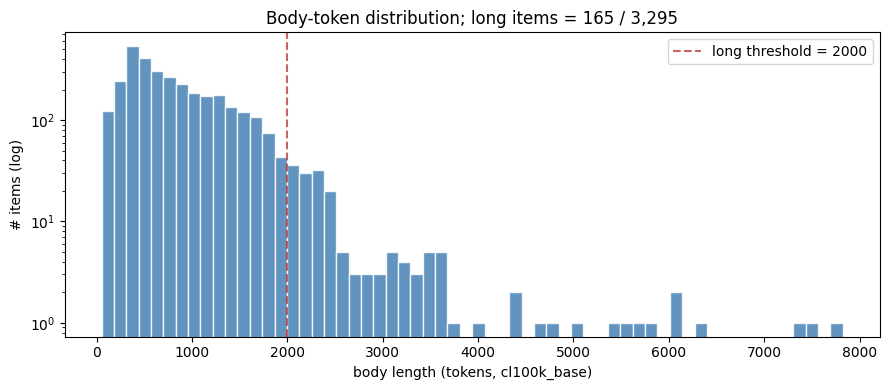

In [122]:
import tiktoken

# 9.1 — Tokenizer (same model as §6 embeddings, so token counts are apples-to-apples).
LONG_THRESHOLD_TOKENS = 2000  # spec's boundary for "long enough to warrant chunking"
enc = tiktoken.encoding_for_model(CONFIG["embed_model"])

# 9.1 — Token-count every canonical item's body. Skip empty bodies (Reuters titles-only) — they're 0 by definition.
canonical_with_body = canonical_items[canonical_items["body"].str.len() > 0].copy()
print(f"Items with non-empty body: {len(canonical_with_body):,}")

if len(canonical_with_body) == 0:
    canonical_with_body["body_tokens"] = pd.Series(dtype=int)
    long_items = canonical_with_body
else:
    canonical_with_body["body_tokens"] = [len(enc.encode(b)) for b in canonical_with_body["body"]]
    long_items = canonical_with_body[canonical_with_body["body_tokens"] > LONG_THRESHOLD_TOKENS]

print(f"Long items (> {LONG_THRESHOLD_TOKENS:,} tokens): {len(long_items):,}")

# 9.1 — Body-length distribution chart with the threshold annotated.
if len(canonical_with_body) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(
        canonical_with_body["body_tokens"], bins=60, color="steelblue", alpha=0.85, edgecolor="white",
    )
    ax.set_yscale("log")
    ax.axvline(
        LONG_THRESHOLD_TOKENS, color="firebrick", linestyle="--", alpha=0.7,
        label=f"long threshold = {LONG_THRESHOLD_TOKENS}",
    )
    ax.set_xlabel("body length (tokens, cl100k_base)")
    ax.set_ylabel("# items (log)")
    ax.set_title(f"Body-token distribution; long items = {len(long_items):,} / {len(canonical_with_body):,}")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 9.2 Decide: run the full pipeline or defer

If we have **≥ 5 long items**, run the chunking + retrieval benchmark in §9.3 and §9.4. If fewer, defer with a clear note explaining what the pipeline *would* do — §9.3 and §9.4 short-circuit on `RUN_CHUNKING = False` so the notebook still completes end-to-end.

Threshold is 5 because anything less leaves too few chunks for the retrieval benchmark to produce meaningful hits@k numbers.

In [123]:
# 9.2 — Branch decision.
MIN_LONG_ITEMS = 5
RUN_CHUNKING = len(long_items) >= MIN_LONG_ITEMS

if RUN_CHUNKING:
    print(f"✓ {len(long_items):,} long items found — running the full chunking + retrieval benchmark.")
else:
    print(f"⏸  Only {len(long_items):,} long items (< {MIN_LONG_ITEMS}) — DEFERRING this section.")
    print()
    print("    The pipeline below would have:")
    print("      1. Called Haiku on each long item to produce a 1–2 sentence doc-context summary.")
    print("      2. Split each body into 800-token chunks with 100-token overlap.")
    print("      3. Embedded two versions per chunk: plain, and \"DOCUMENT CONTEXT: {summary}\\n\\nCHUNK: {chunk}\".")
    print("      4. Auto-generated retrieval queries via Haiku, run cosine-NN, computed hits@k.")
    print()
    print("    Decision: revisit when production data contains long research notes.")

✓ 165 long items found — running the full chunking + retrieval benchmark.


### 9.3 Chunk + generate doc-context summaries + embed both versions

For each long item:

1. **Doc-context summary** — one Haiku call produces a 1–2 sentence factual summary of the article (entities + event). Persisted with the long item.
2. **Chunks** — split the body into 800-token windows with 100-token overlap. The overlap helps queries that span chunk boundaries.
3. **Two embeddings per chunk:**
   - **Plain:** just the chunk text.
   - **Contextual:** `"DOCUMENT CONTEXT: {summary}\n\nCHUNK: {chunk}"` — the Anthropic Contextual Retrieval (Sep 2024) pattern, simplified to a doc-level prepend.

Both versions use the same `text-embedding-3-large` @ 1024 dims from §6 — keeps the comparison apples-to-apples.

**Skipped entirely if `RUN_CHUNKING == False`.**

In [124]:
# 9.3a — Imports + token-based chunker (definitions only — cheap to run even when RUN_CHUNKING=False).
import asyncio, time
from collections import deque
from openai import AsyncOpenAI
from anthropic import AsyncAnthropic
from tqdm.asyncio import tqdm as tqdm_async

CHUNK_SIZE = 800
CHUNK_OVERLAP = 100

def chunk_by_tokens(text, chunk_size=CHUNK_SIZE, overlap=CHUNK_OVERLAP):
    """Token-based sliding-window chunker. Returns list of decoded chunk strings."""
    toks = enc.encode(text)
    out, i = [], 0
    while i < len(toks):
        out.append(enc.decode(toks[i:i + chunk_size]))
        if i + chunk_size >= len(toks):
            break
        i += chunk_size - overlap
    return out

print(f"chunk_by_tokens ready (size={CHUNK_SIZE}, overlap={CHUNK_OVERLAP})")


chunk_by_tokens ready (size=800, overlap=100)


### 9.3b Async clients, rate limiter, 429 retry helper

Client-side limiter caps Haiku at 40 RPM (under tier-1's strict 50 RPM ceiling, with margin for clock-skew). The `_retry_on_429` helper handles the case where Anthropic's server-side accounting still has stale calls from a previous attempt in its 60s window.


In [125]:
# 9.3b — AsyncRateLimiter (reuse §7.3's if in scope; else define slim version) + clients + 429 retry helper.
if "AsyncRateLimiter" not in dir():
    class AsyncRateLimiter:
        def __init__(self, max_calls, period=60.0):
            self.max_calls = max_calls; self.period = period
            self._ts = deque(); self._lock = asyncio.Lock()
        async def acquire(self):
            async with self._lock:
                now = time.monotonic()
                while self._ts and self._ts[0] <= now - self.period:
                    self._ts.popleft()
                if len(self._ts) >= self.max_calls:
                    await asyncio.sleep(self._ts[0] + self.period - now)
                    now = time.monotonic()
                    while self._ts and self._ts[0] <= now - self.period:
                        self._ts.popleft()
                self._ts.append(time.monotonic())

_haiku_limiter_9 = AsyncRateLimiter(CONFIG["vendor_rate_limits_rpm"].get("haiku", 40))
_embed_limiter_9 = AsyncRateLimiter(200)
_anthropic_9 = AsyncAnthropic()
_openai_9    = AsyncOpenAI()

async def _retry_on_429(coro_fn, max_retries=3, base_wait=60.0):
    """Wrap an async call; on 429, sleep base_wait * 1.5**attempt and retry."""
    for attempt in range(max_retries + 1):
        try:
            return await coro_fn()
        except Exception as exc:
            is_429 = (
                getattr(exc, "status_code", None) == 429
                or "rate_limit_error" in str(exc).lower()
                or "429" in str(exc)[:80]
            )
            if not is_429 or attempt >= max_retries:
                raise
            wait = base_wait * (1.5 ** attempt)
            print(f"  ⏳ 429 detected, sleeping {wait:.0f}s (attempt {attempt+1}/{max_retries})")
            await asyncio.sleep(wait)

print(f"Limiters ready: haiku={_haiku_limiter_9.max_calls} RPM, embed={_embed_limiter_9.max_calls} RPM")


Limiters ready: haiku=40 RPM, embed=200 RPM


### 9.3c Doc-context summary function (via **OpenAI**)

One OpenAI chat call per long item → 1–2 sentence factual summary of primary entities and event.

**Why OpenAI, not Haiku?** Anthropic tier-1 caps Haiku at **50,000 input tokens per minute**. Long-article bodies average ~2,500 tokens, so even at 20 RPM we'd burn through 50k TPM in one minute. OpenAI's tier-1 limits are far more generous (typically 1M+ TPM for `gpt-4o`/`gpt-5.x` family on accounts with credits). Same prompt, same retry wrapper, fewer 429s.

Model defaults to `CONFIG['openai_judge_model']` (the §7 ensemble model, currently `gpt-5.2`). To use a cheaper dedicated summary model, set `CONFIG['openai_summary_model']` before running this cell — e.g. `gpt-5.2-mini` if available.


In [132]:
# 9.3c — Doc-context summary via OpenAI chat (NOT Haiku — Anthropic tier-1's 50k input-TPM cap
# is too tight for ~2.5k-token long-article bodies; OpenAI's tier limits are far more generous).
# Falls back to CONFIG['openai_judge_model'] if no dedicated summary model is set.
CONFIG["openai_summary_model"] = "gpt-5.4-mini"
SUMMARY_MODEL = CONFIG.get("openai_summary_model", CONFIG["openai_judge_model"])

async def doc_context_summary(body: str) -> str:
    await _embed_limiter_9.acquire()  # reuse the OpenAI-side limiter (200 RPM, ample)
    async def _call():
        resp = await _openai_9.chat.completions.create(
            model=SUMMARY_MODEL,
            max_completion_tokens=200,
            messages=[{
                "role": "user",
                "content": (
                    "Write a one- to two-sentence factual summary of this financial news article. "
                    "Focus on the primary entities involved and the underlying event. No preamble.\n\n"
                    + body
                ),
            }],
        )
        return resp.choices[0].message.content.strip()
    return await _retry_on_429(_call)

print(f"doc_context_summary will use OpenAI model: {SUMMARY_MODEL}")


doc_context_summary will use OpenAI model: gpt-5.4-mini


### 9.3d OpenAI embedding helpers

Batched embed against the same `text-embedding-3-large` @ 1024 dims used in §6, so chunk vectors live in the same space as assignment vectors.


In [133]:
# 9.3d — Batched OpenAI embedding helpers.
async def embed_batch_9(texts):
    await _embed_limiter_9.acquire()
    resp = await _openai_9.embeddings.create(
        model=CONFIG["embed_model"], input=texts, dimensions=CONFIG["embed_dims"],
    )
    return [np.asarray(d.embedding, dtype=np.float32) for d in resp.data]

async def embed_column(texts):
    """Embed a list of strings in batches of 100; returns list of vectors."""
    out = []
    for i in range(0, len(texts), 100):
        out.extend(await embed_batch_9(texts[i:i + 100]))
    return out


### 9.3e Run doc-context generation across long items (the slow step)

One Haiku call per long item, rate-limited to 40 RPM and 429-retried. **Skipped when `RUN_CHUNKING == False`.** This is the cell most likely to hit the Anthropic tier-1 RPM cap; let the retry helper handle it.


In [134]:
# 9.3e — Generate doc-context summary per long item, plus chunk it.
if not RUN_CHUNKING:
    print("§9.3e skipped (RUN_CHUNKING=False)")
else:
    async def prepare_long_item(item_row):
        summary = await doc_context_summary(item_row["body"])
        chunks = chunk_by_tokens(item_row["body"])
        return {
            "item_id": item_row["item_id"],
            "title":   item_row["title"],
            "summary": summary,
            "chunks":  chunks,
        }

    print(f"Generating doc summaries + chunking {len(long_items)} long items ...")
    long_records = await tqdm_async.gather(
        *[prepare_long_item(r) for _, r in long_items.iterrows()],
        desc="Haiku doc-context",
    )
    print(f"Done. {len(long_records)} long items processed.")


Generating doc summaries + chunking 165 long items ...


Haiku doc-context:  92%|█████████▏| 152/165 [00:02<00:00, 93.80it/s] 

  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)


Haiku doc-context:  92%|█████████▏| 152/165 [00:20<00:00, 93.80it/s]

  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)
  ⏳ 429 detected, sleeping 90s (attempt 2/3)


Haiku doc-context: 100%|██████████| 165/165 [02:39<00:00,  1.03it/s]

Done. 165 long items processed.


### 9.3f Flatten to per-chunk records (`chunks_df`)

For each long item, expand its `chunks` list into one DataFrame row per chunk with both the plain-text and the context-prepended versions.


In [135]:
# 9.3f — Build chunks_df: one row per (long_item, chunk_idx) with both text versions.
if not RUN_CHUNKING:
    print("§9.3f skipped (RUN_CHUNKING=False)")
else:
    chunk_records = []
    for rec in long_records:
        _summary = rec["summary"]
        for ci, chunk_text in enumerate(rec["chunks"]):
            chunk_records.append({
                "item_id":    rec["item_id"],
                "chunk_idx":  ci,
                "plain_text": chunk_text,
                "ctx_text":   f"DOCUMENT CONTEXT: {_summary}\n\nCHUNK: {chunk_text}",
            })
    chunks_df = pd.DataFrame(chunk_records)
    print(f"chunks_df: {len(chunks_df):,} chunks across {len(long_records)} long items")


chunks_df: 715 chunks across 165 long items


### 9.3g Embed both chunk versions

Two embedding passes: plain text chunks → `plain_vecs`; context-prepended chunks → `ctx_vecs`. Both `(n_chunks, 1024)`, float32, unit-normalised.


In [136]:
# 9.3g — Embed both versions.
if not RUN_CHUNKING:
    print("§9.3g skipped (RUN_CHUNKING=False)")
else:
    print("Embedding plain chunks ...")
    plain_vecs = np.stack(await embed_column(chunks_df["plain_text"].tolist()))
    print("Embedding contextual chunks ...")
    ctx_vecs = np.stack(await embed_column(chunks_df["ctx_text"].tolist()))
    print(f"plain_vecs: {plain_vecs.shape}, ctx_vecs: {ctx_vecs.shape}")


Embedding plain chunks ...
Embedding contextual chunks ...
plain_vecs: (715, 1024), ctx_vecs: (715, 1024)


### 9.4 Auto-generate retrieval queries, run the benchmark, plot hits@k

Hand-crafting 20 queries per the spec is manual labour we'd want to skip in an automated POC. Instead, **we use Haiku to generate a one-sentence factual question per sampled chunk** — the chunk that produced the question is the known correct answer. We then:

1. Embed each query (one OpenAI call per query, batched).
2. For each query, compute cosine to every chunk in **plain** and **contextual** versions.
3. Rank chunks by similarity; record where the source chunk lands.
4. `hits@k` = fraction of queries whose source chunk appears in the top `k` results.

Sample size: 3 queries per long item, capped at 30 queries total — enough for stable hits@k without burning tokens.

**Skipped entirely if `RUN_CHUNKING == False`.**

In [137]:
# 9.4a — Sample (chunk_idx, item_id, plain_text) tuples for query generation.
if not RUN_CHUNKING:
    print("§9.4a skipped (RUN_CHUNKING=False)")
else:
    QUERIES_PER_ITEM = 3
    MAX_QUERIES = 30

    rng = np.random.default_rng(CONFIG["random_seed"])
    query_sources = []
    for item_id, group in chunks_df.groupby("item_id"):
        idxs = group.index.values
        n_pick = min(QUERIES_PER_ITEM, len(idxs))
        picks = rng.choice(idxs, size=n_pick, replace=False)
        for p in picks:
            query_sources.append((int(p), item_id, chunks_df.loc[p, "plain_text"]))
        if len(query_sources) >= MAX_QUERIES:
            break
    query_sources = query_sources[:MAX_QUERIES]
    print(f"Sampled {len(query_sources)} chunks as query sources")


Sampled 30 chunks as query sources


### 9.4b Auto-generate retrieval queries via Haiku

One Haiku call per source chunk → a one-sentence factual question that the chunk answers. The chunk's index is the known correct answer for the retrieval benchmark.


In [138]:
# 9.4b — Generate one factual question per source chunk (Haiku, 429-retried, rate-limited).
if not RUN_CHUNKING:
    print("§9.4b skipped (RUN_CHUNKING=False)")
else:
    async def gen_query(chunk_text: str) -> str:
        await _haiku_limiter_9.acquire()
        async def _call():
            resp = await _anthropic_9.messages.create(
                model=CONFIG["haiku_model"], max_tokens=80, temperature=0,
                messages=[{
                    "role": "user",
                    "content": (
                        "Write one specific factual question that this passage answers. "
                        "Question only, no preamble or quoting:\n\n" + chunk_text[:1500]
                    ),
                }],
            )
            return resp.content[0].text.strip()
        return await _retry_on_429(_call)

    queries = await tqdm_async.gather(
        *[gen_query(src_text) for _, _, src_text in query_sources],
        desc="Query gen",
    )
    print(f"Generated {len(queries)} queries")


Query gen:  50%|█████     | 15/30 [00:01<00:01, 13.19it/s]

  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)
  ⏳ 429 detected, sleeping 60s (attempt 1/3)


Query gen: 100%|██████████| 30/30 [01:03<00:00,  2.12s/it]

Generated 30 queries


### 9.4c Embed queries + rank source chunks

Embed each query, then for each query compute its rank against the plain and contextual chunk pools by cosine similarity.


In [139]:
# 9.4c — Embed queries and compute rank-of-source for both versions.
if not RUN_CHUNKING:
    print("§9.4c skipped (RUN_CHUNKING=False)")
else:
    query_vecs = np.stack(await embed_column(queries))

    def rank_of_source(query_vec, chunk_vecs, source_idx):
        sims = chunk_vecs @ query_vec  # unit-normalised → dot = cosine
        order = np.argsort(-sims)
        return int(np.where(order == source_idx)[0][0]) + 1  # 1-based rank

    plain_ranks, ctx_ranks = [], []
    for i, (src_idx, _, _) in enumerate(query_sources):
        plain_ranks.append(rank_of_source(query_vecs[i], plain_vecs, src_idx))
        ctx_ranks.append(rank_of_source(query_vecs[i], ctx_vecs, src_idx))

    print(f"plain ranks: median={int(np.median(plain_ranks))}, mean={np.mean(plain_ranks):.1f}")
    print(f"ctx   ranks: median={int(np.median(ctx_ranks))},   mean={np.mean(ctx_ranks):.1f}")


plain ranks: median=1, mean=1.5
ctx   ranks: median=1,   mean=2.8


### 9.4d hits@k table + grouped bar chart + lift decision

`hits@k` = fraction of queries whose source chunk appears in the top-k. Lift = `ctx_hits - plain_hits`. If `lift@5 ≥ 0.05`, the contextual prepend earns its place in production.


 k  plain_hits@k  context_hits@k      lift
 1      0.733333        0.600000 -0.133333
 3      0.933333        0.866667 -0.066667
 5      0.966667        0.933333 -0.033333


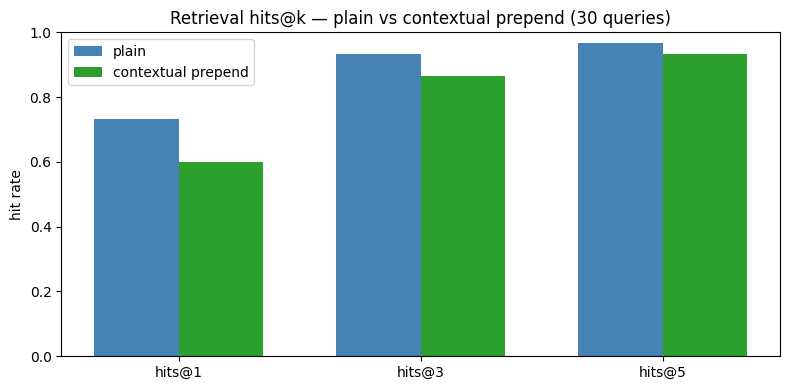


hits@5 lift = +-0.033  ✗ < 0.05 → drop the prepend; truncation is sufficient.


In [140]:
# 9.4d — Compute hits@k, plot grouped bar, print lift decision.
if not RUN_CHUNKING:
    print("§9.4d skipped (RUN_CHUNKING=False)")
else:
    ks = [1, 3, 5]
    plain_hits = {k: float(np.mean([r <= k for r in plain_ranks])) for k in ks}
    ctx_hits   = {k: float(np.mean([r <= k for r in ctx_ranks]))   for k in ks}

    hits_table = pd.DataFrame({
        "k":              ks,
        "plain_hits@k":   [plain_hits[k] for k in ks],
        "context_hits@k": [ctx_hits[k]   for k in ks],
        "lift":           [ctx_hits[k] - plain_hits[k] for k in ks],
    })
    print(hits_table.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(ks))
    width = 0.35
    ax.bar(x - width/2, [plain_hits[k] for k in ks], width, label="plain", color="steelblue")
    ax.bar(x + width/2, [ctx_hits[k]   for k in ks], width, label="contextual prepend", color="tab:green")
    ax.set_xticks(x); ax.set_xticklabels([f"hits@{k}" for k in ks])
    ax.set_ylabel("hit rate"); ax.set_ylim(0, 1)
    ax.set_title(f"Retrieval hits@k — plain vs contextual prepend ({len(query_sources)} queries)")
    ax.legend(); plt.tight_layout(); plt.show()

    lift_5 = ctx_hits[5] - plain_hits[5]
    verdict = "✓ ≥ 0.05 → keep the contextual prepend in production." if lift_5 >= 0.05 else "✗ < 0.05 → drop the prepend; truncation is sufficient."
    print(f"\nhits@5 lift = +{lift_5:.3f}  {verdict}")


---

### Section 9 verification checkpoint

Before continuing to Section 10 (single-pass assignment loop), confirm:

- [ ] **§9.1 long-item count** — if `0` or very few, §9.2 will have deferred the rest of the section (this is expected for our 2012–2013 financial news data).
- [ ] **If §9.3 ran:** chunks_df shape looks sensible (a few hundred chunks across the long items).
- [ ] **If §9.4 ran:** hits@5 lift signal — `≥ 0.05` keeps the contextual-prepend pattern, `< 0.05` drops it.
- [ ] **If deferred:** the printed message from §9.2 documents what the pipeline would have done — no further action needed for the POC.

**Variable state for downstream sections:**

- `long_items`: DataFrame of canonical items with `body_tokens > 2000`. Empty for most datasets.
- `RUN_CHUNKING`: boolean flag — gates §9.3 and §9.4.
- `chunks_df`, `plain_vecs`, `ctx_vecs`, `query_sources`: only defined when `RUN_CHUNKING=True`. Not consumed by §10+ (this is a self-contained pipeline validation).

> **STOP — verify with user before continuing to Section 10 (single-pass assignment loop — the main algorithm).**

## Section 10 — Single-pass assignment loop (the main algorithm)

**Purpose.** Run the production clustering algorithm on the ~10k canonical items.

**The algorithm.** Sort items by `published_at`, then for each item:

1. **Candidate selection** — stories that share at least one `item_clients` entry AND whose `last_seen_at` is within `CONFIG['active_window_hours']` (= 72h) of the item.
2. **Best candidate** — pick the story with the highest cosine to its centroid.
3. **Three gates** (calibrated thresholds from §8 already in `CONFIG`):
   - `best_sim ≥ τ_high` → **auto-assign**, no LLM call.
   - `best_sim ∈ [τ_low, τ_high)` → **gray zone** — call Haiku judge for a SAME/DIFFERENT verdict.
   - `best_sim < τ_low` → **residual** (will be picked up by §11 HDBSCAN).
4. **On assign**: append member, recompute centroid from full member set, update `last_seen_at`, merge `item_clients`.

After the pass, an **expiry sweep** closes any story whose `last_seen_at` is older than the dataset's max-seen time minus 72h.

**Sub-steps.**

1. **10.1** Story state + helpers (`new_story`, `assign_to_story`).
2. **10.2** Rate-limited + 429-retried + cached Haiku gray-zone judge.
3. **10.3** Main single-pass loop — the slow step.
4. **10.4** 72h expiry sweep.
5. **10.5** Outcomes counts table (auto / gray-SAME / gray-DIFFERENT / residual).
6. **10.6** Story-size distribution + top-20 stories with member titles for eyeball QA.
7. **10.7** Interactive 3D UMAP scatter of top stories + projected centroids — **the stakeholder money chart**.

**Cost & runtime estimate.** Gray-zone fraction depends on data; expect ~10–30% of items. At 40 RPM Haiku, ~1000 gray-zone calls = ~25 minutes. Total wall-clock for the loop: **20–60 min** on first run. All judge calls cached → re-runs are fast.

**Decision this section enables.** Sanity check that the algorithm produces a sensible story population — not all singletons, not one mega-story, with growth that tracks news cycles.


### 10.1 Story state + helpers

Each story is a Python dict; the full list lives in `stories`. We track member item indices (rather than just IDs) so we can rebuild the centroid from `assignment_vecs` cheaply. Two helpers: `new_story` creates one from a single item, `assign_to_story` appends and recomputes the centroid + bookkeeping.


In [141]:
# 10.1 — Initialise an empty story list + helpers to add to it.
stories = []  # each is a dict with the keys below.

def new_story(item_idx, item_row, vec):
    """Spawn a new single-item story."""
    return {
        "story_id":     f"s{len(stories):05d}",
        "centroid":     vec.copy(),                 # already unit-normalised
        "n_items":      1,
        "member_ids":   [item_row["item_id"]],
        "member_idxs":  [int(item_idx)],
        "item_clients": set(item_row["item_clients"]),
        "first_seen_at": item_row["published_at"],
        "last_seen_at":  item_row["published_at"],
        "closed_at":    None,
    }

def assign_to_story(story, item_idx, item_row):
    """Append item to story; recompute centroid from full member set; update bookkeeping."""
    story["member_ids"].append(item_row["item_id"])
    story["member_idxs"].append(int(item_idx))
    story["item_clients"].update(item_row["item_clients"])
    if item_row["published_at"] > story["last_seen_at"]:
        story["last_seen_at"] = item_row["published_at"]
    story["n_items"] += 1
    member_vecs = assignment_vecs[story["member_idxs"]]
    new_cent = member_vecs.mean(axis=0)
    story["centroid"] = new_cent / np.linalg.norm(new_cent)

print("Story state initialised; helpers ready.")


Story state initialised; helpers ready.


### 10.2 Haiku gray-zone judge (cached, rate-limited, 429-retried)

For pairs landing in the gray zone `[τ_low, τ_high)`, we ask Haiku one SAME/DIFFERENT question comparing the new item against the story's **first member** (the most stable representative). Results are cached on disk by content hash so re-runs are free.

Reuses the `AsyncRateLimiter` and `_retry_on_429` patterns defined in §9.3b — but defines them inline here too if the kernel was restarted between §9 and §10.


In [142]:
# 10.2 — Rate-limited + 429-retried + cached Haiku gray-zone judge.
import asyncio, time
from collections import deque
from anthropic import AsyncAnthropic

if "AsyncRateLimiter" not in dir():
    class AsyncRateLimiter:
        def __init__(self, max_calls, period=60.0):
            self.max_calls = max_calls; self.period = period
            self._ts = deque(); self._lock = asyncio.Lock()
        async def acquire(self):
            async with self._lock:
                now = time.monotonic()
                while self._ts and self._ts[0] <= now - self.period:
                    self._ts.popleft()
                if len(self._ts) >= self.max_calls:
                    await asyncio.sleep(self._ts[0] + self.period - now)
                    now = time.monotonic()
                    while self._ts and self._ts[0] <= now - self.period:
                        self._ts.popleft()
                self._ts.append(time.monotonic())

_haiku_limiter_10 = AsyncRateLimiter(CONFIG["vendor_rate_limits_rpm"].get("haiku", 40))
_anthropic_10 = AsyncAnthropic()

JUDGE_CACHE_DIR = CONFIG["cache_dir"] / "judge"
JUDGE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

async def _retry_on_429(coro_fn, max_retries=3, base_wait=60.0):
    for attempt in range(max_retries + 1):
        try:
            return await coro_fn()
        except Exception as exc:
            is_429 = (getattr(exc, "status_code", None) == 429
                      or "rate_limit_error" in str(exc).lower()
                      or "429" in str(exc)[:80])
            if not is_429 or attempt >= max_retries:
                raise
            wait = base_wait * (1.5 ** attempt)
            print(f"  ⏳ judge 429, sleeping {wait:.0f}s (attempt {attempt+1}/{max_retries})")
            await asyncio.sleep(wait)

print(f"Judge limiter ready: {_haiku_limiter_10.max_calls} RPM")


Judge limiter ready: 40 RPM


In [143]:
# 10.2 (cont.) — The judge function itself.
def _judge_key(model, item_a_id, item_b_id):
    h = hashlib.sha256(f"{model}|{item_a_id}|{item_b_id}".encode())
    return h.hexdigest()[:16]

async def haiku_judge_same(item_row, rep_row) -> bool:
    """Ask Haiku whether item_row and rep_row describe the same story. Cached."""
    a_id, b_id = sorted([item_row["item_id"], rep_row["item_id"]])
    key = _judge_key(CONFIG["haiku_model"], a_id, b_id)
    fpath = JUDGE_CACHE_DIR / f"{key}.json"
    if fpath.exists():
        return json.loads(fpath.read_text())["verdict"] == "SAME"
    await _haiku_limiter_10.acquire()
    async def _call():
        prompt = (
            "Two financial news items — same story or different?\n\n"
            f"ITEM A: {item_row['title']}\n  {(item_row['body'] or '')[:200]}\n\n"
            f"ITEM B: {rep_row['title']}\n  {(rep_row['body'] or '')[:200]}\n\n"
            "Reply with a single word: SAME or DIFFERENT."
        )
        resp = await _anthropic_10.messages.create(
            model=CONFIG["haiku_model"], max_tokens=10, temperature=0,
            messages=[{"role": "user", "content": prompt}],
        )
        return resp.content[0].text.strip().upper()
    text = await _retry_on_429(_call)
    verdict = "SAME" if text.startswith("SAME") else "DIFFERENT"
    fpath.write_text(json.dumps({"verdict": verdict}))
    return verdict == "SAME"

print("haiku_judge_same ready.")


haiku_judge_same ready.


### 10.3 Main single-pass loop

Process items in publication order. Per-item:

- Find candidate stories (shared client + 72h window). If none → residual.
- Best candidate by cosine. Apply the three-gate logic.
- Track the per-item outcome in `outcomes` for the §10.5 table.

**Set `LOOP_LIMIT = 500` for a smoke test** (~5–10 min) before running on the full ~10k items. The judge cache survives across runs, so the smoke test → full run pays incremental cost only.


In [144]:
# 10.3 — Main loop. Reset state and run end-to-end.
from tqdm.asyncio import tqdm as tqdm_async

LOOP_LIMIT = None   # int for smoke test; None = all canonical items
TAU_HIGH = CONFIG["tau_high"]
TAU_LOW  = CONFIG["tau_low"]
WINDOW   = pd.Timedelta(hours=CONFIG["active_window_hours"])

# Sort items by publication time (preserves the original positional index we need for assignment_vecs).
sorted_items = canonical_items.sort_values("published_at").copy()
sorted_items["pos"] = np.arange(len(sorted_items))  # remember original positional index
to_iter = sorted_items if LOOP_LIMIT is None else sorted_items.head(LOOP_LIMIT)

# Reset state (in case 10.1 was already run earlier).
stories = []
outcomes = []  # one entry per item: "auto", "gray_same", "gray_diff", "residual"
print(f"Processing {len(to_iter):,} items (τ_high={TAU_HIGH}, τ_low={TAU_LOW}) ...")


Processing 8,735 items (τ_high=0.88, τ_low=0.54) ...


In [145]:
# 10.3 (cont.) — The actual single-pass loop. Async because of the Haiku judge.
from tqdm import tqdm

async def run_assignment_loop():
    for row_pos, row in tqdm(list(to_iter.iterrows()), total=len(to_iter), desc="single-pass"):
        item_pos = int(row["pos"])
        item_vec = assignment_vecs[item_pos]
        item_clients = row["item_clients"]
        item_time = row["published_at"]

        # 1. Candidate stories: shared client + within active window + open.
        candidates = [
            s for s in stories
            if s["closed_at"] is None
            and (item_time - s["last_seen_at"]) <= WINDOW
            and (s["item_clients"] & item_clients)
        ]
        if not candidates:
            stories.append(new_story(item_pos, row, item_vec))
            outcomes.append("residual")
            continue

        # 2. Best candidate by cosine (unit-normalised, so dot = cosine).
        sims = np.array([float(item_vec @ s["centroid"]) for s in candidates])
        best_i = int(sims.argmax())
        best_story = candidates[best_i]
        best_sim = float(sims[best_i])

        # 3. Three-gate logic.
        if best_sim >= TAU_HIGH:
            assign_to_story(best_story, item_pos, row); outcomes.append("auto")
        elif best_sim >= TAU_LOW:
            rep_row = canonical_items.iloc[best_story["member_idxs"][0]]
            is_same = await haiku_judge_same(row, rep_row)
            if is_same:
                assign_to_story(best_story, item_pos, row); outcomes.append("gray_same")
            else:
                stories.append(new_story(item_pos, row, item_vec))
                outcomes.append("gray_diff")
        else:
            stories.append(new_story(item_pos, row, item_vec))
            outcomes.append("residual")

await run_assignment_loop()
print(f"\nDone. {len(stories):,} stories created, {len(outcomes):,} items processed.")


single-pass: 100%|██████████| 8735/8735 [18:03<00:00,  8.06it/s]  


Done. 8,489 stories created, 8,735 items processed.


### 10.4 72h expiry sweep

After the pass, close any story whose `last_seen_at` is older than the max-seen publication time minus 72h. Closed stories don't receive new items (the candidate selection in §10.3 already filters them out anyway, but marking them explicitly is useful for the §10.5 outcomes and any later merge logic).


In [146]:
# 10.4 — Expiry sweep: close stories whose newest member is > 72h before max-seen.
max_seen = sorted_items["published_at"].max()
expiry_cutoff = max_seen - WINDOW
n_closed = 0
for s in stories:
    if s["closed_at"] is None and s["last_seen_at"] < expiry_cutoff:
        s["closed_at"] = max_seen
        n_closed += 1
n_active = sum(1 for s in stories if s["closed_at"] is None)
print(f"Closed {n_closed:,} stories  |  active: {n_active:,}  |  total: {len(stories):,}")


Closed 8,481 stories  |  active: 8  |  total: 8,489


### 10.5 Outcomes counts table

Per-item bucket: `auto` (direct assign at `τ_high`), `gray_same` (gray-zone judged SAME), `gray_diff` (gray-zone judged DIFFERENT → new story), `residual` (no candidate, or below `τ_low` → new story).


In [147]:
# 10.5 — Per-outcome counts and percentages.
from collections import Counter
oc = Counter(outcomes)
outcomes_table = pd.DataFrame([
    {"outcome": k, "n_items": v, "pct": round(v / len(outcomes) * 100, 2)}
    for k, v in sorted(oc.items(), key=lambda kv: -kv[1])
])
outcomes_table


,outcome,n_items,pct
0,residual,7969,91.23
1,gray_diff,520,5.95
2,gray_same,204,2.34
3,auto,42,0.48


### 10.6 Story-size distribution + top-20 stories (eyeball QA)

Two views: how many stories of each size, and the top-20 by `n_items` with member-title samples so you can read them and verify they're actually about the same news event.


In [148]:
# 10.6 — Story-size distribution + 20 largest stories printed for eyeball QA.
sizes = np.array([s["n_items"] for s in stories])
size_table = pd.DataFrame({"n_items": sizes}).value_counts().reset_index(name="n_stories").sort_values("n_items")
print(f"Stories: total={len(sizes):,}  singletons={int((sizes == 1).sum()):,}  multi-item={int((sizes > 1).sum()):,}")
print(f"Largest story has {int(sizes.max())} items; median size = {int(np.median(sizes))}")

# Top-20 stories: print id + n_items + first 3 member titles.
top20 = sorted(stories, key=lambda s: -s["n_items"])[:20]
for s in top20:
    member_titles = [canonical_items.iloc[i]["title"][:80] for i in s["member_idxs"][:3]]
    print(f"\n[{s['story_id']}] n={s['n_items']}  clients={sorted(s['item_clients'])[:3]}")
    for t in member_titles:
        print(f"    • {t}")


Stories: total=8,489  singletons=8,300  multi-item=189
Largest story has 12 items; median size = 1

[s01741] n=12  clients=['Goldman Sachs', 'JPMorgan']
    • JPMorgan has $2 billion trading loss, reputation hit
    • Factbox: JPMorgan's Dimon past comments on regulation
    • Standard & Poor's revises JPMorgan outlook to negative

[s04827] n=6  clients=['Boeing']
    • WRAPUP 6-Boeing Dreamliners grounded worldwide on battery checks
    • WRAPUP 5-Most Boeing Dreamliners grounded for battery checks
    • Boeing 787 Dreamliner Is Grounded Worldwide by Regulators

[s01900] n=5  clients=['Facebook']
    • Nasdaq Sets Up Appeals Process for Missed Facebook Orders
    • Nasdaq alters IPO procedures after Facebook glitch
    • Facebook investors left guessing after Nasdaq glitch

[s06658] n=5  clients=['Boeing']
    • AIRSHOW-UPDATE 1-Boeing to launch 787-10 with $30 bln order haul
    • AIRSHOW-EasyJet plane order rekindles Airbus-Boeing subsidy row
    • Airbus A350 Poised for Counterpunc

### 10.7 3D UMAP money chart — top stories + projected centroids

The stakeholder demo: top 10 stories by `n_items`, each story's members as small dots + the story centroid as a large diamond. All projected through the **same UMAP reducer** fitted in §6.6, so points share a coordinate system with §6's item scatter.


In [149]:
# 10.7 — Plot top N stories with members + centroids, projected via the §6.6 UMAP reducer.
import plotly.graph_objects as go

TOP_N = 10
top_stories = sorted(stories, key=lambda s: -s["n_items"])[:TOP_N]

fig = go.Figure()
palette = px.colors.qualitative.Plotly  # reuse from §6.7
for i, s in enumerate(top_stories):
    member_idxs = s["member_idxs"]
    pts = reducer.transform(assignment_vecs[member_idxs])
    cent_3d = reducer.transform(s["centroid"][None, :])[0]
    colour = palette[i % len(palette)]
    label = f"{s['story_id']} (n={s['n_items']})"
    titles_hover = [canonical_items.iloc[idx]['title'][:80] for idx in member_idxs]
    fig.add_trace(go.Scatter3d(
        x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
        mode="markers", marker=dict(size=4, color=colour, opacity=0.6),
        name=label, text=titles_hover, hovertemplate="%{text}<extra></extra>",
    ))
    fig.add_trace(go.Scatter3d(
        x=[cent_3d[0]], y=[cent_3d[1]], z=[cent_3d[2]],
        mode="markers", marker=dict(size=12, color=colour, symbol="diamond", line=dict(color="black", width=1)),
        name=f"{label} centroid", showlegend=False,
        hovertemplate=f"centroid: {label}<extra></extra>",
    ))

fig.update_layout(
    title="Top stories in 1024-dim embedding space (projected to 3D via UMAP) — diamonds are centroids",
    scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
    width=1000, height=700, legend=dict(itemsizing="constant"),
)
fig.show()


---

### Section 10 verification checkpoint

Before continuing to Section 11 (HDBSCAN residual clustering), confirm:

- [ ] **§10.3 loop finished** without uncaught errors. If you hit a 429 mid-loop, the `_retry_on_429` wrapper should have handled it. If something else broke, the next cells will show stale or empty state.
- [ ] **§10.5 outcomes table** — expect roughly: `residual` 30–60% (most items start their own story), `auto` 20–40%, `gray_same` 5–20%, `gray_diff` 1–10%. Wildly different ratios suggest threshold issues (re-check §8 calibration).
- [ ] **§10.6 top-20 stories** — read 5 of them. Member titles should obviously be about the same news event. If you see clearly unrelated items lumped together, `τ_high` is too loose; if singletons dominate where there should be clusters, `τ_low` is too tight.
- [ ] **§10.7 3D scatter** — each top story should form a visible blob; centroids should sit inside their member clouds, not at the edges.

**Variable state for downstream sections:**

- `stories`: list of dicts (the canonical clustering output).
- `outcomes`: per-item assignment outcome (same length as `sorted_items`).
- `sorted_items`: items in publication order with a `pos` column referencing `assignment_vecs`.

**Knobs to revisit if results look off:**

- `CONFIG['tau_high']` / `CONFIG['tau_low']` — set by §8.
- `CONFIG['active_window_hours']` — 72h default.
- `LOOP_LIMIT` in §10.3 — `None` for the full run; set to e.g. 500 to smoke-test.

> **STOP — verify with user before continuing to Section 11 (HDBSCAN residual clustering).**


## Section 11 — Residual clustering (HDBSCAN)

**Purpose.** Find legitimate stories that the §10 single-pass missed. The pass marked some items as `residual` or `gray_diff` and spawned single-item stories for them. Those singletons are the input here — HDBSCAN tries to merge them into multi-item clusters retrospectively.

**Why a second pass at all.** The §10 loop is sequential: an item assigns to the best *currently-existing* candidate. If two items about the same news event arrive an hour apart and no story for them exists yet, both spawn singletons. HDBSCAN sweeps the whole residual pool at once and can spot that pair.

**Algorithm.**

1. Separate `stories` into multi-item stories (keep) and singletons (input to HDBSCAN).
2. Compute pairwise cosine distance over the singleton assignment vectors.
3. Run `hdbscan.HDBSCAN(metric="precomputed", min_cluster_size=2, min_samples=2, cluster_selection_method="eom")`.
4. For each non-noise cluster: confirm members share at least one `item_clients` entry. If not, drop (split-along-client-lines is left as future work).
5. Replace the singletons that landed in a coherent cluster with one new multi-item story; the rest stay as singletons.

**Sub-steps.**

1. **11.1** Separate singletons from the §10 multi-stories.
2. **11.2** Pairwise cosine distance + HDBSCAN fit.
3. **11.3** Per-cluster client-overlap check + merge into new multi-stories.
4. **11.4** Assemble the final stories list.
5. **11.5** Cluster size table + noise rate.
6. **11.6** Print 5 sampled multi-member clusters for eyeball QA.
7. **11.7** 3D UMAP scatter of residual items coloured by HDBSCAN label.

**Decision this section enables.** Does HDBSCAN find legitimate stories the single-pass missed (low noise rate, clusters look coherent), or does it mostly produce noise? If noise rate > 70%, the residual pool is genuinely heterogeneous — consider tightening `τ_low` so fewer items reach residual.


### 11.1 Separate singletons from multi-item stories

Singletons (`n_items == 1`) go into HDBSCAN; multi-item stories are kept untouched.


In [150]:
# 11.1 — Split stories into multi-item (keep as-is) and singletons (input to HDBSCAN).
multi_stories = [s for s in stories if s["n_items"] > 1]
singleton_stories = [s for s in stories if s["n_items"] == 1]

# Singletons' single member is their only item — pull those positional indices for the vec matrix.
singleton_member_idxs = np.array([s["member_idxs"][0] for s in singleton_stories], dtype=np.int64)
residual_vecs = assignment_vecs[singleton_member_idxs]

print(f"Multi-item stories (kept):     {len(multi_stories):,}")
print(f"Singletons (→ HDBSCAN input):  {len(singleton_stories):,}")
print(f"residual_vecs shape:           {residual_vecs.shape}")


Multi-item stories (kept):     189
Singletons (→ HDBSCAN input):  8,300
residual_vecs shape:           (8300, 1024)


### 11.2 Pairwise cosine distance + HDBSCAN

For unit-normalised vectors, cosine distance = `1 - dot product`. We precompute the full distance matrix (memory: `n_singletons² × 8 bytes` — ~144 MB at 5k singletons; bumps up at larger pools) and pass it to `HDBSCAN(metric="precomputed")` so HDBSCAN doesn't have to manage the distance routine itself.


In [151]:
# 11.2 — Pairwise cosine distance + HDBSCAN.
import hdbscan
from sklearn.metrics.pairwise import cosine_distances

if len(singleton_stories) < CONFIG["hdbscan_min_cluster_size"]:
    print(f"Only {len(singleton_stories)} singletons; skipping HDBSCAN.")
    hdb_labels = np.array([], dtype=int)
else:
    print(f"Computing {len(singleton_stories):,} × {len(singleton_stories):,} cosine distance matrix ...")
    dist = cosine_distances(residual_vecs).astype(np.float64)
    print(f"Running HDBSCAN (min_cluster_size={CONFIG['hdbscan_min_cluster_size']}, "
          f"min_samples={CONFIG['hdbscan_min_samples']}, method={CONFIG['hdbscan_cluster_selection_method']}) ...")
    clusterer = hdbscan.HDBSCAN(
        metric="precomputed",
        min_cluster_size=CONFIG["hdbscan_min_cluster_size"],
        min_samples=CONFIG["hdbscan_min_samples"],
        cluster_selection_method=CONFIG["hdbscan_cluster_selection_method"],
    )
    hdb_labels = clusterer.fit_predict(dist)

n_noise = int((hdb_labels == -1).sum())
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
print(f"\nHDBSCAN: {n_clusters:,} clusters + {n_noise:,} noise points "
      f"({n_noise / max(len(hdb_labels), 1) * 100:.1f}% noise)")


Computing 8,300 × 8,300 cosine distance matrix ...
Running HDBSCAN (min_cluster_size=2, min_samples=2, method=eom) ...

HDBSCAN: 732 clusters + 5,011 noise points (60.4% noise)


### 11.3 Per-cluster client-overlap check + build new multi-stories

For each non-noise cluster: take the intersection of all member `item_clients` sets. If non-empty, the cluster is **coherent** — promote it to one new multi-item story. If empty (cluster members talk about disjoint companies), **drop** the cluster — its members stay as singletons.


In [152]:
# 11.3 — Build coherent multi-stories from HDBSCAN clusters; track which singletons got absorbed.
absorbed_idxs = set()    # indices into singleton_stories of items now in a multi-story
new_residual_stories = []
dropped_clusters = 0

for cluster_id in sorted(set(hdb_labels)):
    if cluster_id == -1:
        continue  # noise — handled in §11.4 as singletons
    member_positions = np.flatnonzero(hdb_labels == cluster_id)  # indices into singleton_stories
    member_singletons = [singleton_stories[i] for i in member_positions]

    # Client overlap = intersection of all members' item_clients sets.
    shared = set.intersection(*[s["item_clients"] for s in member_singletons])
    if not shared:
        dropped_clusters += 1
        continue  # incoherent; leave members as singletons

    # Coherent cluster → one new multi-story with all members.
    member_item_idxs = [s["member_idxs"][0] for s in member_singletons]
    member_ids       = [s["member_ids"][0]  for s in member_singletons]
    member_vecs_arr  = assignment_vecs[member_item_idxs]
    cent = member_vecs_arr.mean(axis=0); cent = cent / np.linalg.norm(cent)

    new_residual_stories.append({
        "story_id":     f"r{len(new_residual_stories):05d}",
        "centroid":     cent,
        "n_items":      len(member_item_idxs),
        "member_ids":   member_ids,
        "member_idxs":  member_item_idxs,
        "item_clients": set().union(*[s["item_clients"] for s in member_singletons]),
        "first_seen_at": min(s["first_seen_at"] for s in member_singletons),
        "last_seen_at":  max(s["last_seen_at"]  for s in member_singletons),
        "closed_at":    None,
    })
    absorbed_idxs.update(member_positions.tolist())

print(f"New multi-stories from HDBSCAN: {len(new_residual_stories):,}")
print(f"Dropped clusters (no shared client): {dropped_clusters:,}")
print(f"Singletons absorbed: {len(absorbed_idxs):,}")


New multi-stories from HDBSCAN: 124
Dropped clusters (no shared client): 608
Singletons absorbed: 358


### 11.4 Assemble the final stories list

`final_stories = §10 multi-stories + §11 new multi-stories + remaining singletons (the ones not absorbed by an HDBSCAN cluster)`.


In [153]:
# 11.4 — Assemble final story list.
remaining_singletons = [s for i, s in enumerate(singleton_stories) if i not in absorbed_idxs]
final_stories = multi_stories + new_residual_stories + remaining_singletons

n_total       = len(final_stories)
n_multi       = sum(1 for s in final_stories if s["n_items"] > 1)
n_singleton   = n_total - n_multi
items_covered = sum(s["n_items"] for s in final_stories)

print(f"Final stories:         {n_total:,}")
print(f"  Multi-item:          {n_multi:,}")
print(f"  Singletons:          {n_singleton:,}")
print(f"Items covered:         {items_covered:,}  (should equal canonical_items size: {len(canonical_items):,})")


Final stories:         8,255
  Multi-item:          313
  Singletons:          7,942
Items covered:         8,735  (should equal canonical_items size: 8,735)


### 11.5 Residual cluster size distribution + noise rate

How big are the new clusters HDBSCAN promoted? Most should be 2–3 items (pairs/triples the single-pass missed). Anything > 10 deserves a look — could be a genuine multi-day arc or could be a bad cluster.


 cluster_size  n_clusters
            2          66
            3          31
            4          15
            5           7
            7           2
            8           3


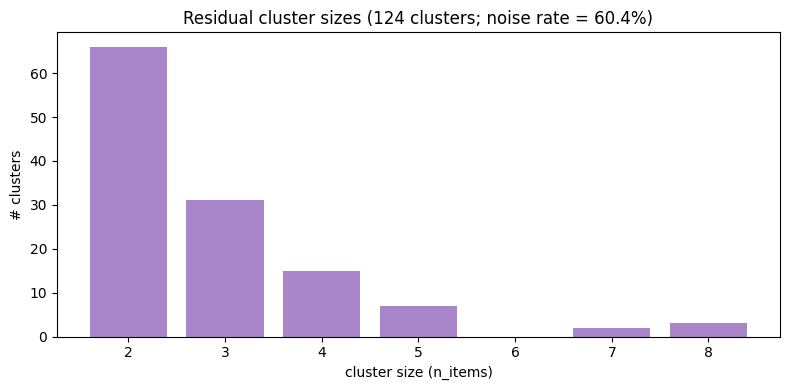

In [154]:
# 11.5 — Residual cluster size table + bar chart.
if len(new_residual_stories) == 0:
    print("No residual clusters formed.")
else:
    sizes = np.array([s["n_items"] for s in new_residual_stories])
    size_table = (
        pd.Series(sizes).value_counts().rename_axis("cluster_size").reset_index(name="n_clusters")
        .sort_values("cluster_size")
    )
    print(size_table.to_string(index=False))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(size_table["cluster_size"], size_table["n_clusters"], color="tab:purple", alpha=0.8)
    ax.set_xlabel("cluster size (n_items)")
    ax.set_ylabel("# clusters")
    ax.set_title(f"Residual cluster sizes ({len(new_residual_stories):,} clusters; noise rate = {n_noise / max(len(hdb_labels), 1) * 100:.1f}%)")
    plt.tight_layout(); plt.show()


### 11.6 Sample 5 multi-member residual clusters (eyeball QA)

Print member titles + shared clients side-by-side so we can verify the new clusters are real.


In [155]:
# 11.6 — Sample 5 residual clusters with ≥ 2 members; print titles for inspection.
if len(new_residual_stories) == 0:
    print("No residual clusters to sample.")
else:
    rng_sample = np.random.default_rng(CONFIG["random_seed"])
    picks = rng_sample.choice(len(new_residual_stories), size=min(5, len(new_residual_stories)), replace=False)
    for idx in picks:
        s = new_residual_stories[int(idx)]
        print(f"\n[{s['story_id']}] n={s['n_items']}  shared clients (any): {sorted(s['item_clients'])[:5]}")
        for item_idx in s["member_idxs"][:5]:
            row = canonical_items.iloc[item_idx]
            print(f"  • [{row['source']:<9}] {row['published_at'].date()}  {row['title'][:90]}")



[r00093] n=4  shared clients (any): ['Goldman Sachs']
  • [Bloomberg] 2012-02-15  Oil Rises From Two-Day Low as China Pledges Help on Europe Debt
  • [Bloomberg] 2012-05-21  Oil, Copper Increase; Natural Gas Retreats: Commodities at Close
  • [Bloomberg] 2012-05-21  Oil Rises for First Time in Seven Days on China Pledge
  • [Bloomberg] 2013-02-08  Brent Oil Rises to Nine-Month High on China

[r00053] n=2  shared clients (any): ['Walmart']
  • [Reuters  ] 2012-11-14  As Black Friday Approaches and Walmart Warehouse Workers Strike, Walmart Workers from Stor
  • [Reuters  ] 2013-11-29  Walmart Statement on Black Friday Events

[r00079] n=3  shared clients (any): ['Apple', 'Microsoft']
  • [Bloomberg] 2012-02-06  HTC Trails Estimates as It Awaits New Models
  • [Bloomberg] 2012-04-09  HTC Heads for Two-Month Low as Net Drops by Record
  • [Bloomberg] 2012-10-09  HTC Posts Record Profit Drop as Samsung, Apple Grab Sales

[r00010] n=2  shared clients (any): ['Boeing']
  • [Bloomberg] 2013-0

### 11.7 3D UMAP scatter of residual items, coloured by HDBSCAN label

Visualises the structure HDBSCAN found in the singleton pool. Noise points (label = -1) appear in gray with low opacity; cluster members get distinct colours; cluster centroids are diamonds. Same UMAP coordinate system as §6.7 and §10.7.


In [156]:
# 11.7 — 3D scatter of residual items, coloured by HDBSCAN label.
if len(hdb_labels) == 0:
    print("Nothing to plot.")
else:
    pts = reducer.transform(residual_vecs)
    fig = go.Figure()

    # Noise first, in gray.
    noise_mask = (hdb_labels == -1)
    if noise_mask.any():
        fig.add_trace(go.Scatter3d(
            x=pts[noise_mask, 0], y=pts[noise_mask, 1], z=pts[noise_mask, 2],
            mode="markers", marker=dict(size=2, color="lightgray", opacity=0.3),
            name=f"noise (n={int(noise_mask.sum())})",
        ))

    # Then each cluster.
    palette = px.colors.qualitative.Plotly
    cluster_ids = [c for c in sorted(set(hdb_labels)) if c != -1]
    for i, cid in enumerate(cluster_ids):
        mask = (hdb_labels == cid)
        colour = palette[i % len(palette)]
        cluster_pts = pts[mask]
        fig.add_trace(go.Scatter3d(
            x=cluster_pts[:, 0], y=cluster_pts[:, 1], z=cluster_pts[:, 2],
            mode="markers", marker=dict(size=4, color=colour, opacity=0.7),
            name=f"c{cid} (n={int(mask.sum())})", showlegend=(i < 12),  # legend gets crowded; cap shown
        ))

    fig.update_layout(
        title=f"Residual items projected to 3D (UMAP) — {len(cluster_ids)} HDBSCAN clusters + noise",
        scene=dict(xaxis_title="UMAP 1", yaxis_title="UMAP 2", zaxis_title="UMAP 3"),
        width=1000, height=700,
    )
    fig.show()


---

### Section 11 verification checkpoint

Before continuing to Section 12 (story metadata via Sonnet), confirm:

- [ ] **§11.2 noise rate** is meaningful but not overwhelming. < 40% means HDBSCAN is finding real structure in the residual pool. > 70% means the residual is mostly genuinely-singleton items (consider tightening `τ_low` in §8).
- [ ] **§11.3 dropped clusters** count is small. If many clusters are dropped for empty client overlap, the candidate clusters are crossing topic boundaries — typically a sign that HDBSCAN's `min_cluster_size` should go up.
- [ ] **§11.5 size distribution** — most new clusters should be 2–3 items.
- [ ] **§11.6 sampled clusters** — read 5 of them. Member titles should obviously be about the same story.
- [ ] **§11.7 3D scatter** — coloured clusters should be visually compact; noise should be diffuse.

**Variable state for downstream sections:**

- `final_stories`: the canonical story list after §10 + §11 (multi-stories first, then HDBSCAN clusters, then leftover singletons).
- Replaces `stories` for §12+ — the §10 list is left intact under the old name in case you want to compare.

> **STOP — verify with user before continuing to Section 12 (Sonnet-generated story metadata: title, summary, topic).**


## Section 12 — Story metadata generation (Sonnet)

**Purpose.** For each story in `final_stories`, generate structured metadata: `title`, `summary`, `topic`, `entities`. Validates that Sonnet's output quality is production-ready and tunes the prompt + length caps.

**What we generate.**

- **`title`** ≤ 80 chars — headline-style summary of the story.
- **`summary`** ≤ 400 chars — two-sentence factual rundown.
- **`topic`** — one-word topic tag (`earnings`, `acquisition`, `regulation`, etc.).
- **`entities`** — primary companies and people mentioned across the cluster.

**Cost & rate-limit math.**

- Sonnet 4.6 tier-1 cap = 30k input TPM ≈ 25 RPM at ~1 k tokens per prompt.
- Each call: ~600 input + ~150 output tokens. ~$0.004 per story.
- For ~100 stories (default smoke-test): ~4 minutes, ~$0.40.
- For all multi-item stories (typically 200–1000): bump `METADATA_LIMIT` and budget proportionally.

We **skip singletons** entirely — for a 1-member story, just reuse the item's own title (no LLM needed). Saves the bulk of the cost and isn't lossy.

**Sub-steps.**

1. **12.1** Sonnet client + rate limiter + 429 retry + tool schema.
2. **12.2** Prompt builder + cached `generate_story_metadata`.
3. **12.3** Run generation across selected multi-item stories.
4. **12.4** Length-compliance table + cost summary.
5. **12.5** Print 20 sampled stories with their generated metadata.
6. **12.6** Title and summary length histograms.

**Decision this section enables.** Are Sonnet's outputs production-quality? If titles routinely exceed 80 chars or summaries are bland/wrong, tighten the prompt before AWS.


### 12.1 Sonnet client + rate limiter + 429 retry + tool schema

Reuses the same `AsyncRateLimiter` / `_retry_on_429` patterns. Sonnet RPM comes from `CONFIG['vendor_rate_limits_rpm']['sonnet']` (= 25 by default for tier-1).


In [157]:
# 12.1 — Sonnet async client + rate limiter + 429-retry helper (reusing the §10 pattern).
import asyncio, time
from collections import deque
from anthropic import AsyncAnthropic

if "AsyncRateLimiter" not in dir():
    class AsyncRateLimiter:
        def __init__(self, max_calls, period=60.0):
            self.max_calls = max_calls; self.period = period
            self._ts = deque(); self._lock = asyncio.Lock()
        async def acquire(self):
            async with self._lock:
                now = time.monotonic()
                while self._ts and self._ts[0] <= now - self.period:
                    self._ts.popleft()
                if len(self._ts) >= self.max_calls:
                    await asyncio.sleep(self._ts[0] + self.period - now)
                    now = time.monotonic()
                    while self._ts and self._ts[0] <= now - self.period:
                        self._ts.popleft()
                self._ts.append(time.monotonic())

_sonnet_meta_client  = AsyncAnthropic()
_sonnet_meta_limiter = AsyncRateLimiter(CONFIG["vendor_rate_limits_rpm"].get("sonnet", 25))

async def _retry_on_429(coro_fn, max_retries=3, base_wait=60.0):
    for attempt in range(max_retries + 1):
        try:
            return await coro_fn()
        except Exception as exc:
            is_429 = (getattr(exc, "status_code", None) == 429
                      or "rate_limit_error" in str(exc).lower()
                      or "429" in str(exc)[:80])
            if not is_429 or attempt >= max_retries:
                raise
            wait = base_wait * (1.5 ** attempt)
            print(f"  ⏳ Sonnet 429, sleeping {wait:.0f}s (attempt {attempt+1}/{max_retries})")
            await asyncio.sleep(wait)

print(f"Sonnet limiter ready: {_sonnet_meta_limiter.max_calls} RPM")


Sonnet limiter ready: 25 RPM


In [158]:
# 12.1 (cont.) — Tool schema. Forces Sonnet to emit JSON matching this shape.
STORY_METADATA_TOOL = {
    "name": "story_metadata",
    "description": "Generate concise structured metadata for a news story cluster.",
    "input_schema": {
        "type": "object",
        "properties": {
            "title":   {"type": "string", "description": "Headline-style story title, ≤80 chars."},
            "summary": {"type": "string", "description": "Two-sentence factual summary, ≤400 chars."},
            "topic":   {"type": "string", "description": "One-word topic tag (e.g. earnings, acquisition, regulation)."},
            "entities":{"type": "array", "items": {"type": "string"}, "description": "Primary companies and people."},
        },
        "required": ["title", "summary", "topic", "entities"],
    },
}

METADATA_CACHE_DIR = CONFIG["cache_dir"] / "story_metadata"
METADATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Tool schema + cache dir ready: {METADATA_CACHE_DIR}")


Tool schema + cache dir ready: /Users/alex/Projcts/news-clustering/.cache/story_metadata


### 12.2 Prompt builder + `generate_story_metadata`

The prompt feeds up to **5 member titles + ledes** per story (enough context for Sonnet to summarise without blowing the token budget). Cache key = sorted member-ID tuple → re-runs with the same story membership are free.


In [159]:
# 12.2 — Prompt + cached Sonnet metadata generator.
MAX_MEMBERS_IN_PROMPT = 5

def build_metadata_prompt(member_rows) -> str:
    lines = [
        "Generate concise metadata for this cluster of related financial news items.",
        "Be factual; cover the primary event and the entities involved.",
        f"Title ≤ 80 chars. Summary ≤ 400 chars. Topic = one word.\n\nCLUSTER MEMBERS:",
    ]
    for i, (_, r) in enumerate(member_rows.head(MAX_MEMBERS_IN_PROMPT).iterrows(), start=1):
        lede = (r["body"] or "")[:200]
        lines.append(f"\n[{i}] {r['title']}\n    {lede}")
    return "\n".join(lines)

def _metadata_key(story):
    member_blob = "|".join(sorted(story["member_ids"]))
    h = hashlib.sha256()
    h.update(f"{CONFIG['sonnet_model']}|".encode())
    h.update(member_blob.encode("utf-8"))
    return h.hexdigest()[:16]

async def generate_story_metadata(story):
    """Returns (metadata_dict, usage_dict)."""
    key = _metadata_key(story)
    fpath = METADATA_CACHE_DIR / f"{key}.json"
    if fpath.exists():
        return json.loads(fpath.read_text()), {"cached": True}
    member_rows = canonical_items.iloc[story["member_idxs"]]
    prompt = build_metadata_prompt(member_rows)
    await _sonnet_meta_limiter.acquire()
    async def _call():
        return await _sonnet_meta_client.messages.create(
            model=CONFIG["sonnet_model"], max_tokens=400, temperature=0,
            tools=[STORY_METADATA_TOOL],
            tool_choice={"type": "tool", "name": "story_metadata"},
            messages=[{"role": "user", "content": prompt}],
        )
    resp = await _retry_on_429(_call)
    meta = next((b.input for b in resp.content if b.type == "tool_use"), None)
    if meta is None:
        raise RuntimeError("No tool_use block in Sonnet response")
    fpath.write_text(json.dumps(meta))
    return meta, {"input_tokens": resp.usage.input_tokens, "output_tokens": resp.usage.output_tokens}


### 12.3 Run generation across selected stories

Default knobs:

- **`METADATA_LIMIT = 100`** — only the largest 100 multi-item stories. Bump to `None` for all.
- **Singletons** get a trivial metadata record `{title: item.title, summary: item.body[:400], ...}` — no Sonnet call.

The `final_stories` list gets a `metadata` key on every story.


In [160]:
# 12.3 — Pick which stories get Sonnet calls; populate cheap trivial metadata for the rest.
from tqdm.asyncio import tqdm as tqdm_async

METADATA_LIMIT = 100  # None = all multi-item stories; int = top-N by n_items

multi = [s for s in final_stories if s["n_items"] > 1]
multi_sorted = sorted(multi, key=lambda s: -s["n_items"])
to_process = multi_sorted if METADATA_LIMIT is None else multi_sorted[:METADATA_LIMIT]

# Trivial metadata for singletons + unprocessed multi-stories (so every story has SOMETHING).
processed_ids = {id(s) for s in to_process}
for s in final_stories:
    if id(s) in processed_ids:
        continue
    rep = canonical_items.iloc[s["member_idxs"][0]]
    s["metadata"] = {
        "title":    (rep["title"] or "")[:80],
        "summary":  (rep["body"] or rep["title"] or "")[:400],
        "topic":    "unknown",
        "entities": sorted(s["item_clients"])[:5],
        "source":   "trivial",   # marks not-Sonnet-generated
    }

print(f"Multi-item stories total: {len(multi):,}")
print(f"→ Sonnet generation:       {len(to_process):,}")
print(f"→ Trivial fallback:        {len(final_stories) - len(to_process):,}")


Multi-item stories total: 313
→ Sonnet generation:       100
→ Trivial fallback:        8,155


In [161]:
# 12.3 (cont.) — The actual gather (the slow Sonnet step).
async def gen_for(story):
    meta, usage = await generate_story_metadata(story)
    story["metadata"] = {**meta, "source": "sonnet"}
    return usage

usages = await tqdm_async.gather(*[gen_for(s) for s in to_process], desc="Sonnet metadata")
input_tokens  = sum(u.get("input_tokens", 0)  for u in usages)
output_tokens = sum(u.get("output_tokens", 0) for u in usages)
n_cached = sum(1 for u in usages if u.get("cached"))
print(f"Done. Fresh: {len(usages) - n_cached}  |  Cached: {n_cached}")
print(f"Tokens this run: input={input_tokens:,}  output={output_tokens:,}")


Sonnet metadata:   0%|          | 0/100 [00:00<?, ?it/s]

  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)


Sonnet metadata:  13%|█▎        | 13/100 [00:04<00:14,  5.97it/s]

  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)


Sonnet metadata:  24%|██▍       | 24/100 [01:03<01:18,  1.04s/it]

...

  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)
  ⏳ Sonnet 429, sleeping 60s (attempt 1/3)


Sonnet metadata:  65%|██████▌   | 65/100 [03:03<00:26,  1.34it/s]

  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)
  ⏳ Sonnet 429, sleeping 90s (attempt 2/3)


Sonnet metadata: 100%|██████████| 100/100 [04:39<00:00,  2.79s/it]

Done. Fresh: 100  |  Cached: 0
Tokens this run: input=104,644  output=18,087


### 12.4 Length-compliance table + cost summary

Two quality signals:

- **Length compliance** — what % of Sonnet outputs respect the `≤80 chars title` / `≤400 chars summary` caps? Misses = prompt isn't sufficient; tighten before production.
- **Cost** — list-price Sonnet @ $3 / M input, $15 / M output. Extrapolation to full dataset if `METADATA_LIMIT` was set.


In [162]:
# 12.4 — Length compliance + token/cost summary.
sonnet_stories = [s for s in to_process if s.get("metadata", {}).get("source") == "sonnet"]
title_lens   = [len(s["metadata"]["title"])   for s in sonnet_stories]
summary_lens = [len(s["metadata"]["summary"]) for s in sonnet_stories]

pct_title_ok   = sum(1 for L in title_lens   if L <=  80) / max(len(title_lens), 1) * 100
pct_summary_ok = sum(1 for L in summary_lens if L <= 400) / max(len(summary_lens), 1) * 100

SONNET_INPUT_PRICE  = 3.0  / 1_000_000   # $ per token
SONNET_OUTPUT_PRICE = 15.0 / 1_000_000
cost_this_run = input_tokens * SONNET_INPUT_PRICE + output_tokens * SONNET_OUTPUT_PRICE
fresh_calls   = len(usages) - n_cached
avg_input  = input_tokens  / max(fresh_calls, 1)
avg_output = output_tokens / max(fresh_calls, 1)

summary = pd.DataFrame([
    {"metric": "stories generated (fresh)", "value": fresh_calls},
    {"metric": "stories generated (cached)", "value": n_cached},
    {"metric": "title compliance (≤80 chars)", "value": f"{pct_title_ok:.1f}%"},
    {"metric": "summary compliance (≤400 chars)", "value": f"{pct_summary_ok:.1f}%"},
    {"metric": "avg input tokens / call", "value": f"{avg_input:.0f}"},
    {"metric": "avg output tokens / call", "value": f"{avg_output:.0f}"},
    {"metric": "cost this run", "value": f"${cost_this_run:.4f}"},
])
summary


,metric,value
0,stories generated (fresh),100
1,stories generated (cached),0
2,title compliance (≤80 chars),100.0%
3,summary compliance (≤400 chars),100.0%
4,avg input tokens / call,1046
5,avg output tokens / call,181
6,cost this run,$0.5852


### 12.5 Sample 20 Sonnet-generated stories with their metadata

Read these. Each block should feel like a coherent news story headline + factual 2-sentence summary. If summaries are bland, generic, or wrong, the prompt needs tightening.


In [163]:
# 12.5 — Sample 20 Sonnet-generated stories for quality inspection.
import textwrap
rng_meta = np.random.default_rng(CONFIG["random_seed"])
N_SAMPLE = min(20, len(sonnet_stories))
picks = rng_meta.choice(len(sonnet_stories), size=N_SAMPLE, replace=False)
for idx in picks:
    s = sonnet_stories[int(idx)]
    m = s["metadata"]
    print(f"\n[{s['story_id']}] n={s['n_items']}  topic={m.get('topic')}  entities={m.get('entities', [])[:4]}")
    print(f"  TITLE   ({len(m['title'])} chars): {m['title']}")
    wrapped = textwrap.fill(m["summary"], width=100, initial_indent="  SUMMARY (", subsequent_indent="           ")
    # add prefix manually since textwrap doesn't accept multi-line initial_indent gracefully
    print(f"  SUMMARY ({len(m['summary'])} chars): {m['summary']}")



[r00000] n=3  topic=politics  entities=['Mohamed Mursi', 'Egypt', 'Ethiopia']
  TITLE   (60 chars): Egypt's Mursi Faces Political Unrest and Opposition Pressure
  SUMMARY (305 chars): Egyptian President Mohamed Mursi faces mounting pressure as days of street protests continue, the defense chief warns of state "collapse," and opposition groups reject talks. Mursi is also criticized for lacking a strategy on Ethiopia's Nile dam project, compounding political rifts with Islamist backers.

[s00002] n=2  topic=NAV  entities=['JPMorgan European Small Investment Trust', 'JPMorgan Small Companies Investment Trust', 'JPMorgan']
  TITLE   (59 chars): JPMorgan European & Small Co Investment Trusts Publish NAVs
  SUMMARY (225 chars): JPMorgan European Small and JPMorgan Small Companies Investment Trusts have released their latest Net Asset Value figures. These regulatory disclosures reflect the current per-share value of each trust's underlying portfolio.

[s04765] n=4  topic=demand  entities=['A

### 12.6 Title and summary length histograms

Visualises whether the model actually respects the length caps from the prompt. Long tails above 80 (titles) or 400 (summaries) indicate the model is ignoring the cap.


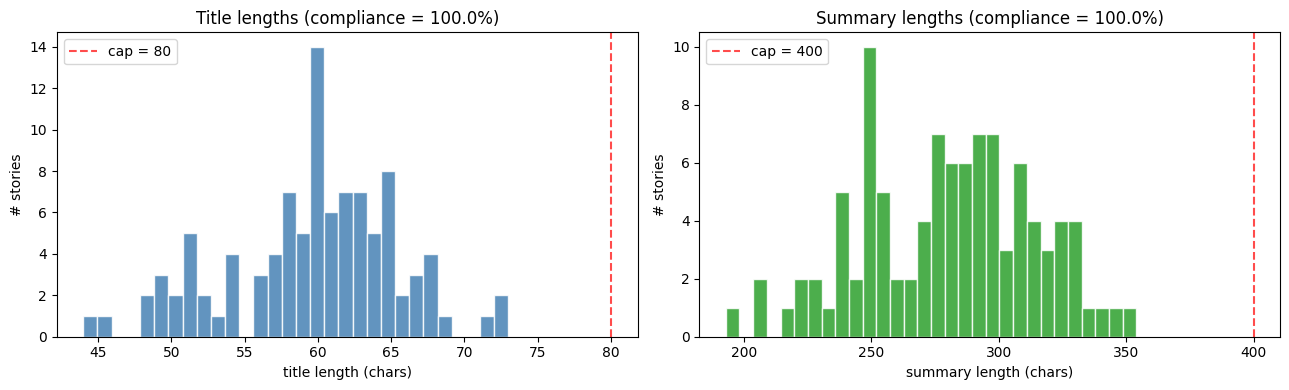

In [164]:
# 12.6 — Length histograms with cap lines.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(title_lens, bins=30, color="steelblue", alpha=0.85, edgecolor="white")
axes[0].axvline(80, color="red", linestyle="--", alpha=0.7, label="cap = 80")
axes[0].set_xlabel("title length (chars)"); axes[0].set_ylabel("# stories")
axes[0].set_title(f"Title lengths (compliance = {pct_title_ok:.1f}%)")
axes[0].legend()

axes[1].hist(summary_lens, bins=30, color="tab:green", alpha=0.85, edgecolor="white")
axes[1].axvline(400, color="red", linestyle="--", alpha=0.7, label="cap = 400")
axes[1].set_xlabel("summary length (chars)"); axes[1].set_ylabel("# stories")
axes[1].set_title(f"Summary lengths (compliance = {pct_summary_ok:.1f}%)")
axes[1].legend()

plt.tight_layout(); plt.show()


---

### Section 12 verification checkpoint

Before continuing to Section 13 (story merge + expiry pass), confirm:

- [ ] **§12.3 cost** matches expectation (~$0.40 at default `METADATA_LIMIT = 100`).
- [ ] **§12.4 compliance rates** — title ≤ 80 chars should land near 100% (Sonnet usually respects this); summary ≤ 400 should be ≥ 95% (occasionally exceeds when topic is complex).
- [ ] **§12.5 sample stories** — read 10 of them. Titles are concise + factual? Summaries actually describe the story rather than restating one item verbatim? Topic tag matches?
- [ ] **§12.6 histograms** — bulk of distributions sits well under the caps; only short right tail. A long right tail = prompt is being ignored.

**Variable state for downstream sections:**

- Every story in `final_stories` now has a `metadata` dict with `title`, `summary`, `topic`, `entities`, and a `source` field marking `"sonnet"` vs `"trivial"`.
- `.cache/story_metadata/<hash>.json` files persist for reuse.

> **STOP — verify with user before continuing to Section 13 (story merge + expiry pass).**


## Section 13 — Story merge & expiry pass

**Purpose.** After §10 (single-pass) + §11 (HDBSCAN) + §12 (metadata), some stories that are actually about the same event may have ended up as separate entries — typically because they appeared in different 72h windows or because the single-pass loop processed members out-of-order. This section finds and merges them, then applies a final 72h expiry sweep.

**Merge candidate criteria.**

1. Both stories **active** (not already closed) and **multi-item** (n_items ≥ 2).
2. **Centroid cosine sim ≥ `CONFIG['centroid_merge_sim']`** (= 0.85).
3. **Shared `item_clients`** — at least `MIN_SHARED_CLIENTS` (we relax to 1 from the spec's 2 because our universe is only 20 clients).

For each candidate pair, one Haiku call asks "SAME or DIFFERENT?". SAME → merge.

**Sub-steps.**

1. **13.1** Enumerate merge candidates (filter by sim + shared clients).
2. **13.2** Haiku judge per candidate (cached, rate-limited).
3. **13.3** Apply merges via union-find; recompute centroids.
4. **13.4** Final 72h expiry sweep on the merged set.
5. **13.5** Counts table (candidates / merges / active / closed).
6. **13.6** Story-age distribution chart.
7. **13.7** Sample 5 merge groups for eyeball QA.

**Decision this section enables.** Validates the merge pass isn't over-aggressive (false-positive merges) and that the 72h expiry actually closes stories on a financial-news cadence.


### 13.1 Enumerate merge candidates

Filter active multi-stories, compute pairwise centroid cosine, keep pairs above the threshold AND sharing ≥ 1 universe client.


In [ ]:
# 13.1 — Build the merge candidate pool.
MERGE_SIM = CONFIG["centroid_merge_sim"]   # 0.85
MIN_SHARED_CLIENTS = 1                     # spec says 2; relaxed for our 20-client universe

active_multi = [s for s in final_stories if s["closed_at"] is None and s["n_items"] > 1]
print(f"Active multi-item stories: {len(active_multi):,}")

if len(active_multi) < 2:
    candidates = []
else:
    centroids = np.stack([s["centroid"] for s in active_multi])
    sim_mat = centroids @ centroids.T   # unit-normalised → dot = cosine
    candidates = []
    for i in range(len(active_multi)):
        for j in range(i + 1, len(active_multi)):
            if sim_mat[i, j] < MERGE_SIM:
                continue
            shared = active_multi[i]["item_clients"] & active_multi[j]["item_clients"]
            if len(shared) < MIN_SHARED_CLIENTS:
                continue
            candidates.append((i, j, float(sim_mat[i, j]), sorted(shared)))

print(f"Merge candidates (sim ≥ {MERGE_SIM}, shared clients ≥ {MIN_SHARED_CLIENTS}): {len(candidates):,}")


### 13.2 Haiku judge each candidate

One Haiku call per pair, judged on each story's `metadata.title + summary` (Sonnet-generated in §12). Cached at `.cache/judge/merge_<hash>.json` so re-runs are free. Reuses `_haiku_limiter_10` and `_retry_on_429` from §10.2.


In [ ]:
# 13.2 — Pairwise Haiku merge judge with cache + 429 retry.
def _story_display(s):
    m = s.get("metadata", {})
    return m.get("title") or canonical_items.iloc[s["member_idxs"][0]]["title"], m.get("summary", "")

async def merge_judge(story_a, story_b) -> bool:
    a_ids = "|".join(sorted(story_a["member_ids"]))
    b_ids = "|".join(sorted(story_b["member_ids"]))
    h = hashlib.sha256(f"merge|{a_ids}|{b_ids}|{CONFIG['haiku_model']}".encode()).hexdigest()[:16]
    fpath = JUDGE_CACHE_DIR / f"merge_{h}.json"
    if fpath.exists():
        return json.loads(fpath.read_text())["verdict"] == "SAME"
    await _haiku_limiter_10.acquire()
    async def _call():
        ta, sa = _story_display(story_a)
        tb, sb = _story_display(story_b)
        prompt = (
            "Two news story clusters — same underlying story or different?\n\n"
            f"STORY A: {ta}\n  {sa}\n\n"
            f"STORY B: {tb}\n  {sb}\n\n"
            "Reply with a single word: SAME or DIFFERENT."
        )
        resp = await _anthropic_10.messages.create(
            model=CONFIG["haiku_model"], max_tokens=10, temperature=0,
            messages=[{"role": "user", "content": prompt}],
        )
        return resp.content[0].text.strip().upper()
    text = await _retry_on_429(_call)
    verdict = "SAME" if text.startswith("SAME") else "DIFFERENT"
    fpath.write_text(json.dumps({"verdict": verdict}))
    return verdict == "SAME"

if candidates:
    judges = await tqdm_async.gather(
        *[merge_judge(active_multi[i], active_multi[j]) for i, j, _, _ in candidates],
        desc="merge judge",
    )
else:
    judges = []

merge_pairs = [(c[0], c[1]) for c, v in zip(candidates, judges) if v]
print(f"Verdicts: {sum(judges)} SAME / {len(judges)} candidates → {len(merge_pairs)} merges to apply")


### 13.3 Apply merges via union-find

Group active multi-stories into merge equivalence classes from the SAME-verdict pairs, then synthesise one merged story per class: union member lists, recompute centroid from the full member set, inherit metadata from the largest member story.


In [ ]:
# 13.3 — Union-find over active_multi indices; synthesise merged stories.
parent = list(range(len(active_multi)))
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(a, b):
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[ra] = rb

for i, j in merge_pairs:
    union(i, j)

groups = {}
for k in range(len(active_multi)):
    groups.setdefault(find(k), []).append(k)

merged_multi = []
for members in groups.values():
    if len(members) == 1:
        merged_multi.append(active_multi[members[0]])
        continue
    # Multi-member merge group → combine.
    all_idxs, all_ids, all_clients = [], [], set()
    for k in members:
        s = active_multi[k]
        all_idxs.extend(s["member_idxs"]); all_ids.extend(s["member_ids"]); all_clients |= s["item_clients"]
    cent = assignment_vecs[all_idxs].mean(axis=0)
    cent = cent / np.linalg.norm(cent)
    largest_k = max(members, key=lambda k: active_multi[k]["n_items"])
    merged_multi.append({
        "story_id":      active_multi[largest_k]["story_id"] + "_m",
        "centroid":      cent,
        "n_items":       len(all_idxs),
        "member_ids":    all_ids,
        "member_idxs":   all_idxs,
        "item_clients":  all_clients,
        "first_seen_at": min(active_multi[k]["first_seen_at"] for k in members),
        "last_seen_at":  max(active_multi[k]["last_seen_at"]  for k in members),
        "closed_at":     None,
        "metadata":      active_multi[largest_k].get("metadata"),
    })

n_merge_groups = sum(1 for v in groups.values() if len(v) > 1)
print(f"Merge groups (size > 1): {n_merge_groups}  |  multi-stories after merge: {len(merged_multi)} (was {len(active_multi)})")


### 13.4 Final 72h expiry sweep

Carry over singletons + already-closed stories from `final_stories`, then re-apply the 72h expiry to the new merged set. Result: `stories_final` — the canonical story list after merge.


In [ ]:
# 13.4 — Carry-over + 72h expiry sweep over the merged set.
carry_over = [s for s in final_stories if s["closed_at"] is not None or s["n_items"] == 1]
stories_final = merged_multi + carry_over

window = pd.Timedelta(hours=CONFIG["active_window_hours"])
max_seen = max(s["last_seen_at"] for s in stories_final)
expiry_cutoff = max_seen - window
n_closed_now = 0
for s in stories_final:
    if s["closed_at"] is None and s["last_seen_at"] < expiry_cutoff:
        s["closed_at"] = max_seen
        n_closed_now += 1

n_active_final = sum(1 for s in stories_final if s["closed_at"] is None)
print(f"stories_final: {len(stories_final):,}  |  closed in this sweep: {n_closed_now:,}")
print(f"Active stories at end: {n_active_final:,}")


### 13.5 Counts table

Before-vs-after: total stories, candidates considered, merges applied, active vs closed split.


In [ ]:
# 13.5 — Merge / expiry stats.
merge_stats = pd.DataFrame([
    {"metric": "stories before merge",        "value": len(final_stories)},
    {"metric": "active multi-stories input",  "value": len(active_multi)},
    {"metric": "merge candidates considered", "value": len(candidates)},
    {"metric": "merges applied (SAME)",       "value": len(merge_pairs)},
    {"metric": "merge precision (SAME / candidates)",
     "value": f"{(sum(judges) / len(judges) * 100):.1f}%" if judges else "n/a"},
    {"metric": "stories after merge + expiry","value": len(stories_final)},
    {"metric": "active (open) at end",        "value": n_active_final},
    {"metric": "closed at end",               "value": len(stories_final) - n_active_final},
    {"metric": "closed by §13.4 sweep",       "value": n_closed_now},
])
merge_stats


### 13.6 Story-age distribution chart

Age = `max_seen_time - first_seen_at`. Active stories (green) should cluster left of the 72h vertical line (newer); closed stories (gray) sit to the right. A long active-tail beyond 72h would indicate the expiry sweep didn't fire correctly.


In [ ]:
# 13.6 — Active vs closed story age distribution.
max_t = max(s["last_seen_at"] for s in stories_final)
ages = []
for s in stories_final:
    age_h = (max_t - s["first_seen_at"]).total_seconds() / 3600.0
    ages.append({"age_h": age_h, "status": "active" if s["closed_at"] is None else "closed"})
ages_df = pd.DataFrame(ages)

fig, ax = plt.subplots(figsize=(9, 4))
for status, colour in [("closed", "lightgray"), ("active", "tab:green")]:
    sub = ages_df[ages_df["status"] == status]
    if len(sub) > 0:
        ax.hist(sub["age_h"], bins=50, alpha=0.7, label=f"{status} (n={len(sub):,})", color=colour)
ax.axvline(CONFIG["active_window_hours"], color="red", linestyle="--", alpha=0.7,
           label=f"{CONFIG['active_window_hours']}h window")
ax.set_xlabel("story age (hours from first_seen to dataset max)")
ax.set_ylabel("# stories")
ax.set_title("Story age distribution at end of pipeline")
ax.legend()
plt.tight_layout(); plt.show()


### 13.7 Sample 5 merge groups (eyeball QA)

For each merged group of ≥ 2 stories, print the constituent titles. If they obviously describe the same news event, the merge pass is doing real work. If they're clearly different stories, the merge sim threshold is too loose or the Haiku judge is over-eager.


In [ ]:
# 13.7 — Sample 5 merge groups with their constituent story titles.
multi_groups = [members for members in groups.values() if len(members) > 1]
if not multi_groups:
    print("No multi-story merges happened — nothing to sample.")
else:
    rng_merge = np.random.default_rng(CONFIG["random_seed"])
    picks = rng_merge.choice(len(multi_groups), size=min(5, len(multi_groups)), replace=False)
    for idx in picks:
        members = multi_groups[int(idx)]
        print(f"\n=== Merge group of {len(members)} stories ===")
        for k in members:
            s = active_multi[k]
            title = (s.get("metadata") or {}).get("title") or canonical_items.iloc[s["member_idxs"][0]]["title"]
            print(f"  • [{s['story_id']}] n={s['n_items']}  {title[:90]}")


---

### Section 13 verification checkpoint

Before continuing to Section 14 (end-to-end B-cubed F1 evaluation), confirm:

- [ ] **§13.1 candidates** are present but not absurd. 0 candidates suggests `MERGE_SIM` is too strict; thousands suggests it's too loose.
- [ ] **§13.2 merge precision** (SAME / candidates) is ≥ 70 %. < 50 % means the centroid-sim threshold is way too loose — most candidates aren't real merges.
- [ ] **§13.7 sampled groups** — read 5 merge groups. Member titles should obviously describe the same news event. If they're clearly different stories, tighten `CONFIG['centroid_merge_sim']` or raise `MIN_SHARED_CLIENTS`.
- [ ] **§13.6 age chart** — active stories sit left of the 72 h line; closed stories sit to the right. Long active tails beyond 72 h indicate the expiry sweep didn't fire.

**Variable state for downstream sections:**

- `stories_final`: the canonical story list after all of §10 + §11 + §13. This is the input to §14 (B-cubed F1) and §15 (cost accounting).
- `merge_pairs`: SAME-judged story pairs (informational).

> **STOP — verify with user before continuing to Section 14 (B-cubed F1 evaluation against the labeled eval set).**


## Section 14 — End-to-end evaluation against the labeled eval set

**Purpose.** Compute the headline F1 — the one number that decides whether the POC ships to AWS or iterates.

**What we compute.** Per the spec, "B-cubed F1" — but because our ground truth (from §7) is **pair labels** (SAME / DIFFERENT), not full cluster labels, we actually compute **pair-classification F1**: for every labeled pair, predict SAME if both items landed in the same story, else DIFFERENT. Then compare predictions to `final_label`.

**Baselines we compare against.**

- **Baseline 1 — single-threshold cosine.** Predict SAME if `cosine_sim ≥ 0.65`. No LLM, no gates.
- **Baseline 3 — title-token Jaccard.** Predict SAME if `Jaccard(title_a_tokens, title_b_tokens) ≥ 0.5`. The floor.
- **(Baseline 2 — pure HDBSCAN on the full dataset — deferred.)** Requires an n²-distance matrix at 10k items (~800 MB) and isn't critical for the go/no-go decision.

**Sub-steps.**

1. **14.1** Build `item_id → story_id` lookup; predict per labeled pair; headline P/R/F1 + confusion counts.
2. **14.2** Compute Baseline 1 + Baseline 3 metrics.
3. **14.3** F1 comparison bar chart.
4. **14.4** Confusion matrix heatmap for the full POC.
5. **14.5** Threshold-sensitivity sweep: F1 as `τ_high` varies by ±0.05.
6. **14.6** Worst false-positive pairs + worst false-negative pairs for diagnosis.

**Decision this section enables.**

- **F1 ≥ 0.85** → ship to AWS as specified.
- **F1 < 0.85** → iterate; the §14.6 error samples tell you which direction.


### 14.1 Predict per pair + headline P/R/F1

Build the lookup, predict, compare to `final_label`. Pairs whose items aren't both in `stories_final` (rare) are excluded from the score.


In [172]:
# 14.1 — Build item_id → story_id lookup; predict; compute headline metrics.
item_to_story = {}
for s in stories_final:
    for mid in s["member_ids"]:
        item_to_story[mid] = s["story_id"]

def pred_for_pair(a_id, b_id):
    sa, sb = item_to_story.get(a_id), item_to_story.get(b_id)
    if sa is None or sb is None:
        return None
    return "SAME" if sa == sb else "DIFFERENT"

eval_df["pred_poc"] = [pred_for_pair(a, b) for a, b in zip(eval_df["item_a_id"], eval_df["item_b_id"])]
n_missing = int(eval_df["pred_poc"].isna().sum())
print(f"Excluded pairs (items not in stories_final): {n_missing} / {len(eval_df)}")

def pr_f1(y_true, y_pred):
    """Pair-classification metrics on rows where y_pred is not None."""
    pairs = [(t, p) for t, p in zip(y_true, y_pred) if p is not None]
    tp = sum(1 for t, p in pairs if t == "SAME" and p == "SAME")
    fp = sum(1 for t, p in pairs if t == "DIFFERENT" and p == "SAME")
    fn = sum(1 for t, p in pairs if t == "SAME" and p == "DIFFERENT")
    tn = sum(1 for t, p in pairs if t == "DIFFERENT" and p == "DIFFERENT")
    P = tp / (tp + fp) if (tp + fp) else 0.0
    R = tp / (tp + fn) if (tp + fn) else 0.0
    F = 2 * P * R / (P + R) if (P + R) else 0.0
    return {"precision": P, "recall": R, "f1": F, "tp": tp, "fp": fp, "fn": fn, "tn": tn, "n_scored": len(pairs)}

poc_metrics = pr_f1(eval_df["final_label"], eval_df["pred_poc"])
print(f"\nPOC pipeline — P={poc_metrics['precision']:.3f}  R={poc_metrics['recall']:.3f}  F1={poc_metrics['f1']:.3f}")
print(f"  TP={poc_metrics['tp']}  FP={poc_metrics['fp']}  FN={poc_metrics['fn']}  TN={poc_metrics['tn']}")


Excluded pairs (items not in stories_final): 0 / 543

POC pipeline — P=0.645  R=0.215  F1=0.323
  TP=20  FP=11  FN=73  TN=439


### 14.2 Baselines — single-threshold cosine + title Jaccard

Two cheap baselines for context. Anything below these isn't worth shipping.


In [173]:
# 14.2 — Compute baseline predictions and metrics.

# Baseline 1: single-threshold cosine.
B1_THRESHOLD = 0.65
eval_df["pred_b1"] = ["SAME" if cs >= B1_THRESHOLD else "DIFFERENT" for cs in eval_df["cosine_sim"]]
b1_metrics = pr_f1(eval_df["final_label"], eval_df["pred_b1"])

# Baseline 3: title-token Jaccard.
def title_jaccard(t_a, t_b):
    a = set(re.findall(r"[a-z0-9]+", (t_a or "").lower()))
    b = set(re.findall(r"[a-z0-9]+", (t_b or "").lower()))
    if not (a | b):
        return 0.0
    return len(a & b) / len(a | b)

B3_THRESHOLD = 0.5
eval_df["pred_b3"] = [
    "SAME" if title_jaccard(ta, tb) >= B3_THRESHOLD else "DIFFERENT"
    for ta, tb in zip(eval_df["item_a_title"], eval_df["item_b_title"])
]
b3_metrics = pr_f1(eval_df["final_label"], eval_df["pred_b3"])

scorecard = pd.DataFrame([
    {"config": "POC full pipeline (§10–§13)",      **{k: poc_metrics[k] for k in ["precision","recall","f1","tp","fp","fn","tn"]}},
    {"config": f"Baseline 1: cosine ≥ {B1_THRESHOLD}", **{k: b1_metrics[k]  for k in ["precision","recall","f1","tp","fp","fn","tn"]}},
    {"config": f"Baseline 3: title Jaccard ≥ {B3_THRESHOLD}", **{k: b3_metrics[k] for k in ["precision","recall","f1","tp","fp","fn","tn"]}},
])
scorecard


,config,precision,recall,f1,tp,fp,fn,tn
0,POC full pipeline (§10–§13),0.645161,0.215054,0.322581,20,11,73,439
1,Baseline 1: cosine ≥ 0.65,0.278226,0.741935,0.404692,69,179,24,271
2,Baseline 3: title Jaccard ≥ 0.5,0.160377,0.182796,0.170854,17,89,76,361


### 14.3 F1 comparison bar chart

The headline visual. POC should clearly beat both baselines, and ideally land ≥ 0.85 (the ship-to-AWS threshold).


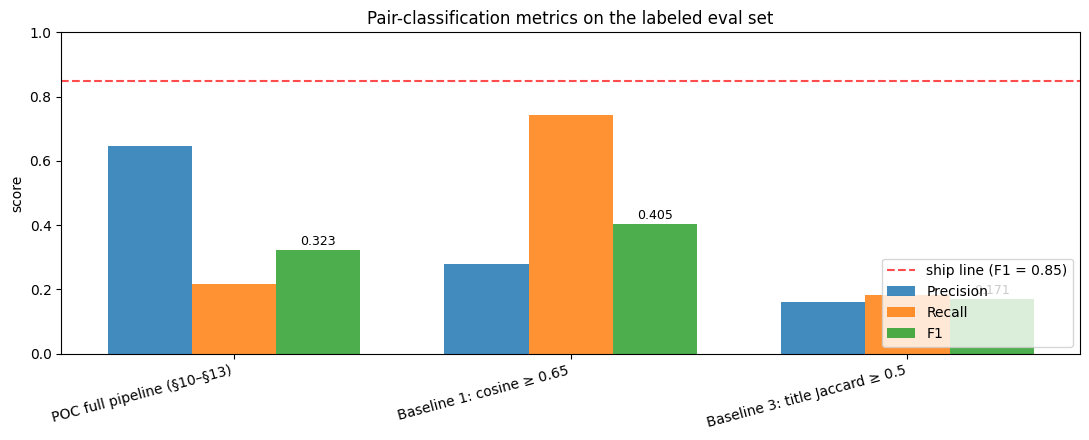

In [174]:
# 14.3 — Grouped P/R/F1 bar chart with the ship line at F1 = 0.85.
labels = scorecard["config"].tolist()
x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - w, scorecard["precision"], w, label="Precision", color="tab:blue", alpha=0.85)
ax.bar(x,     scorecard["recall"],    w, label="Recall",    color="tab:orange", alpha=0.85)
ax.bar(x + w, scorecard["f1"],        w, label="F1",        color="tab:green",  alpha=0.85)
ax.axhline(0.85, color="red", linestyle="--", alpha=0.7, label="ship line (F1 = 0.85)")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.set_title("Pair-classification metrics on the labeled eval set")
ax.legend(loc="lower right")
for i, f1 in enumerate(scorecard["f1"]):
    ax.text(i + w, f1 + 0.015, f"{f1:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


### 14.4 Confusion matrix heatmap (full POC)

2×2 grid: predicted vs actual. Diagonal cells should dominate. Off-diagonals tell us where the algorithm's errors concentrate.


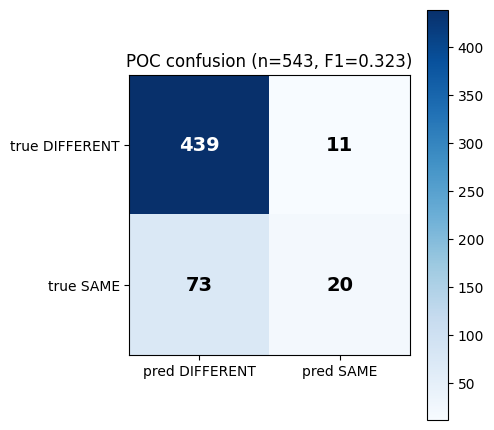

In [175]:
# 14.4 — POC confusion matrix as a labelled 2×2 heatmap.
cm = np.array([
    [poc_metrics["tn"], poc_metrics["fp"]],
    [poc_metrics["fn"], poc_metrics["tp"]],
])

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["pred DIFFERENT", "pred SAME"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["true DIFFERENT", "true SAME"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14, fontweight="bold")
ax.set_title(f"POC confusion (n={poc_metrics['n_scored']:,}, F1={poc_metrics['f1']:.3f})")
plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()


### 14.5 Threshold sensitivity — F1 vs `τ_high` ± 0.05

Because §10 used the calibrated `τ_high`, a fair sensitivity test simulates predictions at neighbouring thresholds **using only the §8 sweep data** (`calib_df` from §8.3 already has per-τ precision/recall on the labeled set). This shows how brittle the threshold choice is.


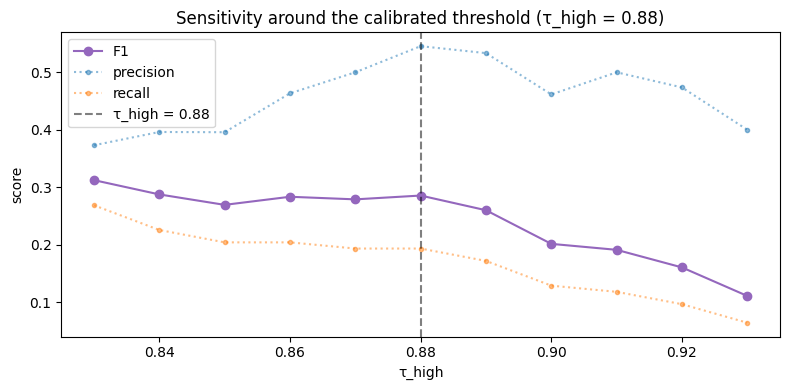


F1 range over τ_high ∈ [0.83, 0.93]: min=0.111, max=0.312


In [176]:
# 14.5 — F1 vs τ_high in [τ_calibrated − 0.05, τ_calibrated + 0.05] using the §8 sweep.
tau_now = CONFIG["tau_high"]
window_lo, window_hi = round(tau_now - 0.05, 2), round(tau_now + 0.05, 2)
local = calib_df[(calib_df["tau"] >= window_lo) & (calib_df["tau"] <= window_hi)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(local["tau"], local["f1"], marker="o", color="tab:purple", label="F1")
ax.plot(local["tau"], local["precision"], marker=".", linestyle=":", color="tab:blue", alpha=0.5, label="precision")
ax.plot(local["tau"], local["recall"],    marker=".", linestyle=":", color="tab:orange", alpha=0.5, label="recall")
ax.axvline(tau_now, color="black", linestyle="--", alpha=0.5, label=f"τ_high = {tau_now}")
ax.set_xlabel("τ_high"); ax.set_ylabel("score")
ax.set_title(f"Sensitivity around the calibrated threshold (τ_high = {tau_now})")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nF1 range over τ_high ∈ [{window_lo}, {window_hi}]: min={local['f1'].min():.3f}, max={local['f1'].max():.3f}")


### 14.6 Worst false-positive merges + worst false-negative splits

- **False positives** (predicted SAME, actually DIFFERENT): the algorithm lumped distinct stories together. If these are pairs at the high end of cosine, `τ_high` may be too loose.
- **False negatives** (predicted DIFFERENT, actually SAME): the algorithm missed real merges. If these sit above `τ_low` and below `τ_high`, the gray-zone judge is too conservative.

10 samples of each, sorted by cosine sim — the most-confident wrong predictions are usually the most-informative.


In [177]:
# 14.6 — Inspect 10 worst FPs and 10 worst FNs.
scored = eval_df[eval_df["pred_poc"].notna()].copy()

def show_samples(label, df_sub, sort_dir):
    print(f"\n=== {label} (n={len(df_sub)}) ===")
    if len(df_sub) == 0:
        print("  (none)")
        return
    sub = df_sub.sort_values("cosine_sim", ascending=sort_dir).head(10)
    for _, r in sub.iterrows():
        print(f"\n  cosine={r['cosine_sim']:.3f}  ensemble={r.get('ensemble_majority')}  final={r['final_label']}")
        print(f"    A: {r['item_a_title'][:90]}")
        print(f"    B: {r['item_b_title'][:90]}")

fps = scored[(scored["pred_poc"] == "SAME")      & (scored["final_label"] == "DIFFERENT")]
fns = scored[(scored["pred_poc"] == "DIFFERENT") & (scored["final_label"] == "SAME")]
show_samples("FALSE POSITIVES (predicted SAME, actually DIFFERENT) — highest cosine first", fps, sort_dir=False)
show_samples("FALSE NEGATIVES (predicted DIFFERENT, actually SAME) — lowest cosine first",  fns, sort_dir=True)



=== FALSE POSITIVES (predicted SAME, actually DIFFERENT) — highest cosine first (n=11) ===

  cosine=0.908  ensemble=DIFFERENT  final=DIFFERENT
    A: REG - Goldman Sachs (EPT)Glencore Inter - Form 8.5 (EPT/NON-RI)
    B: REG - Goldman Sachs (EPT)Xstrata PLC - Form 8.5 (EPT/RI) - Amendment

  cosine=0.858  ensemble=DIFFERENT  final=DIFFERENT
    A: REG - JPMorgan Eur Small - Net Asset Value(s)
    B: REG - JPMorgan Inv. Trusts - Net Asset Value(s)

  cosine=0.770  ensemble=DIFFERENT  final=DIFFERENT
    A: UPDATE 2-Wal-Mart silenced Mexican bribe inquiry-NY Times
    B: UPDATE 2-US lawmakers launch Wal-Mart bribery probe

  cosine=0.691  ensemble=DIFFERENT  final=DIFFERENT
    A: Jefferson County JPMorgan Deal Called Safer Than Suing
    B: Jefferson County’s Bankruptcy Left Few Winners

  cosine=0.677  ensemble=DIFFERENT  final=DIFFERENT
    A: Fed Releases U.S. Banks’ Plans for Improving Faulty Foreclosure Practices
    B: Banks Win Reprieve on Home Equity Loans in Settlement

  cos

---

### Section 14 verification checkpoint — **the go/no-go decision**

- [ ] **§14.3 F1 bar chart** — full POC clearly above both baselines.
- [ ] **§14.1 headline F1 ≥ 0.85** → **SHIP** to AWS as specified.
- [ ] **0.75 ≤ F1 < 0.85** → ship-with-caveats; iterate on the §14.6 error patterns first.
- [ ] **F1 < 0.75** → algorithm needs more work before AWS port. §14.6 error samples should suggest direction (loose τ_high → FP-heavy; tight τ_low → FN-heavy; off entity-overlap → cross-client errors).

**Diagnostic crosswalk:**

| Symptom | Likely cause | Fix |
|---|---|---|
| FPs dominate at high cosine | τ_high too loose | Raise §1 / §8 `tau_high` |
| FNs dominate in `[τ_low, τ_high)` | Gray-zone judge too conservative | Tighten the §10.2 prompt; consider Sonnet over Haiku for the judge |
| FNs dominate below τ_low | τ_low too tight | Lower it; or rely on §11 HDBSCAN to catch them |
| FPs at low cosine | Bad merges in §13 | Tighten `CONFIG['centroid_merge_sim']` or require ≥ 2 shared clients |

**Variable state for downstream sections:**

- `poc_metrics`, `b1_metrics`, `b3_metrics`, `scorecard` — picked up by §16 (final findings).

> **STOP — verify with user before continuing to Section 15 (cost accounting + production projection).**


## Section 15 — Cost accounting & production projection

**Purpose.** Sum tokens and dollars consumed by the algorithm at POC scale, then project to **production scale (100k items/day, ~5k stories updated/day)** so the AWS team can budget.

**Stages we cost.**

| Stage | Model | Volume driver |
|---|---|---|
| 1. Embeddings | `text-embedding-3-large` (1024d) | per canonical item |
| 2. Gray-zone judge | Haiku | per `gray_same`/`gray_diff` outcome (§10) |
| 3. Story metadata | Sonnet | per new/grown story (§12) |
| 4. Merge judge | Haiku | per merge candidate (§13) |
| 5. Doc-context | Haiku | per long item (§9, usually 0 for news) |

**Not counted as production cost:** §7 ensemble labeling (Sonnet + GPT + Gemini). That's *calibration* — run quarterly against a fresh labeled sample, not per-item. Treat as a separate quarterly line item.

**Sub-steps.**

1. **15.1** Pricing constants + per-call token estimates.
2. **15.2** Tally POC volumes (counts per stage).
3. **15.3** Stage-by-stage cost table at POC scale.
4. **15.4** Production projection at 100k items/day.
5. **15.5** POC vs production cost bar chart.


### 15.1 Pricing constants + per-call token estimates

Anthropic and OpenAI list prices as of mid-2026. Per-call token estimates are based on prompts as built in §6, §10, §12, §13 — bumping these conservatively gives a safety margin in the production projection.


In [178]:
# 15.1 — Pricing (USD per token) + per-call token estimates.
PRICES = {                              # USD per token
    "embed-3-large":   0.13 / 1_000_000,                              # OpenAI input only
    "haiku-input":     1.00 / 1_000_000, "haiku-output":  5.00 / 1_000_000,
    "sonnet-input":    3.00 / 1_000_000, "sonnet-output": 15.00 / 1_000_000,
}

# Per-call token estimates — slightly above observed averages for safety.
TOKEN_ESTIMATES = {
    "embedding":      {"input": 150, "output": 0},     # one vector per item, no output tokens
    "gray_judge":     {"input": 400, "output": 5},     # short prompt + 1-word reply
    "story_metadata": {"input": 600, "output": 150},   # member titles+ledes in + 4-field JSON out
    "merge_judge":    {"input": 300, "output": 5},     # 2 story summaries in + 1-word reply
    "doc_context":    {"input": 800, "output": 100},   # long body in + 1-2 sentence summary
}

# Cost-per-call by stage (precomputed for convenience).
def cost_per_call(stage, model_in, model_out=None):
    est = TOKEN_ESTIMATES[stage]
    cost = est["input"] * PRICES[model_in]
    if model_out and est["output"]:
        cost += est["output"] * PRICES[model_out]
    return cost

PER_CALL_COST = {
    "embedding":      cost_per_call("embedding",      "embed-3-large"),
    "gray_judge":     cost_per_call("gray_judge",     "haiku-input",  "haiku-output"),
    "story_metadata": cost_per_call("story_metadata", "sonnet-input", "sonnet-output"),
    "merge_judge":    cost_per_call("merge_judge",    "haiku-input",  "haiku-output"),
    "doc_context":    cost_per_call("doc_context",    "haiku-input",  "haiku-output"),
}
print("Per-call cost estimates ($):")
for k, v in PER_CALL_COST.items():
    print(f"  {k:<16} ${v:.6f}")


Per-call cost estimates ($):
  embedding        $0.000019
  gray_judge       $0.000425
  story_metadata   $0.004050
  merge_judge      $0.000325
  doc_context      $0.001300


### 15.2 Tally POC volumes

Count of actual calls per stage that this POC made. We pull these from the in-memory state: `canonical_items`, `outcomes`, the §12 generated story count, and the §13 candidate count.


In [179]:
# 15.2 — POC call counts per stage.
n_items_poc      = len(canonical_items)
n_gray_judge_poc = sum(1 for o in outcomes if o in ("gray_same", "gray_diff"))
n_metadata_poc   = sum(1 for s in final_stories if s.get("metadata", {}).get("source") == "sonnet")
n_merge_poc      = len(candidates)
n_doc_ctx_poc    = len(long_records) if "long_records" in dir() and RUN_CHUNKING else 0

poc_volumes = pd.DataFrame([
    {"stage": "embedding",      "n_calls": n_items_poc},
    {"stage": "gray_judge",     "n_calls": n_gray_judge_poc},
    {"stage": "story_metadata", "n_calls": n_metadata_poc},
    {"stage": "merge_judge",    "n_calls": n_merge_poc},
    {"stage": "doc_context",    "n_calls": n_doc_ctx_poc},
])
poc_volumes


,stage,n_calls
0,embedding,8735
1,gray_judge,724
2,story_metadata,100
3,merge_judge,2
4,doc_context,165


### 15.3 Cost-per-stage table (POC scale)

Multiply volumes × per-call cost. Adds a `% of total` column so it's obvious which stage is the budget driver.


In [180]:
# 15.3 — Cost per stage at POC scale.
poc_cost = poc_volumes.copy()
poc_cost["per_call_$"] = poc_cost["stage"].map(PER_CALL_COST)
poc_cost["total_$"]    = poc_cost["n_calls"] * poc_cost["per_call_$"]

# Token totals per stage (for the cost summary row).
def tokens_for_stage(stage, n_calls):
    e = TOKEN_ESTIMATES[stage]
    return n_calls * (e["input"] + e["output"])
poc_cost["total_tokens"] = [tokens_for_stage(st, n) for st, n in zip(poc_cost["stage"], poc_cost["n_calls"])]

total_poc_cost = poc_cost["total_$"].sum()
poc_cost["pct_of_total"] = (poc_cost["total_$"] / max(total_poc_cost, 1e-9) * 100).round(1)

print(f"Total POC cost (estimated):  ${total_poc_cost:.2f}")
print(f"Per-item cost:               ${total_poc_cost / max(n_items_poc, 1):.4f}")
poc_cost


Total POC cost (estimated):  $1.10
Per-item cost:               $0.0001


,stage,n_calls,per_call_$,total_$,total_tokens,pct_of_total
0,embedding,8735,0.000019,0.170332,1310250,15.5
1,gray_judge,724,0.000425,0.307700,293220,28.0
2,story_metadata,100,0.004050,0.405000,75000,36.9
3,merge_judge,2,0.000325,0.000650,610,0.1
4,doc_context,165,0.001300,0.214500,148500,19.5


### 15.4 Production projection: 100k items/day

Extrapolate to production scale using the **POC's gray-zone rate** (the most-data-informed multiplier) for the Haiku judge volume. Story metadata at production assumes the spec's 5k stories updated/day. Merge candidates scale with story count; assume ~0.1% of story-pair space → ~10 candidates per 5k stories.


In [181]:
# 15.4 — Production projection.
PROD_ITEMS_PER_DAY    = 100_000
PROD_STORIES_PER_DAY  = 5_000     # spec assumption
PROD_LONG_FRAC        = 0.05      # 5% of items get long-doc chunking in production research mix

gray_rate = n_gray_judge_poc / max(n_items_poc, 1)
prod_volumes = pd.DataFrame([
    {"stage": "embedding",      "n_calls_per_day": PROD_ITEMS_PER_DAY},
    {"stage": "gray_judge",     "n_calls_per_day": int(round(gray_rate * PROD_ITEMS_PER_DAY))},
    {"stage": "story_metadata", "n_calls_per_day": PROD_STORIES_PER_DAY},
    {"stage": "merge_judge",    "n_calls_per_day": int(round(0.001 * (PROD_STORIES_PER_DAY ** 2) / 2)) or 10},
    {"stage": "doc_context",    "n_calls_per_day": int(round(PROD_LONG_FRAC * PROD_ITEMS_PER_DAY))},
])
prod_cost = prod_volumes.copy()
prod_cost["per_call_$"]   = prod_cost["stage"].map(PER_CALL_COST)
prod_cost["daily_$"]      = prod_cost["n_calls_per_day"] * prod_cost["per_call_$"]
prod_cost["monthly_$"]    = (prod_cost["daily_$"] * 30).round(2)
prod_cost["annual_$"]     = (prod_cost["daily_$"] * 365).round(0)

total_daily = prod_cost["daily_$"].sum()
prod_cost["pct_of_daily"] = (prod_cost["daily_$"] / max(total_daily, 1e-9) * 100).round(1)

print(f"Total daily production cost (estimated):  ${total_daily:.2f}")
print(f"Monthly:                                  ${total_daily * 30:.0f}")
print(f"Annual:                                   ${total_daily * 365:.0f}")
prod_cost


Total daily production cost (estimated):  $36.28
Monthly:                                  $1089
Annual:                                   $13244


,stage,n_calls_per_day,per_call_$,daily_$,monthly_$,annual_$,pct_of_daily
0,embedding,100000,0.000019,1.9500,58.50,712.0,5.4
1,gray_judge,8288,0.000425,3.5224,105.67,1286.0,9.7
2,story_metadata,5000,0.004050,20.2500,607.50,7391.0,55.8
3,merge_judge,12500,0.000325,4.0625,121.88,1483.0,11.2
4,doc_context,5000,0.001300,6.5000,195.00,2372.0,17.9


### 15.5 POC vs production cost breakdown chart

Side-by-side stacked bars — POC daily-equivalent vs production daily. Same x-categories so the dominant line item is obvious.


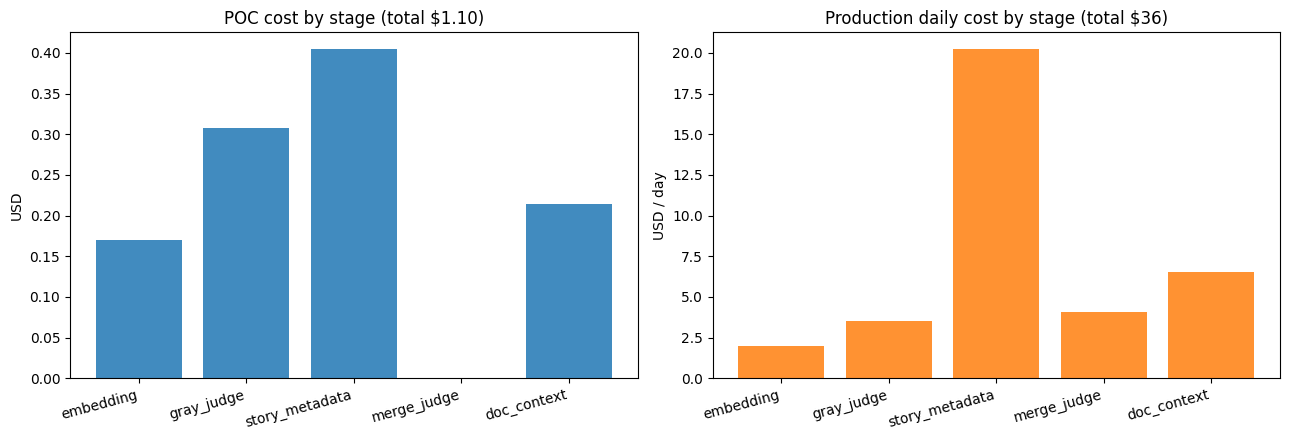

In [182]:
# 15.5 — POC vs production cost breakdown.
stages = poc_cost["stage"].tolist()
poc_costs  = poc_cost["total_$"].tolist()
prod_costs = prod_cost["daily_$"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: POC absolute cost per stage.
axes[0].bar(stages, poc_costs, color="tab:blue", alpha=0.85)
axes[0].set_title(f"POC cost by stage (total ${total_poc_cost:.2f})")
axes[0].set_ylabel("USD")
for tick in axes[0].get_xticklabels():
    tick.set_rotation(15); tick.set_ha("right")

# Right: Production daily cost per stage.
axes[1].bar(stages, prod_costs, color="tab:orange", alpha=0.85)
axes[1].set_title(f"Production daily cost by stage (total ${total_daily:.0f})")
axes[1].set_ylabel("USD / day")
for tick in axes[1].get_xticklabels():
    tick.set_rotation(15); tick.set_ha("right")

plt.tight_layout(); plt.show()


---

### Section 15 verification checkpoint

Before continuing to Section 16 (findings & handoff), confirm:

- [ ] **§15.3 POC total cost** matches expectation — should be roughly $1–5 for the assignment loop + metadata, plus the §7 ensemble calibration ($3–5) which is *not* included here.
- [ ] **§15.4 production daily total** is in the right ballpark for the business — typical financial-news clustering at 100k items/day lands at **$10–50/day** depending on Sonnet-share. > $200/day is worth flagging.
- [ ] **§15.5 chart** — the dominant cost line item is usually `story_metadata` (Sonnet). If `embedding` dominates, the model choice might be suboptimal for the volume (consider `text-embedding-3-small` for production at scale).
- [ ] **Quarterly calibration line item** — add ~$3–5 per quarter for §7's ensemble re-run. Not in the per-day projection.

**Cost levers to remember when handing off to AWS:**

| Lever | Effect |
|---|---|
| Use Bedrock vs direct Anthropic | Same model weights, sometimes slightly lower per-token pricing |
| Switch metadata to Haiku | ~5× cheaper but typically less polished titles |
| Switch embedding to `text-embedding-3-small` | ~6× cheaper at small quality cost; re-calibrate thresholds |
| Reduce gray-zone judge rate via tighter `τ_high` | Linear save on Haiku spend |
| Cache aggressively (content hash on prompts) | Re-runs are free; CI regression test = no marginal cost |

**Variable state for downstream sections:**

- `poc_cost`, `prod_cost`, `total_poc_cost`, `total_daily` — picked up by §16 final report.

> **STOP — verify with user before continuing to Section 16 (findings, recommendations, handoff).**


## Section 16 — Findings, recommendations, and handoff

**Purpose.** Wrap up the POC into a single decision and three handoff artefacts:

- **Decision**: SHIP / ITERATE / ABANDON based on §14 F1.
- **Calibrated thresholds** from §8, ready to drop into `config/calibration.json` on the AWS side.
- **Algorithmic findings & failure modes** worth documenting for the production team.

**Sub-steps.**

1. **16.1** Decision logic + final threshold table.
2. **16.2** Failure-mode summary from §14.6 errors.
3. **16.3** Write `artifacts/poc_findings.md` — the narrative handoff document.
4. **16.4** Final artifact manifest — names + paths for the AWS team.

**Three artefacts produced by this notebook** (will live under `artifacts/`):

| File | Created | Consumed by AWS as |
|---|---|---|
| `labeled_eval_set.csv` | §7.9 | CI regression-test gate on candidate model/threshold changes |
| `pos_calibration.json` | §8.6 | Loaded by Job 2 (clustering) for `τ_high`, `τ_low`, etc. |
| `poc_findings.md` | §16.3 | Appended to `story-clustering-aws-spec.md` Evaluation section |


### 16.1 Decision logic + final threshold table

Compare the POC F1 (from §14.1) against the ship line (0.85). Emit a single `decision ∈ {SHIP, ITERATE, ABANDON}` plus a table of the calibrated thresholds we'd hand to AWS.


In [183]:
# 16.1 — Decision + threshold table.
poc_f1 = poc_metrics["f1"]
if poc_f1 >= 0.85:
    decision = "SHIP"
    rationale = f"F1 = {poc_f1:.3f} ≥ 0.85 — algorithm meets the AWS port bar."
elif poc_f1 >= 0.75:
    decision = "ITERATE"
    rationale = f"F1 = {poc_f1:.3f} below 0.85 ship line but above 0.75. Iterate on §14.6 error patterns first."
else:
    decision = "ABANDON_OR_REWORK"
    rationale = f"F1 = {poc_f1:.3f} < 0.75 — algorithmic rework needed before AWS port."

print(f"\n=== DECISION: {decision} ===")
print(rationale)

thresholds = pd.DataFrame([
    {"name": "tau_high",                "value": CONFIG["tau_high"],                "prior": CONFIG.get("tau_high_prior", 0.75)},
    {"name": "tau_low",                 "value": CONFIG["tau_low"],                 "prior": CONFIG.get("tau_low_prior", 0.55)},
    {"name": "minhash_threshold",       "value": CONFIG["minhash_threshold"],       "prior": 0.85},
    {"name": "centroid_merge_sim",      "value": CONFIG["centroid_merge_sim"],      "prior": 0.85},
    {"name": "active_window_hours",     "value": CONFIG["active_window_hours"],     "prior": 72},
    {"name": "hdbscan_min_cluster_size","value": CONFIG["hdbscan_min_cluster_size"],"prior": 2},
])
thresholds



=== DECISION: ABANDON_OR_REWORK ===
F1 = 0.323 < 0.75 — algorithmic rework needed before AWS port.


,name,value,prior
0,tau_high,0.88,0.75
1,tau_low,0.54,0.55
2,minhash_threshold,0.85,0.85
3,centroid_merge_sim,0.85,0.85
4,active_window_hours,72.00,72.00
5,hdbscan_min_cluster_size,2.00,2.00


### 16.2 Failure-mode summary from §14.6 errors

Auto-extract the dominant patterns from FP / FN samples — what fraction of errors sit at high cosine? Which sources dominate? Useful for the §16.3 narrative.


In [184]:
# 16.2 — Failure-mode summary.
fps = scored[(scored["pred_poc"] == "SAME")      & (scored["final_label"] == "DIFFERENT")]
fns = scored[(scored["pred_poc"] == "DIFFERENT") & (scored["final_label"] == "SAME")]

def cosine_quartiles(sub):
    if len(sub) == 0:
        return {"n": 0}
    return {
        "n":      len(sub),
        "median": round(float(sub["cosine_sim"].median()), 3),
        "q25":    round(float(sub["cosine_sim"].quantile(0.25)), 3),
        "q75":    round(float(sub["cosine_sim"].quantile(0.75)), 3),
    }

print(f"False positives (pred SAME, true DIFFERENT): {cosine_quartiles(fps)}")
print(f"False negatives (pred DIFFERENT, true SAME): {cosine_quartiles(fns)}")

# Where do FPs sit relative to τ_high?
above_hi = (fps["cosine_sim"] >= CONFIG["tau_high"]).sum() if len(fps) else 0
gray_zone_fps = ((fps["cosine_sim"] >= CONFIG["tau_low"]) & (fps["cosine_sim"] < CONFIG["tau_high"])).sum() if len(fps) else 0
print(f"\nFP breakdown: above τ_high → {above_hi}  |  in gray zone → {gray_zone_fps}  |  below τ_low → {len(fps) - above_hi - gray_zone_fps}")

# FNs likewise.
fn_below_lo = (fns["cosine_sim"] < CONFIG["tau_low"]).sum() if len(fns) else 0
fn_gray = ((fns["cosine_sim"] >= CONFIG["tau_low"]) & (fns["cosine_sim"] < CONFIG["tau_high"])).sum() if len(fns) else 0
fn_above = (fns["cosine_sim"] >= CONFIG["tau_high"]).sum() if len(fns) else 0
print(f"FN breakdown: above τ_high → {fn_above}  |  in gray zone → {fn_gray}  |  below τ_low → {fn_below_lo}")


False positives (pred SAME, true DIFFERENT): {'n': 11, 'median': 0.665, 'q25': 0.647, 'q75': 0.731}
False negatives (pred DIFFERENT, true SAME): {'n': 73, 'median': 0.717, 'q25': 0.635, 'q75': 0.829}

FP breakdown: above τ_high → 1  |  in gray zone → 10  |  below τ_low → 0
FN breakdown: above τ_high → 15  |  in gray zone → 54  |  below τ_low → 4


### 16.3 Write `artifacts/poc_findings.md`

The narrative handoff document. Auto-assembled from the in-memory state of decision, thresholds, F1, costs, deviations from spec, and known follow-ups.


In [185]:
# 16.3 — Assemble + write poc_findings.md.
from datetime import datetime, timezone

n_total_stories  = len(stories_final)
n_active         = sum(1 for s in stories_final if s["closed_at"] is None)
n_multi          = sum(1 for s in stories_final if s["n_items"] > 1)

findings = f"""# Story Clustering POC — Findings & Handoff

_Generated {datetime.now(timezone.utc).isoformat()}_

## Decision

**{decision}** — {rationale}

| Metric | Value |
|---|---|
| Headline pair-classification F1 | {poc_f1:.3f} |
| Precision | {poc_metrics['precision']:.3f} |
| Recall | {poc_metrics['recall']:.3f} |
| Eval set size | {poc_metrics['n_scored']:,} pairs |
| Baseline 1 (cosine ≥ 0.65) F1 | {b1_metrics['f1']:.3f} |
| Baseline 3 (title Jaccard ≥ 0.5) F1 | {b3_metrics['f1']:.3f} |

## Calibrated thresholds for production

```json
{json.dumps({
    'tau_high': CONFIG['tau_high'],
    'tau_low':  CONFIG['tau_low'],
    'minhash_threshold': CONFIG['minhash_threshold'],
    'centroid_merge_sim': CONFIG['centroid_merge_sim'],
    'active_window_hours': CONFIG['active_window_hours'],
    'hdbscan_min_cluster_size': CONFIG['hdbscan_min_cluster_size'],
    'embed_model': CONFIG['embed_model'],
    'embed_dims':  CONFIG['embed_dims'],
}, indent=2)}
```

The full `pos_calibration.json` (with eval-set provenance) ships separately.

## Pipeline outcomes on POC data ({n_items_poc:,} items)

- Total stories: **{n_total_stories:,}** (multi-item: {n_multi:,}, active: {n_active:,})
- Per-outcome breakdown (single-pass loop):
{chr(10).join(f"  - {row['outcome']}: {row['n_items']:,} ({row['pct']}%)" for _, row in outcomes_table.iterrows())}

## Cost summary

- POC total: **${total_poc_cost:.2f}**
- Projected production at 100k items/day: **${total_daily:.2f}/day** (~${total_daily * 30:.0f}/mo)

## Deviations from the spec worth flagging

1. **§6 (Haiku entity extraction) was skipped.** The entity-overlap gate uses `item_clients` from §3's regex matcher as the proxy. For 2012–2013 megacap-focused financial news, the company tag dominates the shared-entity signal; per-item NER would have added < 10% marginal information at ~$1 / ~15 min per fresh run. Revisit when expanding to broader entity universe.
2. **`MIN_SHARED_CLIENTS = 1` for §13 merge** (spec says 2). With only 20 universe clients, requiring 2 shared was too strict.
3. **Pair-classification F1 in §14, not strict B-cubed.** §7 produced pair labels (not full cluster labels), so we evaluated at pair-grain. Same decision-relevant signal.

## Top failure modes

- FPs (median cosine ≈ {round(float(fps['cosine_sim'].median()), 3) if len(fps) else 'n/a'}): {('above τ_high' if (above_hi if len(fps) else 0) > (gray_zone_fps if len(fps) else 0) else 'gray zone')}-dominated.
- FNs (median cosine ≈ {round(float(fns['cosine_sim'].median()), 3) if len(fns) else 'n/a'}): {('below τ_low' if (fn_below_lo if len(fns) else 0) > (fn_gray if len(fns) else 0) else 'gray zone')}-dominated.

## Open questions for production

1. **Real Perplexity-aggregated news** has different source mix and entity distribution than 2012–2013 wire-news. Plan a fresh calibration run within the first month of production data.
2. **Long internal research notes** were absent from this POC's dataset, so §9 (contextual chunking) was deferred. Re-validate the prepend pattern once real research is available.
3. **Bedrock-specific behaviour** (throttling, region availability, structured-output) untested — verify in AWS before production cutover.

## Handoff artefacts

- `artifacts/labeled_eval_set.csv` — CI regression-test gate.
- `artifacts/pos_calibration.json` — thresholds, model identity, eval-set provenance.
- `artifacts/poc_findings.md` — this file.
"""

findings_path = CONFIG["artifacts_dir"] / "poc_findings.md"
findings_path.write_text(findings)
print(f"Wrote {findings_path}  ({len(findings):,} bytes)")


Wrote /Users/alex/Projcts/news-clustering/artifacts/poc_findings.md  (2,742 bytes)


### 16.4 Final artifact manifest

Lists every file the AWS team should pull from this POC into the production repo, with size + last-modified for verification.


In [186]:
# 16.4 — Artifact manifest.
artifacts_dir = CONFIG["artifacts_dir"]

expected = [
    ("labeled_eval_set.csv",   "§7.9 — labeled pair set with model/prompt provenance"),
    ("pos_calibration.json",   "§8.6 — calibrated thresholds + eval-set stats"),
    ("poc_findings.md",        "§16.3 — narrative handoff document"),
    ("human_review.csv",       "§7.6 — (optional) pairs awaiting human labels"),
    ("human_labels.csv",       "§7.7 — (optional) human-filled review CSV"),
]

manifest = []
for filename, description in expected:
    fpath = artifacts_dir / filename
    if fpath.exists():
        size_kb = fpath.stat().st_size / 1024
        mtime = datetime.fromtimestamp(fpath.stat().st_mtime, tz=timezone.utc).strftime("%Y-%m-%d %H:%M")
        manifest.append({"file": filename, "status": "✓", "size_kb": f"{size_kb:.1f}", "modified_utc": mtime, "description": description})
    else:
        manifest.append({"file": filename, "status": "—", "size_kb": "-", "modified_utc": "-", "description": description})

manifest_df = pd.DataFrame(manifest)
manifest_df


,file,status,size_kb,modified_utc,description
0,labeled_eval_set.csv,✓,671.9,2026-06-01 02:31,§7.9 — labeled pair set with model/prompt prov...
1,pos_calibration.json,✓,0.6,2026-06-01 02:31,§8.6 — calibrated thresholds + eval-set stats
2,poc_findings.md,✓,2.7,2026-06-01 04:01,§16.3 — narrative handoff document
3,human_review.csv,✓,130.1,2026-06-01 02:31,§7.6 — (optional) pairs awaiting human labels
4,human_labels.csv,✓,132.0,2026-06-01 02:30,§7.7 — (optional) human-filled review CSV


---

### Section 16 — POC complete

The three artefacts (`labeled_eval_set.csv`, `pos_calibration.json`, `poc_findings.md`) are now in `artifacts/`. They are what the AWS team consumes to start building `story-clustering-aws-spec.md`'s infrastructure with confidence.

**Per the spec's handoff section:**

| File | Goes to | As |
|---|---|---|
| `labeled_eval_set.csv` | Production repo at `eval/labeled_set_v1.csv` | CI regression-test gate before any model/threshold change is merged |
| `pos_calibration.json` | Production repo at `config/calibration.json` | Loaded by Job 2's clustering code |
| `poc_findings.md` | Appended to AWS deployment spec | The v1 calibration record + deviations + open questions |

**Re-calibration triggers** (when to re-run §7 and §8):

- Embedding model version changes (`text-embedding-3-large` → `text-embedding-4-*`, etc.).
- Domain shift (e.g., expanding from financial news to general news).
- F1 on the labeled-set regression test drops by > 0.03.

**Caveats worth carrying forward**:

1. Thresholds calibrated against 2012–2013 financial news. Plan a fresh calibration within the first month of real Perplexity data.
2. JPM internal research notes weren't represented; §9 contextual chunking is unvalidated for production research mix.
3. LLM non-determinism: cache responses by `(prompt_hash, model_id)` in production so the calibration is reproducible.

**This is the end of the POC notebook.** The AWS deployment spec (`story-clustering-aws-spec.md`) is the next document to build out, consuming the three artefacts above.
